# File cập nhật dữ liệu update liên tục quá trình kinh doanh của Công ty: từ tháng 09/2010 đến tháng 03/2026:

https://s3.amazonaws.com/capitalbikeshare-data/index.html

## Mục tiêu dài hạn: Họ cần dự báo tổng lượt thuê xe của năm tiếp theo là bao nhiêu để lên kế hoạch đặt mua xe, cũng như kế hoạch phân bổ lượng xe theo mùa, sửa chữa bảo dưỡng thay thế. chuẩn bị quy mô đội xe cho năm mới

In [1]:
import pandas as pd
import numpy as np
import requests, zipfile, io, warnings, gc
import xml.etree.ElementTree as ET
from tqdm import tqdm
import matplotlib.pyplot as plt
warnings.filterwarnings("ignore")

# ── Cấu hình ─────────────────────────────────────────────
BASE_URL        = "https://capitalbikeshare-data.s3.amazonaws.com/"
BUCKET_LIST_URL = "https://capitalbikeshare-data.s3.amazonaws.com?list-type=2"

OLD_COLS = {"Start date", "Start station number",
            "Start station", "Member type"}
NEW_COLS = {"started_at", "start_station_id",
            "start_station_name", "member_casual"}

RENAME_MAP = {
    "Start date"          : "start_dt",
    "Start station number": "station_id",
    "Start station"       : "station_name",
    "Member type"         : "member_type",
    "started_at"          : "start_dt",
    "start_station_id"    : "station_id",
    "start_station_name"  : "station_name",
    "member_casual"       : "member_type",
}

# Chuẩn hóa member_type về 2 nhóm
MEMBER_MAP = {
    "Member": "member", "member": "member",
    "Casual": "casual", "casual": "casual",
}

# ── Lấy danh sách file zip ────────────────────────────────
def get_zip_links():
    all_files, continuation_token = [], None
    while True:
        url = f"{BUCKET_LIST_URL}&continuation-token={continuation_token}" \
              if continuation_token else BUCKET_LIST_URL
        root = ET.fromstring(requests.get(url).content)
        ns   = {"s3": "http://s3.amazonaws.com/doc/2006-03-01/"}
        for item in root.findall("s3:Contents", ns):
            key = item.find("s3:Key", ns).text
            if key.endswith(".zip"):
                all_files.append(BASE_URL + key)
        trunc = root.find("s3:IsTruncated", ns)
        if trunc is not None and trunc.text == "true":
            continuation_token = root.find(
                "s3:NextContinuationToken", ns).text
        else:
            break
    return sorted(all_files)

zip_links = get_zip_links()
print(f"✅ Tìm thấy {len(zip_links)} file zip\n")

# ── Hàm đọc 1 file zip và aggregate ngay ─────────────────
# Lý do: không bao giờ concat 52M dòng vào RAM
# Mỗi file zip → đọc CSV → aggregate → trả về dict 5 bảng nhỏ
# RAM cao nhất = 1 file zip (~vài MB), không phải toàn bộ dataset

def load_and_agg(zip_url):
    """
    Đọc 1 file zip, aggregate ngay thành 5 bảng nhỏ.
    Không trả về raw rows — chỉ trả về số đếm tổng hợp.
    """
    resp = requests.get(zip_url, timeout=120)
    resp.raise_for_status()

    # Dict lưu kết quả aggregate của file này
    result = {
        "monthly"       : [],   # trips theo year_month
        "member_yearly" : [],   # trips theo year + member_type
        "member_monthly": [],   # trips theo year_month + member_type
        "daily"         : [],   # trips theo từng ngày cụ thể
        "yearly"        : [],   # trips theo năm
        "hourly_member"        : [],   # trips theo từng giờ cụ thể
        "station_trips" : [],  # trips theo trạm (NEW)
    }

    with zipfile.ZipFile(io.BytesIO(resp.content)) as z:
        csv_files = [f for f in z.namelist()
                     if f.lower().endswith(".csv")
                     and not f.startswith("__MACOSX")]

        for csv_name in csv_files:
            with z.open(csv_name) as f:
                try:
                    # Chỉ đọc các cột cần thiết — tiết kiệm RAM
                    tmp = pd.read_csv(
                        f, low_memory=False,
                        usecols=lambda c: c in OLD_COLS | NEW_COLS
                    )
                except Exception:
                    continue

                # Chuẩn hóa tên cột
                tmp = tmp.rename(columns=RENAME_MAP)

                # Parse datetime
                tmp["start_dt"] = pd.to_datetime(
                    tmp["start_dt"], errors="coerce", format="mixed"
                )
                tmp = tmp.dropna(subset=["start_dt"])
                tmp = tmp[tmp["start_dt"].dt.year.between(2010, 2026)]
                if tmp.empty:
                    continue

                # Tạo các cột thời gian cần thiết
                tmp["year"]       = tmp["start_dt"].dt.year
                tmp["month"]      = tmp["start_dt"].dt.month
                tmp["year_month"] = tmp["start_dt"].dt.to_period("M").astype(str)
                tmp["date"]       = tmp["start_dt"].dt.date
                tmp["hour"]       = tmp["start_dt"].dt.hour # NEW: Extract hour



                # Chuẩn hóa member_type
                if "member_type" in tmp.columns:
                    tmp["member_type"] = tmp["member_type"].map(MEMBER_MAP)

                # ── Aggregate 5 chiều ────────────────────
                # A: theo tháng
                result["monthly"].append(
                    tmp.groupby("year_month").size().reset_index(name="trips")
                )

                # B: member/casual theo năm
                if "member_type" in tmp.columns:
                    result["member_yearly"].append(
                        tmp.groupby(["year", "member_type"])
                           .size().reset_index(name="trips")
                    )
                # C: member/casual theo tháng
                    result["member_monthly"].append(
                        tmp.groupby(["year_month", "member_type"])
                           .size().reset_index(name="trips")
                    )

                # D: theo ngày (cho heatmap)
                result["daily"].append(
                    tmp.groupby("date").size().reset_index(name="trips")
                )

                # E: theo năm
                result["yearly"].append(
                    tmp.groupby("year").size().reset_index(name="trips")
                )
                # F: NEW: theo giờ + member_type
                if "member_type" in tmp.columns:
                    result["hourly_member"].append(
                        tmp.groupby(["date", "hour", "member_type"])
                           .size().reset_index(name="trips")
                    )
                # G: NEW: trips theo trạm (station_id, station_name)
                if "station_id" in tmp.columns and "station_name" in tmp.columns:
                    result["station_trips"].append(
                        tmp.groupby(["station_id", "station_name"])
                           .size().reset_index(name="trips")
                    )


                # Xóa tmp ngay để giải phóng RAM
                del tmp
                gc.collect()

    return result

# ── Vòng lặp chính: đọc 107 file, gộp 5 bảng ────────────
# Mỗi bước chỉ giữ 1 file trong RAM tại 1 thời điểm
buckets = {k: [] for k in ["monthly", "member_yearly",
                             "member_monthly", "daily", "yearly",
                             "hourly_member", "station_trips"]}
failed  = []

for url in tqdm(zip_links, desc="Loading & Aggregating"):
    try:
        agg = load_and_agg(url)
        for key in buckets:
            buckets[key].extend(agg[key])
    except Exception as e:
        failed.append(url.split("/")[-1])
        print(f"  ⚠️ Lỗi: {url.split('/')[-1]} — {e}")

print(f"\n✅ Load xong | Lỗi: {len(failed)} file")

# ── Gộp và chuẩn hóa 5 bảng cuối ────────────────────────

# A: monthly_agg — dùng cho forecast + trend
monthly_agg = (
    pd.concat(buckets["monthly"])
      .groupby("year_month")["trips"].sum()
      .reset_index()
      .sort_values("year_month")
)
monthly_agg["ds"]    = pd.to_datetime(monthly_agg["year_month"])
monthly_agg["year"]  = monthly_agg["ds"].dt.year
monthly_agg["month"] = monthly_agg["ds"].dt.month

# B: member_yearly — tỷ trọng member/casual theo năm
member_yearly = (
    pd.concat(buckets["member_yearly"])
      .groupby(["year", "member_type"])["trips"].sum()
      .reset_index()
      .sort_values(["year", "member_type"])
)

# C: member_monthly — xu hướng member/casual theo tháng
member_monthly = (
    pd.concat(buckets["member_monthly"])
      .groupby(["year_month", "member_type"])["trips"].sum()
      .reset_index()
)
member_monthly["ds"] = pd.to_datetime(member_monthly["year_month"])

# D: daily_agg — heatmap ngày × tháng × năm
daily_agg = (
    pd.concat(buckets["daily"])
      .groupby("date")["trips"].sum()
      .reset_index()
)
daily_agg["date"]    = pd.to_datetime(daily_agg["date"])
daily_agg["year"]    = daily_agg["date"].dt.year
daily_agg["month"]   = daily_agg["date"].dt.month
daily_agg["day"]     = daily_agg["date"].dt.day
daily_agg["weekday"] = daily_agg["date"].dt.day_name()

# E: yearly_agg — biểu đồ tổng quan
yearly_agg = (
    pd.concat(buckets["yearly"])
      .groupby("year")["trips"].sum()
      .reset_index()
      .sort_values("year")
)
# F: NEW: hourly_member_agg — phân phối theo giờ và loại khách hàng

# Gộp tất cả file lại
hourly_raw = (
    pd.concat(buckets["hourly_member"])
      .groupby(["date", "hour", "member_type"])["trips"].sum()
      .reset_index()
)

# Tính trung bình số chuyến mỗi giờ trên tất cả các ngày
hourly_agg = (
    hourly_raw
      .groupby(["hour", "member_type"])["trips"].mean()
      .reset_index()
      .sort_values(["hour", "member_type"])
)

# H: NEW: station_agg — tổng số chuyến theo từng trạm
station_agg = (
    pd.concat(buckets["station_trips"])
      .groupby(["station_id", "station_name"])["trips"].sum()
      .reset_index()
      .sort_values("trips", ascending=False)
)

# Giải phóng buckets sau khi đã gộp xong
del buckets
gc.collect()

# ── Kiểm tra kết quả ─────────────────────────────────────
print("\n=== 5 BẢNG AGGREGATE SẴN SÀNG ===")
print(f"  monthly_agg    : {len(monthly_agg):>5,} dòng "
      f"| {monthly_agg['ds'].min().date()} → {monthly_agg['ds'].max().date()}")
print(f"  member_yearly  : {len(member_yearly):>5,} dòng "
      f"| {member_yearly['year'].min()} → {member_yearly['year'].max()}")
print(f"  member_monthly : {len(member_monthly):>5,} dòng")
print(f"  daily_agg      : {len(daily_agg):>5,} dòng "
      f"| {daily_agg['date'].min().date()} → {daily_agg['date'].max().date()}")
print(f"  yearly_agg     : {len(yearly_agg):>5,} dòng")
print(f"  hourly_member  : {len(hourly_agg):>5,} dòng")
print(f"  station_agg    : {len(station_agg):>5,} dòng") # NEW: print station_agg info

# Kiểm tra tính liên tục tháng
existing = pd.PeriodIndex(pd.to_datetime(monthly_agg["year_month"]).dt.to_period("M"))
period_index   = pd.period_range(existing.min(), existing.max(), freq="M")
missing_months = period_index.difference(existing)
print(f"\n  Thiếu tháng    : {len(missing_months)} "
      f"{'✅' if len(missing_months)==0 else '⚠️ ' + str(missing_months.tolist())}")

# Kiểm tra member_type
print(f"\n  Member/Casual check:")
print(member_yearly.groupby("member_type")["trips"].sum()
      .apply(lambda x: f"{x:,.0f}").to_string())

print("\n🎉 Sẵn sàng vẽ biểu đồ!")

✅ Tìm thấy 107 file zip



Loading & Aggregating: 100%|██████████| 107/107 [08:24<00:00,  4.71s/it]



✅ Load xong | Lỗi: 0 file

=== 5 BẢNG AGGREGATE SẴN SÀNG ===
  monthly_agg    :   187 dòng | 2010-09-01 → 2026-03-01
  member_yearly  :    34 dòng | 2010 → 2026
  member_monthly :   374 dòng
  daily_agg      : 5,668 dòng | 2010-09-20 → 2026-03-31
  yearly_agg     :    17 dòng
  hourly_member  :    48 dòng
  station_agg    : 1,692 dòng

  Thiếu tháng    : 0 ✅

  Member/Casual check:
member_type
casual    14,619,529
member    38,124,947

🎉 Sẵn sàng vẽ biểu đồ!


In [2]:
# Xem 5 dòng đầu của data sau khi gộp
monthly_agg.head()

,year_month,trips,ds,year,month
0,2010-09,4002,2010-09-01,2010,9
1,2010-10,35957,2010-10-01,2010,10
2,2010-11,47390,2010-11-01,2010,11
3,2010-12,28248,2010-12-01,2010,12
4,2011-01,37503,2011-01-01,2011,1


### Không có tháng nào bị thiếu, thời gian xuyên suốt, đảm bảo dữ liệu cho việc sử dụng các mô hình dự báo

### EDA TỔNG QUAN — 4 BIỂU ĐỒ TRONG 1 FIGURE
### Thứ tự: Yearly → Quarterly → Monthly → Member/Casual
#
### Dữ liệu dùng:
###   yearly_agg    — tổng lượt theo năm
###  monthly_agg   — tổng lượt theo tháng (có cột year, month)
###   member_yearly — lượt theo năm + member_type

## Các biểu đồ tổng quan

In [ ]:
monthly_agg.head()

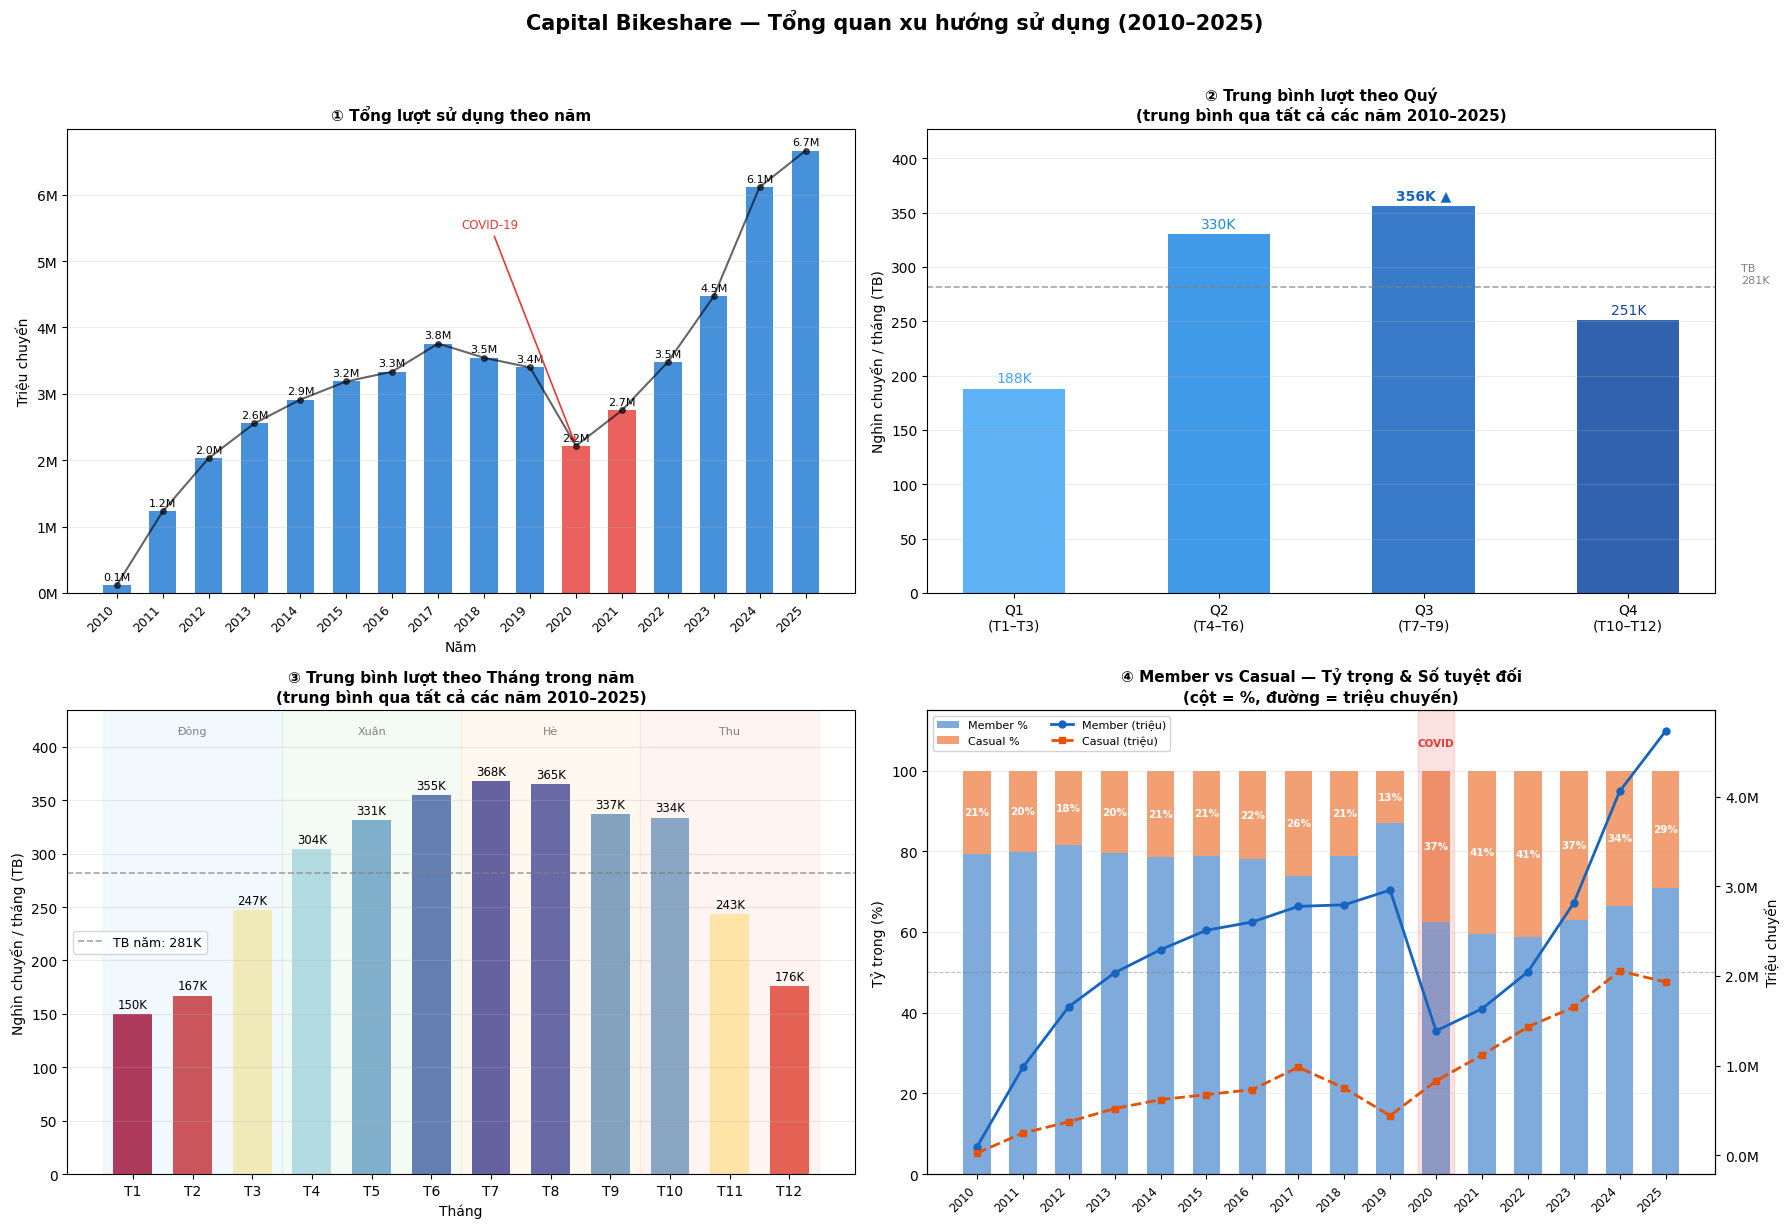

✅ Lưu → eda_overview.png


In [ ]:

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np
import pandas as pd

# ── Chuẩn bị số liệu dẫn xuất ────────────────────────────

# 1. Bỏ 2026 khỏi mọi biểu đồ tổng hợp theo năm/quý/tháng
#    vì chỉ có 3 tháng → gây hiểu nhầm xu hướng
agg_full = monthly_agg[monthly_agg["year"] < 2026].copy()

# 2. Trung bình lượt theo quý (trung bình qua tất cả các năm)
#    Tính quarter từ cột month: T1-T3=Q1, T4-T6=Q2, ...
agg_full["quarter"] = ((agg_full["month"] - 1) // 3 + 1)
quarterly_avg = (
    agg_full.groupby("quarter")["trips"].mean() / 1e3
)  # đơn vị: nghìn chuyến/tháng trung bình

# 3. Trung bình lượt theo tháng trong năm (trung bình qua các năm)
monthly_avg = (
    agg_full.groupby("month")["trips"].mean() / 1e3
)

# 4. Member/Casual theo năm — bỏ 2026
pivot_mc = (
    member_yearly[member_yearly["year"] < 2026]
    .pivot(index="year", columns="member_type", values="trips")
    .fillna(0)
)
for col in ["member", "casual"]:
    if col not in pivot_mc.columns:
        pivot_mc[col] = 0
pivot_mc["pct_member"] = (
    pivot_mc["member"] / (pivot_mc["member"] + pivot_mc["casual"]) * 100
)
pivot_mc["pct_casual"] = 100 - pivot_mc["pct_member"]

# ── Màu sắc nhất quán xuyên suốt ─────────────────────────
C_MAIN  = "#1976D2"   # xanh chính
C_Q     = ["#42A5F5", "#1E88E5", "#1565C0", "#0D47A1"]  # 4 quý sáng→tối
C_MEM   = "#1565C0"   # xanh đậm — Member
C_CAS   = "#E65100"   # cam      — Casual
C_COVID = "#E53935"   # đỏ       — COVID

MONTH_LABELS = ["T1","T2","T3","T4","T5","T6",
                "T7","T8","T9","T10","T11","T12"]

# ── Tạo figure 2×2 ───────────────────────────────────────
# 4 ô bằng nhau, khoảng cách vừa đủ để không chật
fig, axes = plt.subplots(2, 2, figsize=(18, 12))
fig.suptitle(
    "Capital Bikeshare — Tổng quan xu hướng sử dụng (2010–2025)",
    fontsize=15, fontweight="bold", y=1.02
)

# ════════════════════════════════════════════════════════
# PANEL 1 (trên trái): Tổng lượt theo năm
# Bar chart + line trend để thấy đồng thời số lượng và xu hướng
# ════════════════════════════════════════════════════════
ax1 = axes[0, 0]

yr_data = yearly_agg[yearly_agg["year"] < 2026]
years   = yr_data["year"].values
trips_m = yr_data["trips"].values / 1e6   # đổi sang triệu

# Bar chart — màu nhạt hơn ở COVID để gây chú ý
bar_colors = [
    C_COVID if y in [2020, 2021] else C_MAIN
    for y in years
]
bars = ax1.bar(years, trips_m, color=bar_colors,
               alpha=0.80, width=0.6)

# Ghi số lên đầu mỗi cột
for bar, v in zip(bars, trips_m):
    ax1.text(
        bar.get_x() + bar.get_width() / 2,
        v + 0.05,
        f"{v:.1f}M",
        ha="center", va="bottom", fontsize=8
    )

# Đường trend để thấy rõ chiều tăng/giảm
ax1.plot(years, trips_m, color="black",
         linewidth=1.5, marker="o", markersize=4,
         alpha=0.6, zorder=5)

# Chú thích COVID
ax1.annotate(
    "COVID-19",
    xy=(2020, yr_data[yr_data["year"]==2020]["trips"].values[0]/1e6),
    xytext=(2017.5, 5.5),
    fontsize=8.5, color=C_COVID,
    arrowprops=dict(arrowstyle="->", color=C_COVID, lw=1.2)
)

ax1.set_title("① Tổng lượt sử dụng theo năm",
              fontsize=11, fontweight="bold")
ax1.set_ylabel("Triệu chuyến")
ax1.set_xlabel("Năm")
ax1.set_xticks(years)
ax1.set_xticklabels(years, rotation=45, ha="right", fontsize=9)
ax1.grid(axis="y", alpha=0.25)
ax1.yaxis.set_major_formatter(
    mticker.FuncFormatter(lambda v, _: f"{v:.0f}M")
)

# ════════════════════════════════════════════════════════
# PANEL 2 (trên phải): Trung bình lượt theo quý
# 4 cột màu khác nhau Q1→Q4, ghi số rõ ràng
# Trả lời: quý nào cao điểm, quý nào thấp điểm?
# ════════════════════════════════════════════════════════
ax2 = axes[0, 1]

q_labels = ["Q1\n(T1–T3)", "Q2\n(T4–T6)",
            "Q3\n(T7–T9)", "Q4\n(T10–T12)"]

bars2 = ax2.bar(q_labels, quarterly_avg.values,
                color=C_Q, alpha=0.85, width=0.5)

# Ghi số + highlight quý cao nhất
max_q = quarterly_avg.idxmax()
for i, (bar, v) in enumerate(zip(bars2, quarterly_avg.values)):
    # Quý cao nhất in đậm, thêm mũi tên ↑
    label = f"{v:.0f}K" + (" ▲" if (i+1) == max_q else "")
    ax2.text(
        bar.get_x() + bar.get_width() / 2,
        v + 3,
        label,
        ha="center", va="bottom",
        fontsize=10,
        fontweight="bold" if (i+1) == max_q else "normal",
        color=C_Q[i]
    )

# Đường trung bình chung để dễ so sánh
mean_q = quarterly_avg.mean()
ax2.axhline(mean_q, color="gray", linewidth=1.2,
            linestyle="--", alpha=0.7)
ax2.text(3.55, mean_q + 2, f"TB\n{mean_q:.0f}K",
         fontsize=8, color="gray", va="bottom")

ax2.set_title("② Trung bình lượt theo Quý\n"
              "(trung bình qua tất cả các năm 2010–2025)",
              fontsize=11, fontweight="bold")
ax2.set_ylabel("Nghìn chuyến / tháng (TB)")
ax2.grid(axis="y", alpha=0.25)
ax2.set_ylim(0, quarterly_avg.max() * 1.2)

# ════════════════════════════════════════════════════════
# PANEL 3 (dưới trái): Trung bình lượt theo tháng trong năm
# Thấy rõ mùa vụ: hè (T6–T9) cao, đông (T1–T2) thấp
# Màu gradient từ xanh nhạt → xanh đậm theo mức độ
# ════════════════════════════════════════════════════════
ax3 = axes[1, 0]

# Tô màu theo mức: cao = xanh đậm, thấp = cam nhạt
vals   = monthly_avg.values
vmin   = vals.min()
vmax   = vals.max()
# Normalize 0→1 để map sang màu
norm   = (vals - vmin) / (vmax - vmin)
colors = plt.cm.RdYlBu(norm)     # đỏ=thấp, vàng=TB, xanh=cao

bars3 = ax3.bar(range(1, 13), vals,
                color=colors, alpha=0.85, width=0.65)

# Ghi số lên từng cột
for i, (bar, v) in enumerate(zip(bars3, vals)):
    ax3.text(
        bar.get_x() + bar.get_width() / 2,
        v + 3,
        f"{v:.0f}K",
        ha="center", va="bottom", fontsize=8.5
    )

# Đường trung bình
mean_m = vals.mean()
ax3.axhline(mean_m, color="gray", linewidth=1.2,
            linestyle="--", alpha=0.7,
            label=f"TB năm: {mean_m:.0f}K")

ax3.set_xticks(range(1, 13))
ax3.set_xticklabels(MONTH_LABELS)
ax3.set_title("③ Trung bình lượt theo Tháng trong năm\n"
              "(trung bình qua tất cả các năm 2010–2025)",
              fontsize=11, fontweight="bold")
ax3.set_ylabel("Nghìn chuyến / tháng (TB)")
ax3.set_xlabel("Tháng")
ax3.legend(fontsize=9)
ax3.grid(axis="y", alpha=0.25)
ax3.set_ylim(0, vals.max() * 1.18)

# Thêm nhãn mùa để dễ hiểu
for span, label, color in [
    ((0.5, 3.5),  "Đông",  "#90CAF9"),
    ((3.5, 6.5),  "Xuân",  "#A5D6A7"),
    ((6.5, 9.5),  "Hè",    "#FFCC80"),
    ((9.5, 12.5), "Thu",   "#FFAB91"),
]:
    ax3.axvspan(span[0], span[1], alpha=0.12, color=color)
    ax3.text((span[0]+span[1])/2, vals.max()*1.12,
             label, ha="center", fontsize=8, color="gray")

# ════════════════════════════════════════════════════════
# PANEL 4 (dưới phải): Member vs Casual — stacked bar % + line
# Stacked bar = tỷ trọng %, line = số tuyệt đối (trục phải)
# Gộp 2 thông tin vào 1 panel để tiết kiệm diện tích
# ════════════════════════════════════════════════════════
ax4  = axes[1, 1]
ax4r = ax4.twinx()   # trục y phải cho line chart số tuyệt đối

yr_mc = pivot_mc.index.tolist()
x4    = np.arange(len(yr_mc))

# Stacked bar % (trục trái)
ax4.bar(x4, pivot_mc["pct_member"],
        color=C_MEM, alpha=0.55, width=0.6,
        label="Member %")
ax4.bar(x4, pivot_mc["pct_casual"],
        bottom=pivot_mc["pct_member"],
        color=C_CAS, alpha=0.55, width=0.6,
        label="Casual %")

# Ghi % — chỉ ghi Casual để không chật
for i, pc in enumerate(pivot_mc["pct_casual"]):
    if pc > 8:
        ax4.text(x4[i],
                 pivot_mc["pct_member"].iloc[i] + pc/2,
                 f"{pc:.0f}%",
                 ha="center", va="center",
                 fontsize=7.5, color="white",
                 fontweight="bold")

# Line chart số tuyệt đối (trục phải)
ax4r.plot(x4, pivot_mc["member"] / 1e6,
          color=C_MEM, linewidth=2,
          marker="o", markersize=5,
          label="Member (triệu)")
ax4r.plot(x4, pivot_mc["casual"] / 1e6,
          color=C_CAS, linewidth=2,
          marker="s", markersize=5,
          linestyle="--",
          label="Casual (triệu)")

# Đánh dấu COVID
if 2020 in yr_mc:
    idx_c = yr_mc.index(2020)
    ax4.axvspan(idx_c - 0.4, idx_c + 0.4,
                alpha=0.15, color=C_COVID)
    ax4.text(idx_c, 106, "COVID",
             ha="center", fontsize=7.5,
             color=C_COVID, fontweight="bold")

ax4.axhline(50, color="gray", linewidth=0.8,
            linestyle="--", alpha=0.5)

ax4.set_xticks(x4)
ax4.set_xticklabels(yr_mc, rotation=45,
                    ha="right", fontsize=8.5)
ax4.set_ylim(0, 115)
ax4.set_ylabel("Tỷ trọng (%)", color="black", fontsize=10)
ax4r.set_ylabel("Triệu chuyến", color="black", fontsize=10)
ax4r.yaxis.set_major_formatter(
    mticker.FuncFormatter(lambda v, _: f"{v:.1f}M")
)

# Gộp legend của cả 2 trục
lines_l, labels_l = ax4.get_legend_handles_labels()
lines_r, labels_r = ax4r.get_legend_handles_labels()
ax4.legend(lines_l + lines_r, labels_l + labels_r,
           loc="upper left", fontsize=8, framealpha=0.9,
           ncol=2)

ax4.set_title("④ Member vs Casual — Tỷ trọng & Số tuyệt đối\n"
              "(cột = %, đường = triệu chuyến)",
              fontsize=11, fontweight="bold")
ax4.grid(axis="y", alpha=0.2)

# ── Lưu và hiển thị ──────────────────────────────────────
plt.tight_layout()
plt.savefig("eda_overview.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅ Lưu → eda_overview.png")

### Tổng lượt sử dụng theo năm (2010–2025)

"Tăng trưởng bền vững 15 năm — COVID-19 chỉ là gián đoạn tạm thời, hệ thống phục hồi mạnh mẽ và đạt đỉnh lịch sử 6.7M năm 2025"

 **Điểm đáng chú ý**

① Giai đoạn vàng 2010–2012

Từ 0.1M → 2.0M chỉ trong 2 năm — tốc độ tăng x20 lần

Phản ánh sức hút mạnh khi hệ thống bike-share mới ra mắt

② Đỉnh tiền COVID — 2017 (~3.8M)

Sau 5 năm tăng trưởng đều → bắt đầu có dấu hiệu bão hòa 2018–2019

2018–2019 đã giảm nhẹ trước cả COVID → cần xem xét yếu tố cạnh tranh (Uber, Lyft, scooter)

③ COVID-19 tác động 2020–2021 (cột đỏ)

2020: chạm đáy 2.2M — mức thấp nhất kể từ 2013

2021: hồi phục nhẹ lên 2.7M nhưng vẫn thấp hơn 2017 ~29%

Thời gian suy giảm chỉ 2 năm → hệ thống có khả năng phục hồi tốt

④ Giai đoạn bứt phá 2022–2025

2022: trở về mức tiền COVID (3.5M)

2023–2025: vượt xa mọi kỷ lục cũ, đạt 6.7M năm 2025

Tăng trưởng 2022→2025: +91% chỉ trong 3 năm → có thể do mở rộng mạng lưới trạm, e-bike

**Dự báo 2026Xu hướng đang tăng mạnh — cơ hội đầu tư**

## Trung bình lượt theo Quý & Tháng (2010–2025)

"Nhu cầu thuê xe mang tính mùa vụ rõ rệt — Hè là mùa vàng, Đông là đáy, biên độ chênh lệch lên tới 89% giữa tháng cao nhất và thấp nhất"

→ Q3 và Q2 vượt TB, Q1 và Q4 kéo tổng xuống → chiến lược nên tập trung nguồn lực vào T4–T9

2. Phân tích chi tiết theo Tháng

① Mùa Hè (T6–T8) — Vùng đỉnh

T7 đạt 368K — cao nhất năm

T6, T7, T8 đều trên 355K → 3 tháng liên tiếp duy trì đỉnh

Lý do: thời tiết đẹp, du lịch, hoạt động ngoài trời tăng mạnh

② Mùa Xuân (T4–T6) — Tăng tốc

Tăng đều từ 304K → 355K → đà tăng mạnh và nhất quán

T3→T4 tăng đột biến (+57K) — bước ngoặt chuyển mùa rõ nhất

③ Mùa Thu (T9–T11) — Giảm dần

T9: 337K → T10: 334K → T11: 243K

T11 giảm mạnh (-91K so với T10) — dấu hiệu mùa lạnh bắt đầu

④ Mùa Đông (T12–T2) — Đáy năm

T1 thấp nhất: 150K — chỉ bằng 41% so với đỉnh T7

T12 (176K) > T1 (150K) — Tháng 1 lạnh hơn tháng 12

##3. Biên độ mùa vụ

T7 (368K) ÷ T1 (150K) = 2.45 lần

→ Tháng cao điểm gấp 2.45 lần tháng thấp điểm

→ Mức độ mùa vụ RẤT CAO — cần chiến lược điều phối linh hoạt

### 4. Khuyến nghị kinh doanh
**Khuyến nghị                Thời điểm                      Lý do **

Tăng tối đa xe & trạm         T5–T8               Mùa cao điểm, tối đa doanh thu

Bảo trì hệ thống lớn         T1–T2               Nhu cầu thấp nhất, ít ảnh hưởng

Khuyến mãi kích cầu        T11–T12 & T1–T3    Kéo dài mùa + chống đáy mùa Đông

Chuẩn bị xe trước T4         Cuối T3        Tăng đột biến T3→T4, tránh thiếu hụt

Forecast & nhân sự           T6–T9           Cần nhân lực vận hành cao nhất năm

## Member vs Casual — Tỷ trọng & Số tuyệt đối (2010–2025)

"Member luôn là xương sống của hệ thống — nhưng COVID-19 là bước ngoặt làm thay đổi cấu trúc khách hàng, Casual tăng mạnh và chưa về lại mức tiền dịch"

→ Cơ cấu 4:1 (Member:Casual) duy trì suốt 10 năm → hệ thống phụ thuộc Member

- Giai đoạn 2010–2019: Member % duy trì ổn định 79–87%, Casual chỉ 13–21% → hệ sinh thái phụ thuộc hoàn toàn vào thành viên trung thành.
- Giai đoạn 2021–2025: Casual tăng mạnh lên 29–41% → cơ cấu người dùng đang đa dạng hóa đáng kể.

-> Member luôn chiếm ưu thế tuyệt đối — nhưng Casual đang bứt phá



## COVID đảo lộn (2020–2021):
 Member (triệu chuyến) sụt giảm mạnh năm 2020, trong khi Casual cũng co lại nhưng phục hồi nhanh hơn và mạnh hơn hậu COVID.

Đây là dấu hiệu cho thấy nhóm Casual linh hoạt hơn, ít bị ràng buộc bởi cam kết dài hạn → phản ứng tốt hơn với giai đoạn phục hồi.

- 2020 Member 63%, Casual % 37%             , Casual tăng gần gấp đôi tỷ trọng
- 2021 Member 59%, Casual % 41%             , Casual đạt đỉnh lịch sử

→ Lý do: Member (đi làm) giảm mạnh do WFH, Casual (giải trí/tản bộ) tăng tương đối vì người dân dùng xe đạp thay phương tiện công cộng để tránh dịch

## Giai đoạn 3: Phục hồi nhưng cấu trúc mới (2022–2025)

→ Member đang hồi phục về cơ cấu cũ nhưng Casual vẫn cao hơn tiền COVID (29% vs ~20%) → xuất hiện tệp khách hàng Casual mới bền vững

→ Dù tỷ trọng Member vẫn cao hơn, Casual tăng trưởng tuyệt đối nhanh gấp 2.4 lần Member → đây là nhóm tăng trưởng tiềm năng nhất

**Key Takeaways cho Slide**

① COVID là "phép thử tự nhiên" — cho thấy Casual có thể tăng mạnh khi điều kiện thay đổi → nhu cầu tiềm ẩn rất lớn

② Casual 2025 ~29% cao hơn hẳn mức tiền COVID ~20% → hệ thống đã thu hút được tệp khách hàng giải trí mới, không quay về cơ cấu cũ

③ Member tăng số tuyệt đối kỷ lục 2025 → cả 2 nhóm đều tăng, không có sự đánh đổi (trade-off)

### **Khuyến nghị**

Chương trình chuyển đổi Casual → Member  => Casual đang đông — cơ hội convert sang thuê bao

Gói membership linh hoạt (theo tháng/quý) =>  Hạ rào cản cho Casual chuyển đổi

Marketing riêng cho Casual    => Nhóm tăng trưởng nhanh nhất — không nên bỏ qua

Đo lường retention của Casual mới post-COVID  => Xác định tệp khách hàng bền vững vs nhất thời

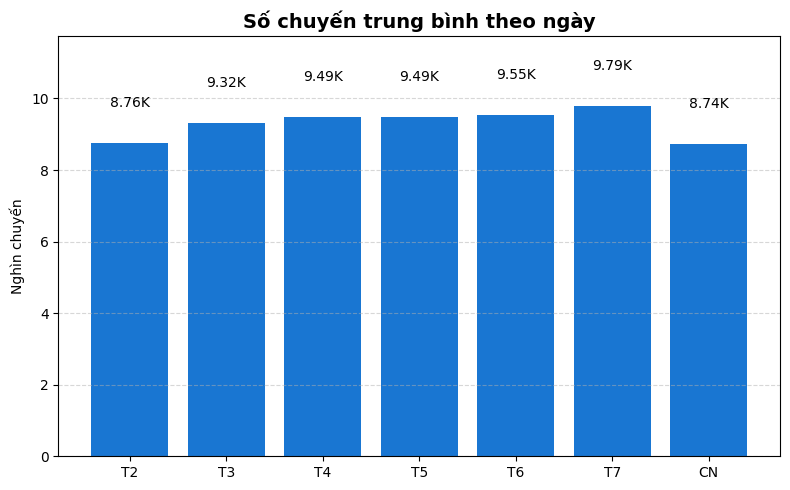

In [ ]:
import matplotlib.pyplot as plt

order_en = ["Monday","Tuesday","Wednesday","Thursday","Friday","Saturday","Sunday"]
order_vi = ["T2","T3","T4","T5","T6","T7","CN"]

daily_avg = (
    daily_agg.groupby("weekday")["trips"]
    .mean()
    .reindex(order_en) / 1000
)

plt.figure(figsize=(8,5))
bars = plt.bar(order_vi, daily_avg, color="#1976D2")

# Label 2 số thập phân
for i, v in enumerate(daily_avg):
    plt.text(i, v + 1, f"{v:.2f}K", ha='center', fontsize=10)

plt.title("Số chuyến trung bình theo ngày", fontsize=14, weight='bold')
plt.ylabel("Nghìn chuyến")
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.ylim(0, daily_avg.max()*1.2)

plt.tight_layout()
plt.show()

### "Nhu cầu thuê xe khá đồng đều cả tuần — Thứ 7 đạt đỉnh, Chủ nhật và Thứ 2 là đáy, gợi ý sự pha trộn giữa nhu cầu đi làm và giải trí"



** Điểm đáng chú ý**

① Thứ 7 cao nhất ~9.79K nhưng Chủ nhật lại thấp nhất ~8.74K

→ Cho thấy Casual dùng T7 để vui chơi nhưng CN nghỉ ngơi ở nhà

→ Member vẫn đi làm T7 (một số công ty làm T7) nhưng nghỉ CN

② Thứ 2 thấp thứ 2 ~8.76K

→ Hiệu ứng "đầu tuần" — người dùng chưa vào guồng, hoặc làm việc từ xa

③ Biên độ dao động cả tuần chỉ ~11.5% (8.74K → 9.79K)

→ Nhu cầu rất ổn định, không có ngày nào quá thấp → hệ thống hoạt động đều

## Biểu đồ sử dụng xe của 2 nhóm khách hàng trong ngày theo giờ

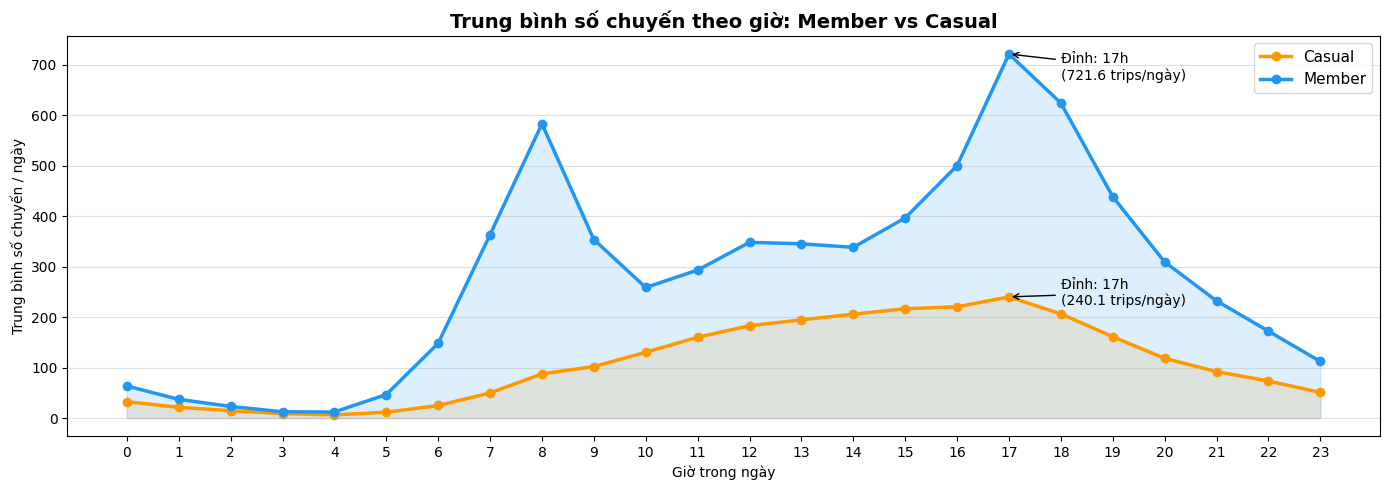

In [ ]:
fig, ax = plt.subplots(figsize=(14, 5))

colors = {"member": "#2196F3", "casual": "#FF9800"}

for member_type, group in hourly_agg.groupby("member_type"):
    ax.plot(group["hour"], group["trips"],
            marker="o", linewidth=2.5,
            color=colors[member_type],
            label=member_type.capitalize())
    ax.fill_between(group["hour"], group["trips"],
                    alpha=0.15, color=colors[member_type])

    # Đánh dấu đỉnh
    peak_hour = group.loc[group["trips"].idxmax(), "hour"]
    peak_val  = group["trips"].max()
    ax.annotate(f"Đỉnh: {peak_hour}h\n({peak_val:.1f} trips/ngày)",
                xy=(peak_hour, peak_val),
                xytext=(peak_hour + 1, peak_val * 0.93),
                arrowprops=dict(arrowstyle="->", color="black"),
                fontsize=10)

ax.set_title("Trung bình số chuyến theo giờ: Member vs Casual",
             fontsize=14, fontweight="bold")
ax.set_xlabel("Giờ trong ngày")
ax.set_ylabel("Trung bình số chuyến / ngày")
ax.set_xticks(range(0, 24))
ax.legend(fontsize=11)
ax.grid(axis="y", alpha=0.4)
plt.tight_layout()
plt.show()

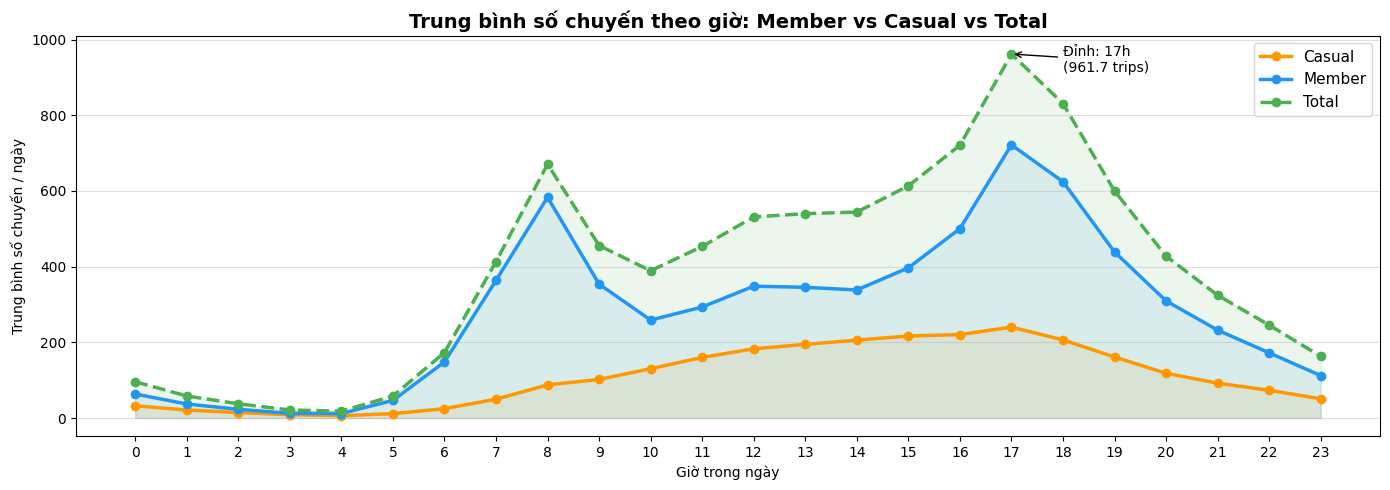

In [ ]:
# Tính tổng cả 2 nhóm theo giờ
hourly_total = (
    hourly_agg
      .groupby("hour")["trips"].sum()
      .reset_index()
)
hourly_total["member_type"] = "total"

# Vẽ biểu đồ
fig, ax = plt.subplots(figsize=(14, 5))

colors = {"member": "#2196F3", "casual": "#FF9800", "total": "#4CAF50"}

# Vẽ member & casual
for member_type, group in hourly_agg.groupby("member_type"):
    ax.plot(group["hour"], group["trips"],
            marker="o", linewidth=2.5,
            color=colors[member_type],
            label=member_type.capitalize())
    ax.fill_between(group["hour"], group["trips"],
                    alpha=0.1, color=colors[member_type])

# Vẽ đường total
ax.plot(hourly_total["hour"], hourly_total["trips"],
        marker="o", linewidth=2.5, linestyle="--",
        color=colors["total"], label="Total")
ax.fill_between(hourly_total["hour"], hourly_total["trips"],
                alpha=0.1, color=colors["total"])

# Đánh dấu đỉnh của Total
peak_hour = hourly_total.loc[hourly_total["trips"].idxmax(), "hour"]
peak_val  = hourly_total["trips"].max()
ax.annotate(f"Đỉnh: {peak_hour}h\n({peak_val:.1f} trips)",
            xy=(peak_hour, peak_val),
            xytext=(peak_hour + 1, peak_val * 0.95),
            arrowprops=dict(arrowstyle="->", color="black"),
            fontsize=10)

ax.set_title("Trung bình số chuyến theo giờ: Member vs Casual vs Total",
             fontsize=14, fontweight="bold")
ax.set_xlabel("Giờ trong ngày")
ax.set_ylabel("Trung bình số chuyến / ngày")
ax.set_xticks(range(0, 24))
ax.legend(fontsize=11)
ax.grid(axis="y", alpha=0.4)
plt.tight_layout()
plt.show()

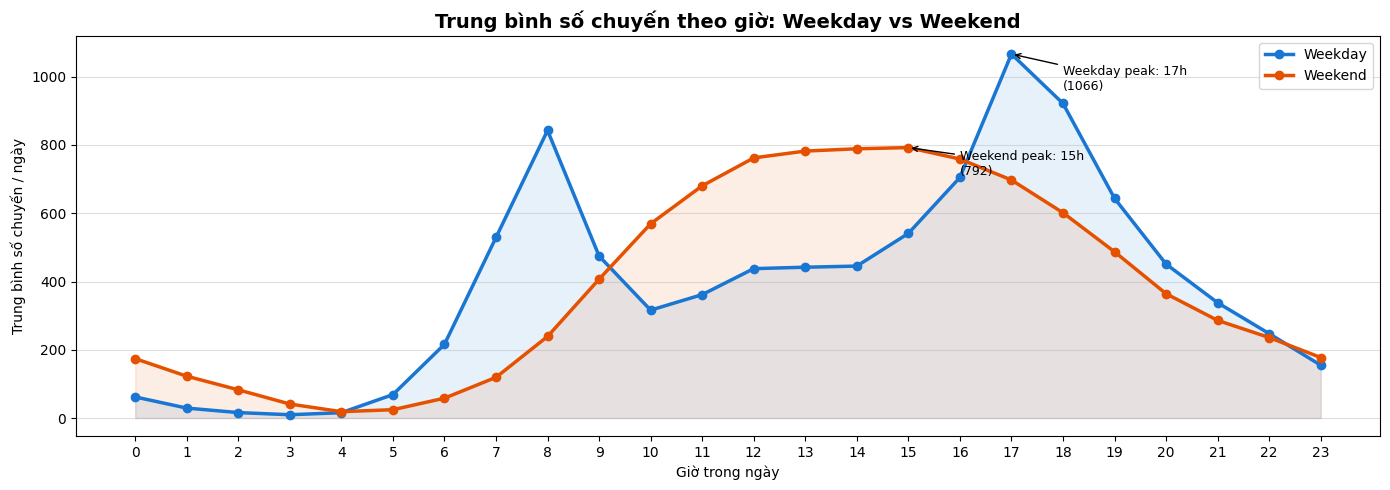

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ==============================
# 1. Chuẩn bị dữ liệu
# ==============================
hourly_raw_copy = hourly_raw.copy()
hourly_raw_copy['date'] = pd.to_datetime(hourly_raw_copy['date'])

# Tạo weekday index (0=Monday, 6=Sunday)
hourly_raw_copy['weekday'] = hourly_raw_copy['date'].dt.weekday

# Phân loại weekday vs weekend
hourly_raw_copy['day_type'] = np.where(
    hourly_raw_copy['weekday'] < 5,
    'Weekday',
    'Weekend'
)

# ==============================
# 2. Gộp về cấp NGÀY + GIỜ
# ==============================
hourly_daily = (
    hourly_raw_copy
    .groupby(['date', 'hour', 'day_type'])['trips']
    .sum()
    .reset_index()
)

# ==============================
# 3. Tính TRUNG BÌNH theo giờ
# ==============================
hourly_avg = (
    hourly_daily
    .groupby(['hour', 'day_type'])['trips']
    .mean()
    .reset_index()
)

# ==============================
# 4. Vẽ biểu đồ
# ==============================
fig, ax = plt.subplots(figsize=(14, 5))

colors = {"Weekday": "#1976D2", "Weekend": "#E65100"}

for day_type, group in hourly_avg.groupby("day_type"):
    ax.plot(group["hour"], group["trips"],
            marker="o", linewidth=2.5,
            color=colors[day_type],
            label=day_type)

    ax.fill_between(group["hour"], group["trips"],
                    alpha=0.1, color=colors[day_type])

# ==============================
# 5. Highlight peak từng nhóm
# ==============================
for day_type, group in hourly_avg.groupby("day_type"):
    peak_hour = group.loc[group["trips"].idxmax(), "hour"]
    peak_val  = group["trips"].max()

    ax.annotate(f'{day_type} peak: {peak_hour}h\n({peak_val:.0f})',
                xy=(peak_hour, peak_val),
                xytext=(peak_hour + 1, peak_val * 0.9),
                arrowprops=dict(arrowstyle="->"),
                fontsize=9)

# ==============================
# 6. Format biểu đồ
# ==============================
ax.set_title("Trung bình số chuyến theo giờ: Weekday vs Weekend",
             fontsize=14, fontweight="bold")

ax.set_xlabel("Giờ trong ngày")
ax.set_ylabel("Trung bình số chuyến / ngày")

ax.set_xticks(range(0, 24))
ax.legend()
ax.grid(axis="y", alpha=0.4)

plt.tight_layout()
plt.show()

### "Member là động lực chính của hệ thống — hành vi theo giờ hành chính rõ rệt, trong khi Casual phản ánh nhu cầu giải trí linh hoạt suốt ban ngày"

 2. **Đặc điểm hành vi từng nhóm**

🔵 Member:

Đỉnh 8h ~590 và 17h ~720 — chênh lệch rõ, đỉnh chiều cao hơn sáng ~22%
Giảm mạnh 9h–10h sau giờ cao điểm sáng → di chuyển mục đích rõ ràng
Gần như không hoạt động 0h–4h

🟠 Casual:

Không có đỉnh sáng — bằng chứng rõ nhất cho thấy không dùng xe để đi làm
Tăng dần từ 6h → đỉnh nhẹ ~17h ~240 → đây là đỉnh duy nhất
Duy trì mức khá ổn định 10h–17h ~170–240 → hành vi dạo chơi, giải trí

=> → Casual đóng góp lớn nhất tương đối vào ban ngày — cơ hội khai thác nhóm này

 **Khuyến nghị kinh doanh**

- Tăng cường xe lúc 7h–8h và 16h–17h   => Đáp ứng đỉnh Member, tránh thiếu xe
- Khuyến mãi Casual vào 10h–15h   => Khung giờ Casual hoạt động nhiều nhất
- Chương trình đêm khuya (0h–4h)  => Nhu cầu thấp nhưng ổn định — cơ hội cho Member ca đêm
- Bảo trì xe lúc 2h–5h sángVùng nhu cầu thấp nhất toàn ngày  => Chuyển đổi Casual → Member  => Target Casual dùng xe giờ tan làm (17h) — gần với hành vi Member

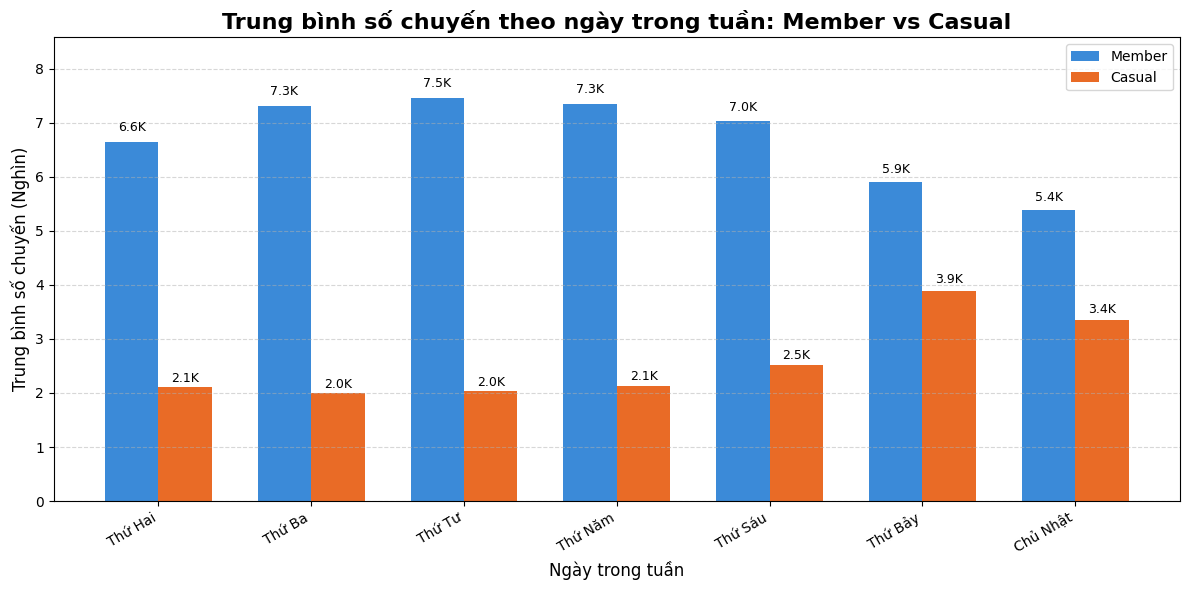

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ==============================
# 1. Chuẩn bị dữ liệu
# ==============================
hourly_raw_copy = hourly_raw.copy()

hourly_raw_copy['date'] = pd.to_datetime(hourly_raw_copy['date'])
hourly_raw_copy['day_name'] = hourly_raw_copy['date'].dt.day_name()

# Mapping thứ
order_en = ["Monday","Tuesday","Wednesday","Thursday","Friday","Saturday","Sunday"]
order_vi = ["Thứ Hai","Thứ Ba","Thứ Tư","Thứ Năm","Thứ Sáu","Thứ Bảy","Chủ Nhật"]

day_name_map = dict(zip(order_en, order_vi))
hourly_raw_copy['day_name_vi'] = hourly_raw_copy['day_name'].map(day_name_map)

# ==============================
# 2. Gộp về cấp NGÀY
# ==============================
daily_data = (
    hourly_raw_copy
    .groupby(['date', 'day_name_vi', 'member_type'])['trips']
    .sum()
    .reset_index()
)

# ==============================
# 3. Tính TRUNG BÌNH theo weekday & loại khách
# ==============================
daily_member_type_avg = (
    daily_data
    .groupby(['day_name_vi', 'member_type'])['trips']
    .mean()
    .unstack()
    .reindex(order_vi) / 1000   # đổi sang nghìn chuyến
)

# ==============================
# 4. Vẽ biểu đồ
# ==============================
fig, ax = plt.subplots(figsize=(12, 6))

bar_width = 0.35
index = np.arange(len(order_vi))

bars_member = ax.bar(index - bar_width/2,
                     daily_member_type_avg['member'],
                     bar_width,
                     label='Member',
                     color='#1976D2',
                     alpha=0.85)

bars_casual = ax.bar(index + bar_width/2,
                     daily_member_type_avg['casual'],
                     bar_width,
                     label='Casual',
                     color='#E65100',
                     alpha=0.85)

# ==============================
# 5. Fix ylim (tránh dính khung)
# ==============================
max_val = daily_member_type_avg.max().max()
ax.set_ylim(0, max_val * 1.15)

# ==============================
# 6. Ghi label (fix khoảng cách đẹp)
# ==============================
for bars in [bars_member, bars_casual]:
    for bar in bars:
        yval = bar.get_height()
        ax.text(
            bar.get_x() + bar.get_width()/2,
            yval + yval * 0.02,   # offset 2% chiều cao
            f'{yval:.1f}K',
            ha='center',
            va='bottom',
            fontsize=9
        )

# ==============================
# 7. Format biểu đồ
# ==============================
ax.set_xlabel('Ngày trong tuần', fontsize=12)
ax.set_ylabel('Trung bình số chuyến (Nghìn)', fontsize=12)

ax.set_title('Trung bình số chuyến theo ngày trong tuần: Member vs Casual',
             fontsize=16,
             fontweight='bold')

ax.set_xticks(index)
ax.set_xticklabels(order_vi, rotation=30, ha='right')

ax.legend()
ax.grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

Tổng số chuyến theo ngày trong tuần: Member vs Casual
**bold text**
Biểu đồ này giúp chúng ta hình dung rõ ràng hành vi đi lại khác nhau giữa khách hàng 'Member' (thành viên) và 'Casual' (khách vãng lai) vào mỗi ngày trong tuần.

**Điểm đáng chú ý:**

**Khách hàng Member (màu xanh):**
- Lượng chuyến của Member rất cao và tương đối ổn định từ Thứ Hai đến Thứ Sáu, với đỉnh điểm vào các ngày giữa tuần (Thứ Ba, Thứ Tư, Thứ Năm), mỗi ngày đạt khoảng 5.9-6.0 triệu chuyến.
- Vào cuối tuần, lượng chuyến của Member giảm đáng kể, chỉ còn khoảng 4.3-4.8 triệu chuyến vào Thứ Bảy và Chủ Nhật. Điều này củng cố giả định rằng Member chủ yếu sử dụng xe cho mục đích đi lại hàng ngày (công việc, học tập) trong tuần.

**Khách hàng Casual (màu cam):**
- Ngược lại với Member, lượng chuyến của Casual thấp hơn nhiều vào các ngày trong tuần (khoảng 1.6-2.0 triệu chuyến).
- Tuy nhiên, lượng chuyến của Casual tăng đột biến vào cuối tuần, đặc biệt là Thứ Bảy, đạt khoảng 3.1 triệu chuyến – đây là mức cao nhất của Casual trong tuần. Chủ Nhật cũng duy trì mức cao khoảng 2.7 triệu chuyến.
- Điều này cho thấy Casual chủ yếu sử dụng xe đạp cho các hoạt động giải trí, du lịch hoặc dạo chơi vào cuối tuần.

**Nhận định chung và Khuyến nghị**:

1. Sự khác biệt rõ ràng về mục đích sử dụng: Member là cốt lõi trong tuần làm việc, Casual thống trị vào cuối tuần.
2. Đỉnh cao điểm cuối tuần: Thứ Bảy là ngày hoạt động mạnh nhất của khách hàng Casual, vượt xa các ngày khác trong tuần.
3. Chiến lược tối ưu hóa:
- Đối với Member: Đảm bảo đủ xe và dịch vụ bảo trì nhanh chóng vào các ngày trong tuần, đặc biệt là giờ cao điểm.
- Đối với Casual: Tập trung các chiến dịch khuyến mãi, gói thuê linh hoạt, và tăng cường kiểm tra, phân phối xe tại các khu vực du lịch, giải trí vào Thứ Bảy và Chủ Nhật.
- Có thể cân nhắc các chương trình chuyển đổi khách Casual sang Member vào cuối tuần bằng cách giới thiệu lợi ích của thẻ thành viên cho những người sử dụng thường xuyên vào Thứ Bảy/Chủ Nhật.

Khuyến nghị cho slide báo cáo:

- "Giai đoạn 2020–2025 đánh dấu sự chuyển dịch cơ cấu người dùng: từ mô hình Member-centric sang mô hình hỗn hợp.
- Ưu tiên chiến lược chuyển đổi Casual thành Member sẽ là đòn bẩy tăng trưởng bền vững giai đoạn tới."

## Biểu đồ Heatmap số lượt theo các giờ trong tuần

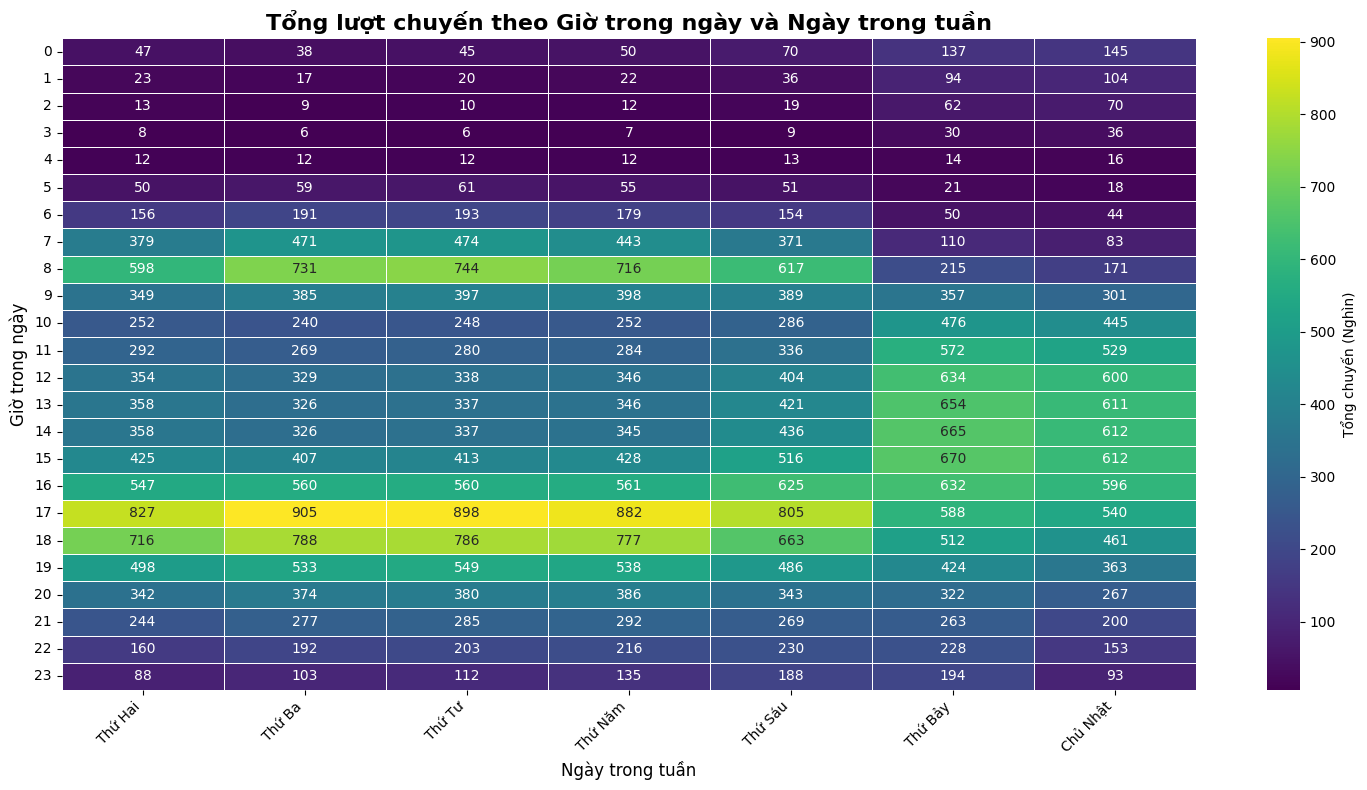

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Chuẩn bị dữ liệu cho heatmap:
# 1. Thêm cột 'day_of_week' và 'day_name' vào hourly_raw
hourly_raw_copy = hourly_raw.copy()
hourly_raw_copy['date'] = pd.to_datetime(hourly_raw_copy['date']) # Convert 'date' column to datetime
hourly_raw_copy['day_of_week'] = hourly_raw_copy['date'].dt.dayofweek # Monday=0, Sunday=6
hourly_raw_copy['day_name'] = hourly_raw_copy['date'].dt.day_name()

# 2. Tạo thứ tự cho các ngày trong tuần (Việt hóa)
order_en = ["Monday","Tuesday","Wednesday","Thursday","Friday","Saturday","Sunday"]
order_vi = ["Thứ Hai","Thứ Ba","Thứ Tư","Thứ Năm","Thứ Sáu","Thứ Bảy","Chủ Nhật"]
day_name_map = dict(zip(order_en, order_vi))

hourly_raw_copy['day_name_vi'] = hourly_raw_copy['day_name'].map(day_name_map)

# 3. Tính tổng số chuyến theo giờ và ngày trong tuần
heatmap_data = (
    hourly_raw_copy.groupby(['day_name_vi', 'hour'])['trips'].sum()
    .unstack(level='hour')
)

# Sắp xếp lại thứ tự các ngày trong tuần
heatmap_data = heatmap_data.reindex(order_vi)

# 4. Vẽ heatmap
plt.figure(figsize=(15, 8))
sns.heatmap(
    (heatmap_data.T) / 1000, # Transpose và chia cho 1000 để đơn vị là Nghìn chuyến
    cmap='viridis',      # Tông màu từ tím đến vàng
    fmt=".0f",         # Định dạng số nguyên
    annot=True,          # Hiện giá trị trên heatmap
    linewidths=.5,       # Khoảng cách giữa các ô
    cbar_kws={'label': 'Tổng chuyến (Nghìn)'}
)

plt.title('Tổng lượt chuyến theo Giờ trong ngày và Ngày trong tuần', fontsize=16, fontweight='bold')
plt.xlabel('Ngày trong tuần', fontsize=12)
plt.ylabel('Giờ trong ngày', fontsize=12)
plt.xticks(rotation=45, ha='right') # Đảm bảo tên ngày không bị xoay
plt.yticks(rotation=0) # Đảm bảo tên ngày không bị xoay
plt.tight_layout()
plt.show()

Tổng lượt chuyến theo Giờ trong ngày và Ngày trong tuần

Biểu đồ này trực quan hóa cách mà tổng số chuyến xe đạp được phân bổ theo từng giờ trong ngày và từng ngày trong tuần. Màu sắc càng đậm (chuyển sang vàng) cho thấy số lượng chuyến càng cao.

**Điểm đáng chú ý:**

Giờ cao điểm:
- Trong các ngày làm việc (Thứ Hai - Thứ Sáu), có hai đỉnh rõ rệt: vào buổi sáng (khoảng 7h-9h) và buổi chiều tối (khoảng 16h-18h). Điều này phản ánh rõ nét nhu cầu đi lại cho mục đích đi làm/đi học của những người sử dụng dạng 'member'.
Đỉnh buổi chiều tối thường cao hơn đỉnh buổi sáng, đặc biệt vào Thứ Ba, Thứ Tư, Thứ Năm.

Cuối tuần:
- Thứ Bảy và Chủ Nhật có mô hình sử dụng khác biệt. Không có đỉnh cao điểm rõ rệt như các ngày trong tuần. Thay vào đó, nhu cầu duy trì ở mức cao và tương đối ổn định từ khoảng 10h sáng đến 19h tối, đặc biệt vào Thứ Bảy. Điều này gợi ý rằng vào cuối tuần, người dùng (chủ yếu là 'casual') sử dụng xe đạp cho các hoạt động giải trí, du lịch hoặc dạo chơi.
- Thứ Bảy có lượng chuyến cao nhất trong tuần, đặc biệt vào các giờ buổi chiều.

Giờ thấp điểm:
- Từ 0h đến 5h sáng là khoảng thời gian có ít chuyến đi nhất trong tất cả các ngày trong tuần. Đây là lúc nhu cầu sử dụng xe đạp gần như không có.

Sự khác biệt giữa các ngày trong tuần:

- Các ngày giữa tuần (Thứ Ba, Thứ Tư, Thứ Năm) có lượng chuyến cao và ổn định trong giờ cao điểm so với Thứ Hai và Thứ Sáu, có thể do hiệu ứng khởi đầu/kết thúc tuần làm việc.
- Thứ Sáu vẫn duy trì hai đỉnh nhưng có xu hướng giảm nhẹ so với các ngày giữa tuần, và buổi tối có thể có thêm nhu cầu giải trí.

Kết luận:

Biểu đồ heatmap này xác nhận rõ ràng tính mùa vụ theo giờ trong ngày và ngày trong tuần của việc sử dụng xe đạp. Nhu cầu tập trung vào giờ đi làm/tan làm trong tuần và nhu cầu giải trí kéo dài suốt cả ngày vào cuối tuần, với Thứ Bảy là ngày có tổng số chuyến cao nhất trong ngày cuối tuần.

###  Heatmap giờ × weekday, tách casual vs registered ──


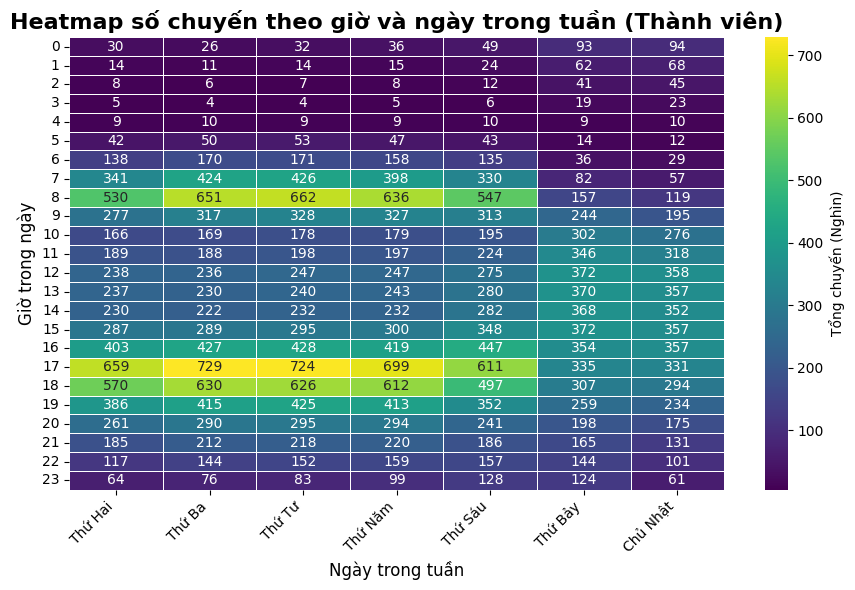

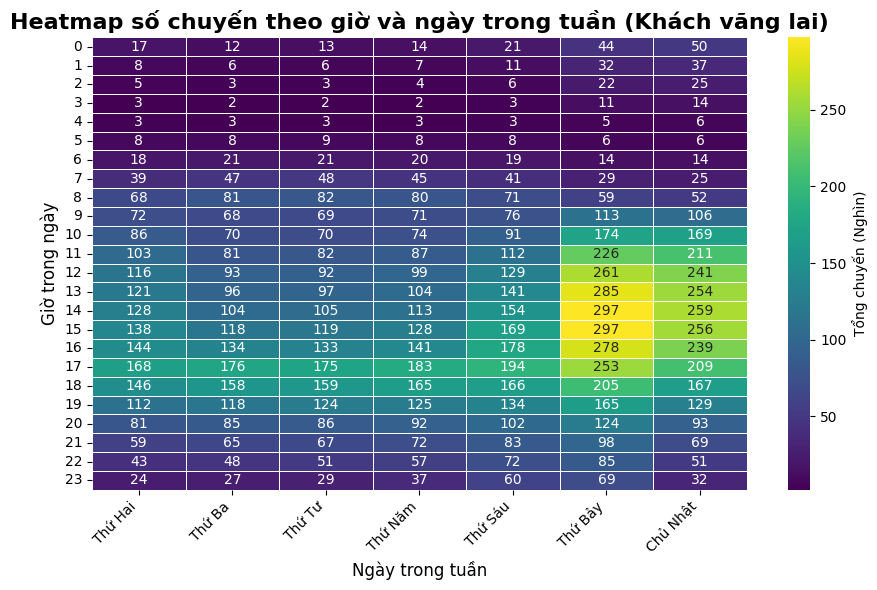

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

# Prepare data from hourly_raw (ensure date is datetime type)
hourly_raw_copy = hourly_raw.copy()
hourly_raw_copy['date'] = pd.to_datetime(hourly_raw_copy['date'])
hourly_raw_copy['day_of_week'] = hourly_raw_copy['date'].dt.dayofweek # Monday=0, Sunday=6
hourly_raw_copy['day_name'] = hourly_raw_copy['date'].dt.day_name()

# Create order for weekdays (Vietnamese)
order_en = ["Monday","Tuesday","Wednesday","Thursday","Friday","Saturday","Sunday"]
order_vi = ["Thứ Hai","Thứ Ba","Thứ Tư","Thứ Năm","Thứ Sáu","Thứ Bảy","Chủ Nhật"]
day_name_map = dict(zip(order_en, order_vi))

hourly_raw_copy['day_name_vi'] = hourly_raw_copy['day_name'].map(day_name_map)

# Loop through each member type to create separate heatmaps
member_types = ['member', 'casual']
titles = {
    'member': 'Heatmap số chuyến theo giờ và ngày trong tuần (Thành viên)',
    'casual': 'Heatmap số chuyến theo giờ và ngày trong tuần (Khách vãng lai)'
}

for m_type in member_types:
    # Filter data for the current member_type
    df_filtered = hourly_raw_copy[hourly_raw_copy['member_type'] == m_type].copy()

    # Calculate total trips by hour and weekday
    heatmap_data = (
        df_filtered.groupby(['day_name_vi', 'hour'])['trips'].sum()
        .unstack(level='hour')
    )

    # Reindex to ensure correct weekday order
    heatmap_data = heatmap_data.reindex(order_vi)

    # Plot heatmap
    plt.figure(figsize=(9, 6))
    sns.heatmap(
        (heatmap_data.T) / 1000, # Transpose and divide by 1000 for 'Nghìn chuyến'
        cmap='viridis',        # Color map from purple to yellow
        fmt=".0f",           # Format integers
        annot=True,            # Show values on heatmap
        linewidths=.5,         # Lines between cells
        cbar_kws={'label': 'Tổng chuyến (Nghìn)'}
    )

    plt.title(titles[m_type], fontsize=16, fontweight='bold')
    plt.xlabel('Ngày trong tuần', fontsize=12)
    plt.ylabel('Giờ trong ngày', fontsize=12)
    plt.xticks(rotation=45, ha='right')
    plt.yticks(rotation=0)
    plt.tight_layout()
    plt.show()


Kết luận chung từ heatmap: Hai nhóm khách hàng có hành vi sử dụng xe đạp hoàn toàn khác biệt. Nhóm Registered là 'xương sống' tạo ra nhu cầu ổn định vào ngày làm việc, trong khi nhóm Casual tạo ra nhu cầu biến động hơn, tập trung vào cuối tuần và giữa ngày.

# Vẫn nhiều khách vãng lai sử dụng xe cho nhu cầu đi học đi làm, có chiến lược đưa khách vãng lai chuyển sang làm thành viên

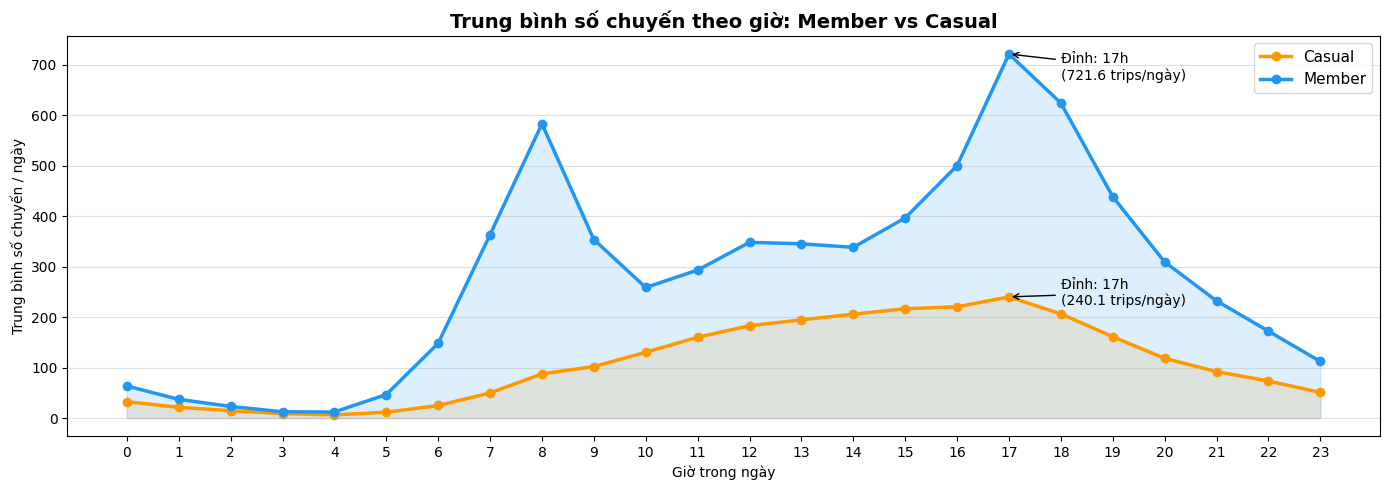

In [ ]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(14, 5))

colors = {"member": "#2196F3", "casual": "#FF9800"}

for member_type, group in hourly_agg.groupby("member_type"):
    ax.plot(group["hour"], group["trips"],
            marker="o", linewidth=2.5,
            color=colors[member_type],
            label=member_type.capitalize())
    ax.fill_between(group["hour"], group["trips"],
                    alpha=0.15, color=colors[member_type])

    # Đánh dấu đỉnh
    peak_hour = group.loc[group["trips"].idxmax(), "hour"]
    peak_val  = group["trips"].max()
    ax.annotate(f"Đỉnh: {peak_hour}h\n({peak_val:.1f} trips/ngày)",
                xy=(peak_hour, peak_val),
                xytext=(peak_hour + 1, peak_val * 0.93),
                arrowprops=dict(arrowstyle="->", color="black"),
                fontsize=10)

ax.set_title("Trung bình số chuyến theo giờ: Member vs Casual",
             fontsize=14, fontweight="bold")
ax.set_xlabel("Giờ trong ngày")
ax.set_ylabel("Trung bình số chuyến / ngày")
ax.set_xticks(range(0, 24))
ax.legend(fontsize=11)
ax.grid(axis="y", alpha=0.4)
plt.tight_layout()
plt.show()

## Top 15 trạm có số lượt đi cao nhất

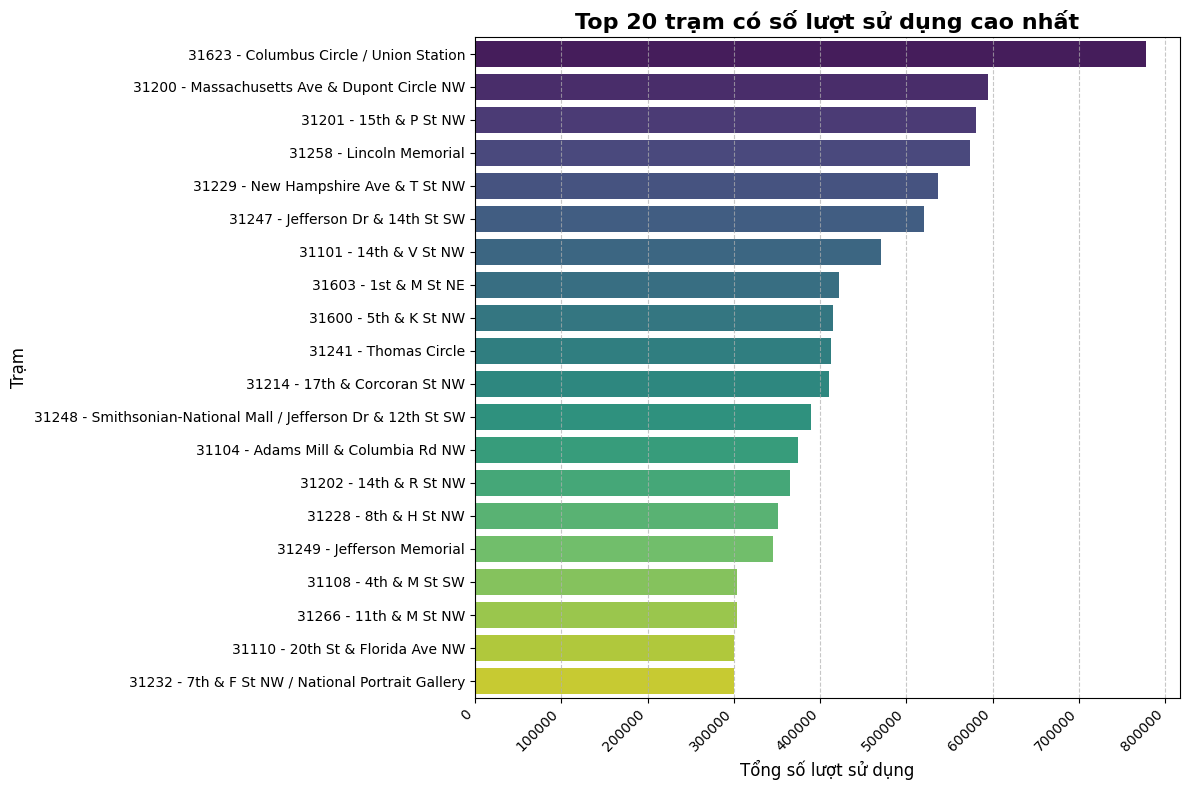

✅ Đã hiển thị biểu đồ top 20 trạm có số lượt sử dụng cao nhất.
Để điều phối xe, bạn nên tập trung vào các trạm này do có nhu cầu cao.


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Lấy top 20 trạm có số lượt sử dụng cao nhất
top_n_stations = 20
station_display = station_agg.head(top_n_stations).copy()

# Tạo cột nhãn bao gồm cả ID và Tên trạm
station_display['station_label'] = station_display['station_id'].astype(str) + ' - ' + station_display['station_name']

plt.figure(figsize=(12, 8))
sns.barplot(
    x='trips',
    y='station_label',
    data=station_display,
    palette='viridis',
    orient='h' # Biểu đồ ngang
)

plt.title(f'Top {top_n_stations} trạm có số lượt sử dụng cao nhất', fontsize=16, fontweight='bold')
plt.xlabel('Tổng số lượt sử dụng', fontsize=12)
plt.ylabel('Trạm', fontsize=12)
plt.ticklabel_format(style='plain', axis='x') # Tắt định dạng khoa học cho trục x
plt.xticks(rotation=45, ha='right') # Xoay nhãn trục x để dễ đọc
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

print(f"✅ Đã hiển thị biểu đồ top {top_n_stations} trạm có số lượt sử dụng cao nhất.")
print("Để điều phối xe, bạn nên tập trung vào các trạm này do có nhu cầu cao.")

### Bảng số liệu tổng số chuyến và tỷ lệ phần trăm của mỗi trạm

In [ ]:
# Tổng số trạm là
total_stations = len(station_agg)
print(f'số lượng trạm:{total_stations}')

số lượng trạm:1692


In [ ]:
# Top 15 trạm chiếm tỷ lệ % cao nhất
# Calculate total trips across all stations
total_overall_trips = station_agg['trips'].sum()

# Calculate percentage for each station
station_agg['percentage'] = (station_agg['trips'] / total_overall_trips) * 100

# Display the table with count and percentage
display(station_agg[['station_name', 'trips', 'percentage']].head(15))


,station_name,trips,percentage
529,Columbus Circle / Union Station,777961,1.585644
236,Massachusetts Ave & Dupont Circle NW,594060,1.210816
237,15th & P St NW,580871,1.183935
309,Lincoln Memorial,573281,1.168465
275,New Hampshire Ave & T St NW,536264,1.093016
297,Jefferson Dr & 14th St SW,520575,1.061039
187,14th & V St NW,470864,0.959718
506,1st & M St NE,421679,0.859468
503,5th & K St NW,414793,0.845433
291,Thomas Circle,412676,0.841119


## Chuẩn hóa dữ liệu để huấn luyện mô hình

CHUẨN BỊ DATA CHO MODEL

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.gridspec as gridspec
import warnings
warnings.filterwarnings("ignore")

from scipy import stats
from statsmodels.tsa.seasonal import STL
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_absolute_percentage_error
from xgboost import XGBRegressor
from prophet import Prophet

In [ ]:
# BƯỚC 1 — CHUẨN BỊ monthly_df TỪ monthly_agg
# monthly_agg từ file 18 có cột: year, month, trips

# Tạo cột ds (datetime Month Start) để làm index thời gian
monthly_df = monthly_agg.copy()
monthly_df["ds"] = pd.to_datetime(
    monthly_df[["year", "month"]].assign(day=1)
)
monthly_df = monthly_df.rename(columns={"trips": "y"})
monthly_df = monthly_df[["ds", "y"]].sort_values("ds").reset_index(drop=True)

print(f"✅ monthly_df: {len(monthly_df)} tháng")
print(f"   Từ: {monthly_df['ds'].min().date()} → {monthly_df['ds'].max().date()}")


✅ monthly_df: 187 tháng
   Từ: 2010-09-01 → 2026-03-01


In [ ]:
# BƯỚC 2 — FEATURE ENGINEERING
# Tạo đầy đủ features thời gian + lag + rolling + covid flag

# 2.1 Time features cơ bản
monthly_df["month"]   = monthly_df["ds"].dt.month    # mùa vụ trong năm (1-12)
monthly_df["quarter"] = monthly_df["ds"].dt.quarter  # quý (1-4)
monthly_df["year"]    = monthly_df["ds"].dt.year     # xu hướng dài hạn
monthly_df["t"]       = range(len(monthly_df))       # index tuyến tính (dùng cho LR)

# 2.2 Lag features — bắt pattern trễ
monthly_df["lag_1"]  = monthly_df["y"].shift(1)    # tháng liền trước
monthly_df["lag_2"]  = monthly_df["y"].shift(2)    # 2 tháng trước
monthly_df["lag_12"] = monthly_df["y"].shift(12)   # cùng kỳ năm ngoái (quan trọng nhất)

# 2.3 Rolling mean — xu hướng ngắn hạn
# shift(1) trước rolling để tránh data leakage (không dùng tháng hiện tại)
monthly_df["roll_3"] = monthly_df["y"].shift(1).rolling(3).mean()   # 3 tháng gần nhất
monthly_df["roll_6"] = monthly_df["y"].shift(1).rolling(6).mean()   # 6 tháng gần nhất

# 2.4 Fourier features — encode mùa vụ dạng sin/cos
# Lý do: giúp model nắm chu kỳ 12 tháng tốt hơn là dùng month thô
# order=3: dùng 3 cặp sin/cos → 6 features, đủ bắt pattern mùa vụ phức tạp
for i in range(1, 4):
    monthly_df[f"sin_{i}"] = np.sin(2 * np.pi * i * monthly_df["t"] / 12)
    monthly_df[f"cos_{i}"] = np.cos(2 * np.pi * i * monthly_df["t"] / 12)

# 2.5 COVID dummy — giảm ảnh hưởng của giai đoạn bất thường
# Tháng 3/2020 → 6/2021: giãn cách xã hội làm giảm đột ngột lượt đi xe
monthly_df["covid"] = (
    (monthly_df["ds"] >= "2020-03-01") &
    (monthly_df["ds"] <= "2021-06-01")
).astype(int)

# 2.6 Tăng trưởng YoY — % thay đổi so với cùng kỳ năm ngoái
# Dùng shift(12) để không bị data leakage
monthly_df["yoy_growth"] = monthly_df["y"].pct_change(12)

# Xóa NaN sinh ra từ lag_12 và rolling (tối thiểu 12+5=17 dòng đầu bị NaN)
monthly_df = monthly_df.dropna().reset_index(drop=True)

print(f"\n✅ Sau feature engineering: {len(monthly_df)} tháng dùng train/test")
print(f"   Từ: {monthly_df['ds'].min().date()} → {monthly_df['ds'].max().date()}")
print(f"\nDanh sách features:")
FEATURES = [
    "month", "quarter", "year", "t",
    "lag_1", "lag_2", "lag_12",
    "roll_3", "roll_6",
    "sin_1", "cos_1", "sin_2", "cos_2", "sin_3", "cos_3",
    "covid", "yoy_growth"
]
# Features cho LR (bỏ yoy_growth vì LR dễ bị multicollinearity)
FEATURES_LR = [f for f in FEATURES if f != "yoy_growth"]
print(f"  XGBoost : {len(FEATURES)} features")
print(f"  LR/SARIMA: {len(FEATURES_LR)} features")


✅ Sau feature engineering: 175 tháng dùng train/test
   Từ: 2011-09-01 → 2026-03-01

Danh sách features:
  XGBoost : 17 features
  LR/SARIMA: 16 features



STL DECOMPOSITION
  Seasonal Strength (Fs) = 0.829  (Mùa vụ MẠNH ✅)
  Trend Strength    (Ft) = 0.913  (Xu hướng RÕ ✅)


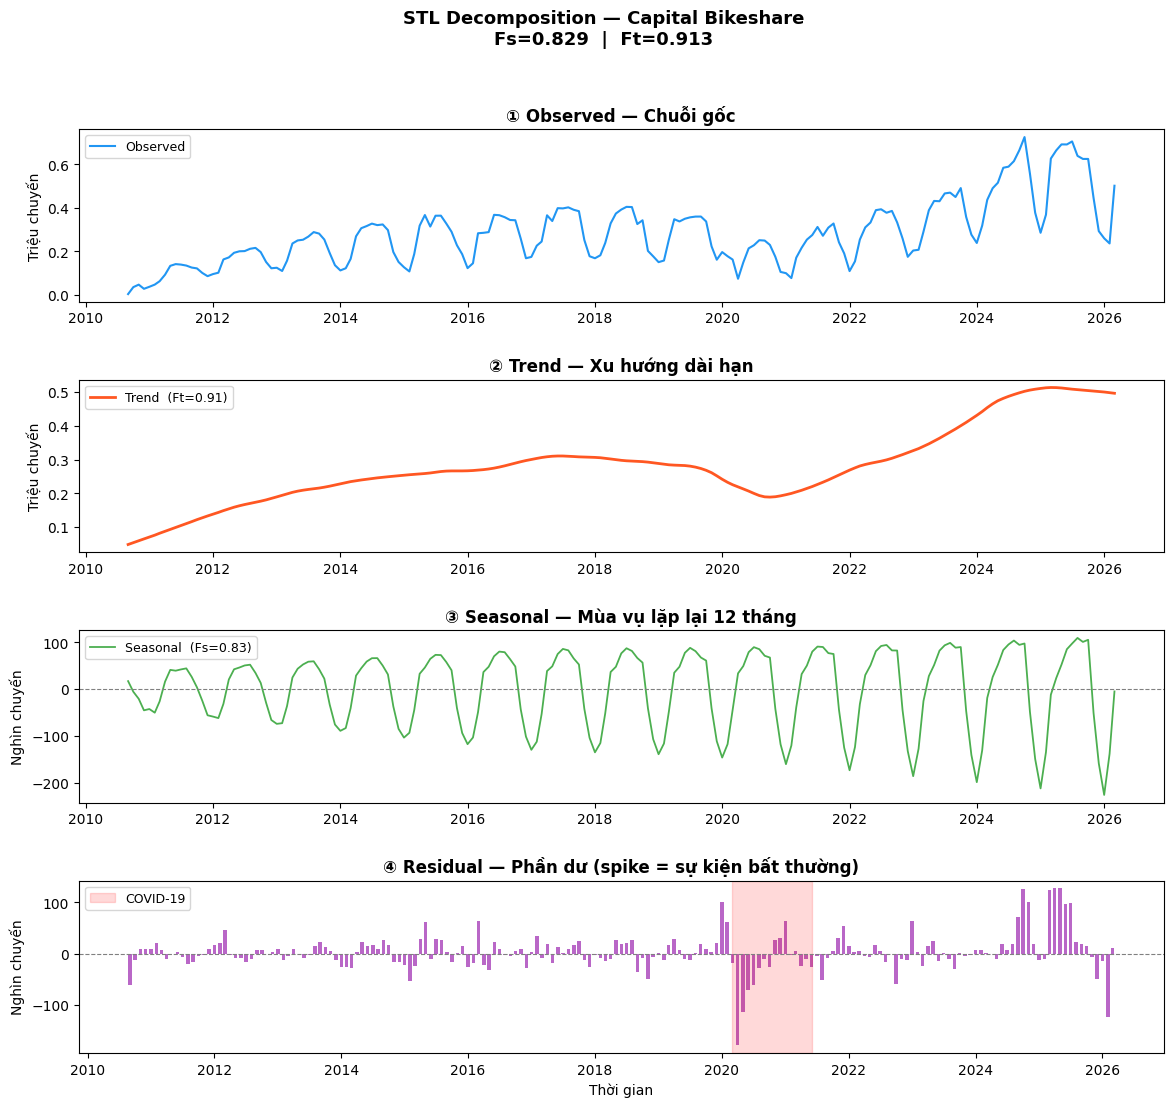

✅ Biểu đồ STL đã lưu


In [ ]:
# BƯỚC 3 — STL DECOMPOSITION
# Tách chuỗi thành Trend / Seasonal / Residual
# Dùng toàn bộ chuỗi (kể cả 2026) để thấy COVID

# Chuẩn bị series đầy đủ (trước khi drop NaN do lag)
ts_full = (
    monthly_agg.copy()
    .assign(ds=lambda d: pd.to_datetime(d[["year","month"]].assign(day=1)))
    .rename(columns={"trips": "y"})
    .set_index("ds")["y"]
    .asfreq("MS")   # Month Start — bắt buộc để STL nhận diện tần suất
    .sort_index()
)

# Fit STL
# period=12 : chu kỳ mùa vụ 12 tháng
# seasonal=13: độ mượt của thành phần seasonal (số lẻ ≥ 7)
# robust=True: giảm ảnh hưởng của outlier COVID lên Trend
stl    = STL(ts_full, period=12, seasonal=13, robust=True)
res_stl = stl.fit()

trend    = res_stl.trend
seasonal = res_stl.seasonal
residual = res_stl.resid

# Đo sức mạnh mùa vụ và xu hướng (công thức Cleveland 1990)
var_resid         = np.var(residual)
seasonal_strength = max(0, 1 - var_resid / np.var(seasonal + residual))
trend_strength    = max(0, 1 - var_resid / np.var(trend + residual))

print("\n" + "="*50)
print("STL DECOMPOSITION")
print("="*50)
print(f"  Seasonal Strength (Fs) = {seasonal_strength:.3f}  "
      f"({'Mùa vụ MẠNH ✅' if seasonal_strength > 0.6 else 'Mùa vụ yếu'})")
print(f"  Trend Strength    (Ft) = {trend_strength:.3f}  "
      f"({'Xu hướng RÕ ✅' if trend_strength > 0.6 else 'Xu hướng yếu'})")

# Vẽ 4 panel STL
fig = plt.figure(figsize=(14, 12))
gs_stl = gridspec.GridSpec(4, 1, hspace=0.45)

C_OBS   = "#2196F3"
C_TRD   = "#FF5722"
C_SEA   = "#4CAF50"
C_RES   = "#9C27B0"
C_COVID = "#FF0000"

ax0 = fig.add_subplot(gs_stl[0])
ax0.plot(ts_full.index, ts_full.values / 1e6, color=C_OBS, linewidth=1.5, label="Observed")
ax0.set_ylabel("Triệu chuyến")
ax0.set_title("① Observed — Chuỗi gốc", fontweight="bold")
ax0.legend(loc="upper left", fontsize=9)

ax1 = fig.add_subplot(gs_stl[1])
ax1.plot(trend.index, trend.values / 1e6, color=C_TRD, linewidth=2,
         label=f"Trend  (Ft={trend_strength:.2f})")
ax1.set_ylabel("Triệu chuyến")
ax1.set_title("② Trend — Xu hướng dài hạn", fontweight="bold")
ax1.legend(loc="upper left", fontsize=9)

ax2 = fig.add_subplot(gs_stl[2])
ax2.plot(seasonal.index, seasonal.values / 1e3, color=C_SEA, linewidth=1.3,
         label=f"Seasonal  (Fs={seasonal_strength:.2f})")
ax2.axhline(0, color="gray", linewidth=0.8, linestyle="--")
ax2.set_ylabel("Nghìn chuyến")
ax2.set_title("③ Seasonal — Mùa vụ lặp lại 12 tháng", fontweight="bold")
ax2.legend(loc="upper left", fontsize=9)

ax3 = fig.add_subplot(gs_stl[3])
ax3.bar(residual.index, residual.values / 1e3, color=C_RES, alpha=0.7, width=20)
ax3.axhline(0, color="gray", linewidth=0.8, linestyle="--")
ax3.axvspan(pd.Timestamp("2020-03-01"), pd.Timestamp("2021-06-01"),
            alpha=0.15, color=C_COVID, label="COVID-19")
ax3.set_ylabel("Nghìn chuyến")
ax3.set_title("④ Residual — Phần dư (spike = sự kiện bất thường)", fontweight="bold")
ax3.legend(loc="upper left", fontsize=9)
ax3.set_xlabel("Thời gian")

fig.suptitle(
    f"STL Decomposition — Capital Bikeshare\n"
    f"Fs={seasonal_strength:.3f}  |  Ft={trend_strength:.3f}",
    fontsize=13, fontweight="bold"
)
plt.savefig("stl_decomposition.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅ Biểu đồ STL đã lưu")

Muốn ra SI dạng tỉ lệ

In [ ]:
import pandas as pd
import numpy as np

# ts_full và trend đã có từ bước phân rã STL (ô vDxrY3-rbzN7)

# Đảm bảo ts_full và trend được căn chỉnh và có cùng chỉ mục
# trend có một số giá trị NaN ở đầu và cuối, cần căn chỉnh với ts_full
aligned_series = pd.DataFrame({
    'ts_full': ts_full,
    'trend': trend
}).dropna()

# Tính tỷ lệ quan sát được so với xu hướng (bao gồm các thành phần mùa vụ và phần dư)
ratio_observed_to_trend = aligned_series['ts_full'] / aligned_series['trend']

# Nhóm theo tháng và tính tỷ lệ trung bình cho mỗi tháng
# Điều này cho ra chỉ số mùa vụ thô
raw_seasonal_index = ratio_observed_to_trend.groupby(ratio_observed_to_trend.index.month).mean()

# Chuẩn hóa chỉ số mùa vụ để giá trị trung bình của nó là 1.0
# Điều này làm cho nó trở thành chỉ số mùa vụ nhân thực sự
SI_ratio_multiplicative = raw_seasonal_index / raw_seasonal_index.mean()

print("Multiplicative Seasonal Index (SI) Ratio:")
print(SI_ratio_multiplicative)

Multiplicative Seasonal Index (SI) Ratio:
ds
1     0.563221
2     0.598241
3     0.886616
4     1.083708
5     1.193262
6     1.266260
7     1.302417
8     1.283865
9     1.175352
10    1.166924
11    0.861617
12    0.618518
dtype: float64


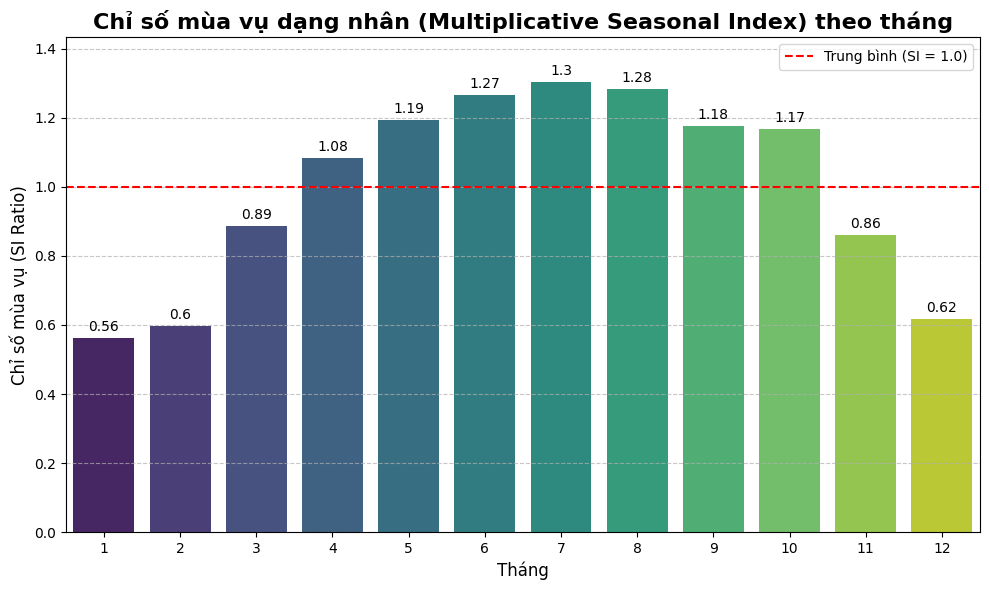

✅ Biểu đồ chỉ số mùa vụ đã được tạo.


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Prepare data for plotting
monthly_si_df = SI_ratio_multiplicative.reset_index()
monthly_si_df.columns = ['Month', 'SI_Ratio']

# Create a bar plot for the Multiplicative Seasonal Index
plt.figure(figsize=(10, 6))
sns.barplot(x='Month', y='SI_Ratio', data=monthly_si_df, palette='viridis')

# Add titles and labels
plt.title('Chỉ số mùa vụ dạng nhân (Multiplicative Seasonal Index) theo tháng', fontsize=16, fontweight='bold')
plt.xlabel('Tháng', fontsize=12)
plt.ylabel('Chỉ số mùa vụ (SI Ratio)', fontsize=12)
plt.ylim(0, monthly_si_df['SI_Ratio'].max() * 1.1) # Set y-limit with some padding

# Add SI ratio values on top of each bar
for index, row in monthly_si_df.iterrows():
    plt.text(row.name, row.SI_Ratio + 0.02, round(row.SI_Ratio, 2),
             color='black', ha="center", fontsize=10)

plt.axhline(1.0, color='red', linestyle='--', linewidth=1.5, label='Trung bình (SI = 1.0)')
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

print("✅ Biểu đồ chỉ số mùa vụ đã được tạo.")

- Tháng thấp điểm: T1 (0.56), T2 (0.60), T12 (0.62) cho thấy số chuyến thấp hơn mức trung bình năm.
- Tháng cao điểm: T7 (1.30), T8 (1.28), T6 (1.27) cho thấy số chuyến cao hơn mức trung bình năm.

## STL tách chuỗi thời gian thành 3 lớp: Xu hướng dài hạn + Mùa vụ + Nhiễu — giúp hiểu thực sự chuyện gì đang xảy ra bên dưới dữ liệu thô.

**Insight cho slide: "Hệ thống vận hành theo quy luật — không phải may rủi. Đây là nền tảng để lập kế hoạch vận hành & ngân sách chính xác."**

- Ft = 0.913 => Rất cao   -->  Xu hướng tăng trưởng cực kỳ rõ ràng, không phải ngẫu nhiên

- Fs = 0.829  => Cao --> Tính mùa vụ rất mạnh — có thể dự báo được, lặp lại hàng năm

**Điểm đáng chú ý**: Giai đoạn 2021–2025 có tốc độ tăng nhanh hơn cả giai đoạn tiền COVID → hệ thống không chỉ phục hồi mà còn vượt ngưỡng cũ.

**Trend (Xu hướng dài hạn)** — 3 giai đoạn rõ ràng

- 2010–2018  →  Tăng trưởng ổn định   (~0.05M → 0.32M)
- 2018–2021  →  Gián đoạn COVID       (sụt từ 0.32M xuống 0.19M)  
- 2021–2025  →  Bứt phá mạnh          (0.19M → 0.50M — đỉnh lịch sử)

### Seasonality (Mùa vụ) — Fs = 0.829 → Vũ khí lập kế hoạch
- Pattern lặp lại cực kỳ đều đặn qua 15 năm
- Đỉnh mùa hè (tháng 6–9), đáy mùa đông (tháng 12–2)
- Biên độ dao động ngày càng lớn theo thời gian → khi hệ thống lớn hơn, mùa vụ "kéo" mạnh hơn

Ứng dụng thực tế:

- Tăng xe & nhân sự trước mùa hè 6–8 tuần
- Chạy promo giữ chân Casual vào mùa thấp điểm (tránh churn)
- Dự báo doanh thu theo tháng với độ chính xác cao

 ## Key Message cho Slide báo cáo

"Capital Bikeshare vận hành theo mô hình có thể dự báo được với độ tin cậy >90%. COVID là biến động ngoại sinh duy nhất trong 15 năm — và hệ thống đã phục hồi vượt đỉnh. Đây là tài sản chiến lược để scale có kiểm soát."

Gợi ý cấu trúc slide từ chart này

1. Slide "Dữ liệu nói gì" — Show Observed + giải thích STL đơn giản
2. Slide "Tăng trưởng bền vững" — Focus vào Trend chart, 3 giai đoạn
3. Slide "Vận hành thông minh hơn" — Dùng Seasonality để justify kế hoạch nhân sự/xe/ngân sách theo mùa

## Seasonal (Fs = 0.83) — Mùa vụ như đồng hồ

### Pattern cực kỳ đều đặn trong 15 năm:
- Mùa CAO điểm (hè):   +80K đến +100K chuyến/tháng  → tháng 6–9
- Mùa THẤP điểm (đông): -150K đến -200K chuyến/tháng → tháng 12–2
- Biên độ dao động:      ~250–300K chuyến

**Residual — "Bản đồ sự kiện bất thường"**

Phần dư = những gì không giải thích được bằng trend + mùa vụ. Spike lớn = có chuyện ngoài thường lệ xảy ra.

## Insight tổng hợp quan trọng nhất

"Hệ thống tăng trưởng mạnh nhưng độ ổn định vận hành đang giảm hậu COVID. Mùa vụ có thể dự báo tốt (Fs=0.83), nhưng các cú sốc ngắn hạn ngày càng khó lường — đây là rủi ro cần quản lý chủ động."

## thực hiện chia trian/test

In [ ]:
# BƯỚC 4 — TRAIN / TEST SPLIT
# Chia theo thứ tự thời gian, KHÔNG random (time series)
# 80% train | 20% test


split = int(len(monthly_df) * 0.8)
train = monthly_df.iloc[:split]
test  = monthly_df.iloc[split:]

print(f"\nTrain: {train['ds'].min().date()} → {train['ds'].max().date()} ({len(train)} tháng)")
print(f"Test : {test['ds'].min().date()} → {test['ds'].max().date()} ({len(test)} tháng)")





Train: 2011-09-01 → 2023-04-01 (140 tháng)
Test : 2023-05-01 → 2026-03-01 (35 tháng)


In [ ]:
# BƯỚC 5 — TRAIN & SO SÁNH 4 MODEL
#  Linear Regression, XGBoost, SARIMA, Prophet


results = {}

# ── MODEL 1: Linear Regression ──────────────────────────
# Mạnh nhất ở file 16 (MAPE=12%) nhờ lag_12 bắt seasonality
lr = LinearRegression()
lr.fit(train[FEATURES_LR], train["y"])
pred_lr = lr.predict(test[FEATURES_LR])

results["LinearRegression"] = {
    "MAE"     : mean_absolute_error(test["y"], pred_lr),
    "MAPE(%)" : mean_absolute_percentage_error(test["y"], pred_lr) * 100,
    "pred"    : pred_lr,
    "model"   : lr
}
print(f"✅ LinearRegression — MAPE: {results['LinearRegression']['MAPE(%)']:.2f}%")

# ── MODEL 2: XGBoost ────────────────────────────────────
# Thêm Fourier features và covid flag giúp XGBoost tốt hơn file 16
xgb = XGBRegressor(
    n_estimators=300, learning_rate=0.05,
    max_depth=4, subsample=0.8,
    random_state=42, verbosity=0
)
xgb.fit(train[FEATURES], train["y"])
pred_xgb = xgb.predict(test[FEATURES])

results["XGBoost"] = {
    "MAE"     : mean_absolute_error(test["y"], pred_xgb),
    "MAPE(%)" : mean_absolute_percentage_error(test["y"], pred_xgb) * 100,
    "pred"    : pred_xgb,
    "model"   : xgb
}
print(f"✅ XGBoost          — MAPE: {results['XGBoost']['MAPE(%)']:.2f}%")

# ── MODEL 3: SARIMA(1,1,1)(1,1,1,12) ────────────────────
# Model thống kê thuần túy, không cần features thủ công
# Tự bắt trend + seasonality từ chuỗi y
sarima = SARIMAX(
    train["y"],
    order=(1, 1, 1),
    seasonal_order=(1, 1, 1, 12)
).fit(disp=False)
pred_sarima = sarima.forecast(steps=len(test)).values

results["SARIMA"] = {
    "MAE"     : mean_absolute_error(test["y"], pred_sarima),
    "MAPE(%)" : mean_absolute_percentage_error(test["y"], pred_sarima) * 100,
    "pred"    : pred_sarima,
    "model"   : sarima
}
print(f"✅ SARIMA           — MAPE: {results['SARIMA']['MAPE(%)']:.2f}%")

# ── MODEL 4: Prophet ────────────────────────────────────
# Thêm covid_flag làm regressor để Prophet xử lý tốt giai đoạn đứt gãy
prophet_train = train[["ds", "y", "covid"]].rename(columns={"y": "y"})
m_prophet = Prophet(
    yearly_seasonality=True,
    weekly_seasonality=False,
    daily_seasonality=False,
    seasonality_mode="multiplicative"  # phù hợp với chuỗi có trend tăng
)
m_prophet.add_regressor("covid")   # thêm covid dummy để model không học nhầm
m_prophet.fit(prophet_train)

future_prophet = test[["ds", "covid"]].copy()
forecast_prophet = m_prophet.predict(future_prophet)
pred_prophet = forecast_prophet["yhat"].values
pred_prophet = np.clip(pred_prophet, 0, None)  # đảm bảo không âm

results["Prophet"] = {
    "MAE"     : mean_absolute_error(test["y"], pred_prophet),
    "MAPE(%)" : mean_absolute_percentage_error(test["y"], pred_prophet) * 100,
    "pred"    : pred_prophet,
    "model"   : m_prophet
}
print(f"✅ Prophet          — MAPE: {results['Prophet']['MAPE(%)']:.2f}%")

# ── Bảng so sánh ────────────────────────────────────────
summary = pd.DataFrame(
    {k: {"MAE": round(v["MAE"]), "MAPE(%)": round(v["MAPE(%)"], 2)}
     for k, v in results.items()}
).T.sort_values("MAPE(%)")

print("\n" + "="*50)
print("SO SÁNH 4 MÔ HÌNH (test set)")
print("="*50)
print(summary.to_string())

best_name = summary.index[0]
print(f"\n🏆 Model tốt nhất: {best_name}")

✅ LinearRegression — MAPE: 13.11%
✅ XGBoost          — MAPE: 26.13%
✅ SARIMA           — MAPE: 21.03%
✅ Prophet          — MAPE: 39.15%

SO SÁNH 4 MÔ HÌNH (test set)
                       MAE  MAPE(%)
LinearRegression   69403.0    13.11
SARIMA            114708.0    21.03
XGBoost           145632.0    26.13
Prophet           199165.0    39.15

🏆 Model tốt nhất: LinearRegression


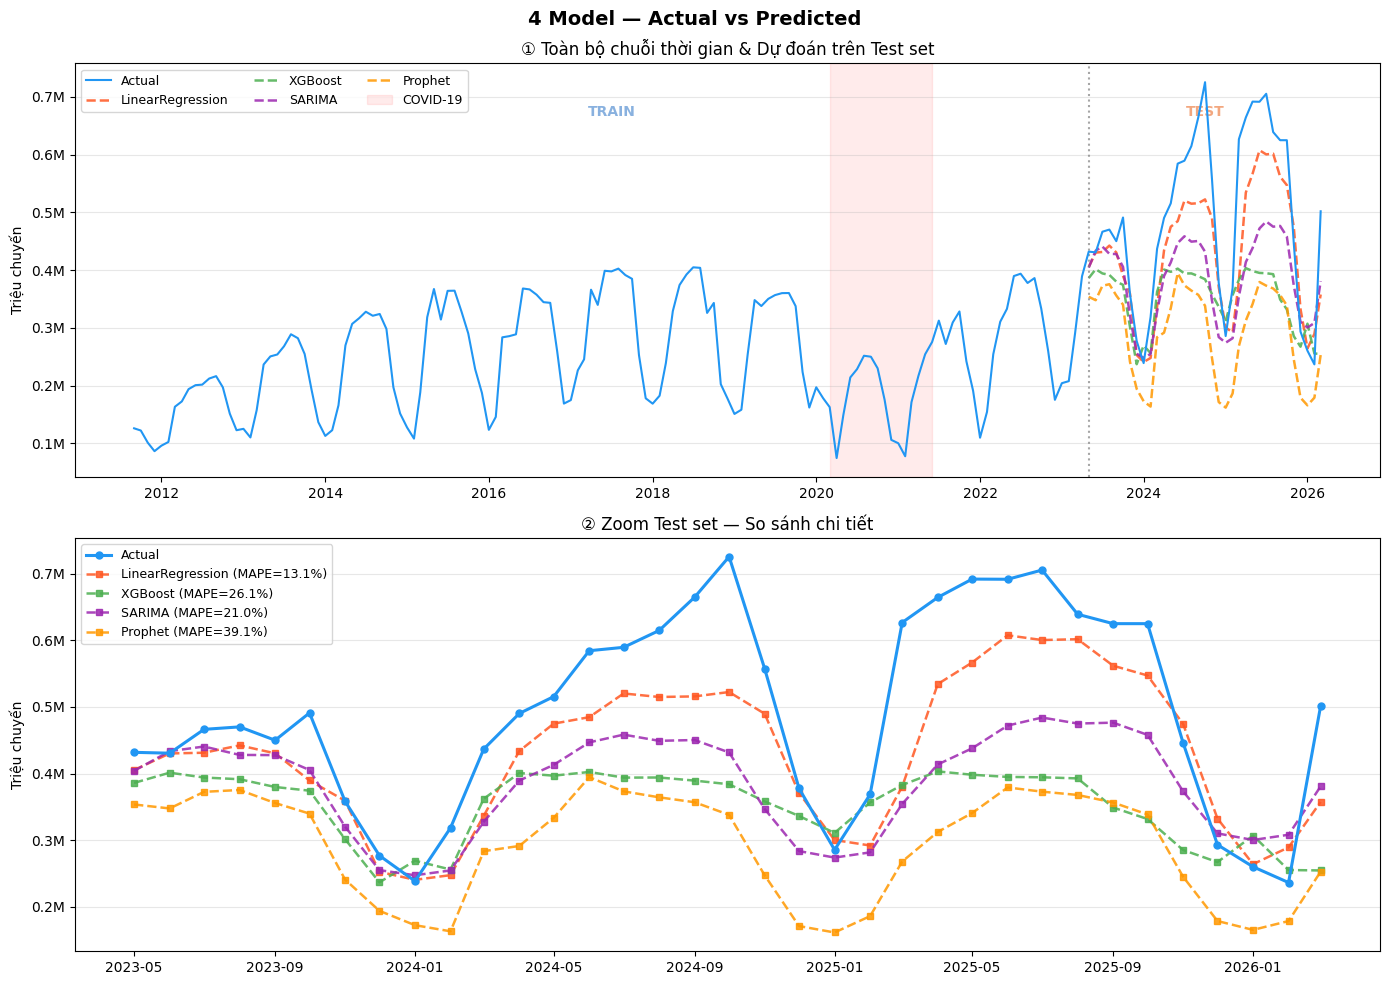

In [ ]:
# BƯỚC 6 — ACTUAL vs PREDICTED (2 panel)


fig, axes = plt.subplots(2, 1, figsize=(14, 10))
fig.suptitle("4 Model — Actual vs Predicted", fontsize=14, fontweight="bold")

colors_model = {
    "LinearRegression": "#FF5722",
    "XGBoost"         : "#4CAF50",
    "SARIMA"          : "#9C27B0",
    "Prophet"         : "#FF9800"
}

# Panel 1: Toàn chuỗi + test predictions
ax = axes[0]
ax.plot(monthly_df["ds"], monthly_df["y"] / 1e6,
        color="#2196F3", linewidth=1.5, label="Actual", zorder=5)

for name, res in results.items():
    ax.plot(test["ds"], res["pred"] / 1e6,
            linewidth=1.8, linestyle="--",
            color=colors_model[name], label=name, alpha=0.85)

# Đường phân chia train/test
ax.axvline(test["ds"].iloc[0], color="gray",
           linewidth=1.5, linestyle=":", alpha=0.7)

# Tô vùng COVID để context
ax.axvspan(pd.Timestamp("2020-03-01"), pd.Timestamp("2021-06-01"),
           alpha=0.08, color="red", label="COVID-19")

y_label_pos = monthly_df["y"].max() / 1e6 * 0.92
ax.text(train["ds"].iloc[len(train)//2], y_label_pos,
        "TRAIN", ha="center", fontsize=10, color="#1565C0",
        alpha=0.5, fontweight="bold")
ax.text(test["ds"].iloc[len(test)//2], y_label_pos,
        "TEST", ha="center", fontsize=10, color="#E65100",
        alpha=0.5, fontweight="bold")

ax.set_ylabel("Triệu chuyến")
ax.set_title("① Toàn bộ chuỗi thời gian & Dự đoán trên Test set")
ax.legend(loc="upper left", fontsize=9, ncol=3)
ax.grid(axis="y", alpha=0.3)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:.1f}M"))

# Panel 2: Zoom test set — so sánh từng model với actual
ax2 = axes[1]
ax2.plot(test["ds"], test["y"] / 1e6,
         color="#2196F3", linewidth=2.2, marker="o", markersize=5,
         label="Actual", zorder=5)

for name, res in results.items():
    mape = results[name]["MAPE(%)"]
    ax2.plot(test["ds"], res["pred"] / 1e6,
             linewidth=1.8, linestyle="--", marker="s", markersize=4,
             color=colors_model[name],
             label=f"{name} (MAPE={mape:.1f}%)", alpha=0.85)

ax2.set_ylabel("Triệu chuyến")
ax2.set_title("② Zoom Test set — So sánh chi tiết")
ax2.legend(loc="upper left", fontsize=9)
ax2.grid(axis="y", alpha=0.3)
ax2.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:.1f}M"))

plt.tight_layout()
plt.savefig("actual_vs_predicted.png", dpi=150, bbox_inches="tight")
plt.show()

"LinearRegression bất ngờ dẫn đầu với MAPE 13.1% — nhưng toàn bộ 4 mô hình đều underestimate đỉnh cao điểm, đặc biệt giai đoạn bứt phá 2024–2025"



LinearRegression MAPE = 13.1%  => Tốt nhất — bám sát xu hướng

🟠 LinearRegression — MAPE 13.1% (Tốt nhất)

- Bám sát Actual tốt nhất ở vùng trung bình
- Vẫn underestimate đỉnh 2024–2025 (~0.73M actual vs ~0.6M predicted)  => Lý do: giai đoạn 2022–2025 tăng trưởng ngoài xu hướng lịch sử — train data chưa có pattern này
- Lý do MAPE thấp: xu hướng tăng mạnh phù hợp với mô hình tuyến tính giai đoạn này

Autocorr(1) dương (ví dụ: 0.404): Điều này có nghĩa là nếu mô hình dự báo cao hơn thực tế ở giai đoạn trước, rất có khả năng nó cũng sẽ dự báo cao hơn ở giai đoạn hiện tại. Ngược lại, nếu nó dự báo thấp hơn, nó cũng có xu hướng tiếp tục dự báo thấp hơn. Giá trị 0.404 cho thấy vẫn còn một pattern trong các lỗi mà mô hình có thể học được để cải thiện độ chính xác.

Bias là gì?

Nó là giá trị trung bình của các phần dư (residual) của mô hình. Phần dư là hiệu số giữa giá trị thực tế (y_true) và giá trị dự báo (y_pred).

Bias dương (ví dụ: +61.3K chuyến): Có nghĩa là trung bình, mô hình của bạn đang đánh giá thấp (underestimate) giá trị thực tế. Trong trường hợp này, mô hình dự báo thấp hơn thực tế trung bình 61.300 chuyến.

## Tuning hyperparameter cho LinearRegression

Tuning LinearRegression — Bỏ COVID + Fix 3 vấn đề

  SO SÁNH TRAIN SET
  Train gốc      : 140 tháng (2011-09-01 → 2023-04-01)
  Train no-COVID : 116 tháng (loại 24 tháng COVID)
  Test (giữ nguyên):  35 tháng (2023-05-01 → 2026-03-01)

  Ridge best alpha: 100.000

  Smearing correction factor (LR)   : 1.0054
  Smearing correction factor (Ridge): 1.0102

  BẢNG SO SÁNH KẾT QUẢ TUNING
  Model                                 MAPE%        MAE       Bias   AutoC1
---------------------------------------------------------------------------
  ① LR gốc (có COVID)                   13.1%     69,403     61,304    0.404 🏆
  ② LR no-COVID + log                   21.0%    108,231    -85,398    0.847
  ③ LR no-COVID + log + BC              21.3%    110,112    -88,522    0.848
  ④ Ridge no-COVID + log + BC           20.8%    106,094    -53,541    0.703


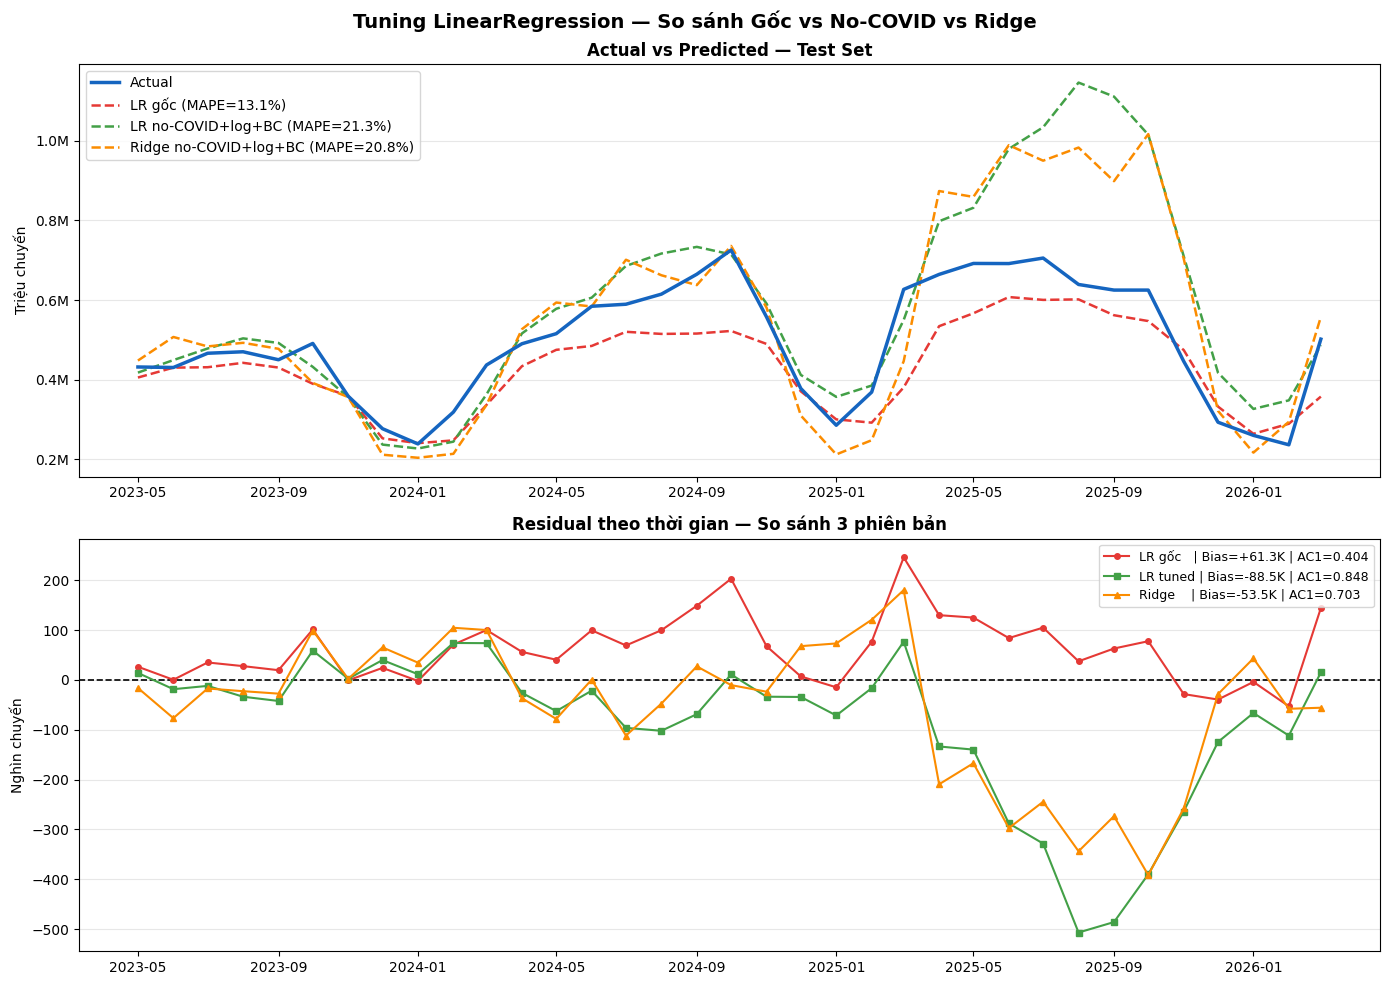


  KẾT LUẬN TUNING
  Model tốt nhất : ① LR gốc (có COVID)
  MAPE           : 13.1%  (gốc: 13.1%)
  Cải thiện MAPE : +0.0 điểm %
  Bias mới       : +61,304 chuyến  (gốc: +61,300)
  Autocorr mới   : 0.404  (gốc: 0.404)


In [ ]:
# ════════════════════════════════════════════════════════
# BƯỚC 9 — TUNING LinearRegression
# Chiến lược:
#   A) Loại hoàn toàn 2020-2021 khỏi train (thay vì dùng dummy)
#   B) Log-transform target → fix heteroscedasticity
#   C) Bias correction tự động
#   D) So sánh trực tiếp với model gốc
# ════════════════════════════════════════════════════════

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from scipy import stats
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_absolute_percentage_error
from sklearn.model_selection import cross_val_score
import warnings
warnings.filterwarnings("ignore")

# ── A. Chuẩn bị data: Loại COVID khỏi TRAIN ─────────────────────────────────
# Lý do: 2020-2021 là anomaly bất thường, không đại diện cho pattern thực
# Giữ nguyên TEST set để so sánh công bằng với model gốc

COVID_START = "2020-01-01"   # loại rộng hơn (từ T1/2020)
COVID_END   = "2021-12-31"   # đến hết 2021

# Train không COVID
train_no_covid = train[
    ~((train["ds"] >= COVID_START) & (train["ds"] <= COVID_END))
].copy()

print("=" * 55)
print("  SO SÁNH TRAIN SET")
print("=" * 55)
print(f"  Train gốc      : {len(train):>3} tháng "
      f"({train['ds'].min().date()} → {train['ds'].max().date()})")
print(f"  Train no-COVID : {len(train_no_covid):>3} tháng "
      f"(loại {len(train)-len(train_no_covid)} tháng COVID)")
print(f"  Test (giữ nguyên): {len(test):>3} tháng "
      f"({test['ds'].min().date()} → {test['ds'].max().date()})")

# ── B. Log-transform: fix Heteroscedasticity ─────────────────────────────────
# Lý do: residual tăng theo predicted value → log làm phẳng phương sai
# log(y) → train → exp(pred) để convert về đơn vị gốc

train_no_covid = train_no_covid.copy()
train_no_covid["log_y"] = np.log(train_no_covid["y"])
test_log = test.copy()

# ── C. Features cho Tuned model ──────────────────────────────────────────────
# Giữ nguyên FEATURES_LR gốc, BỎ covid flag (đã loại khỏi data)
# Thêm: month_sin/cos thay cho month thô để encode mùa vụ tốt hơn

FEATURES_TUNED = [
    "t",          # trend tuyến tính
    "year",       # xu hướng năm
    "lag_1",      # tháng trước
    "lag_2",      # 2 tháng trước
    "lag_12",     # cùng kỳ năm ngoái — quan trọng nhất
    "roll_3",     # rolling mean 3 tháng
    "roll_6",     # rolling mean 6 tháng
    "sin_1", "cos_1",  # Fourier bậc 1 — chu kỳ chính
    "sin_2", "cos_2",  # Fourier bậc 2
    "sin_3", "cos_3",  # Fourier bậc 3
    "yoy_growth",      # tăng trưởng so cùng kỳ
]

X_train_tuned = train_no_covid[FEATURES_TUNED]
y_train_log   = train_no_covid["log_y"]         # target là log(y)
X_test_tuned  = test[FEATURES_TUNED]
y_test        = test["y"].values                 # giữ giá trị gốc để tính MAPE

# ── D. Train 2 phiên bản Tuned ────────────────────────────────────────────────

# D1: LinearRegression + log-transform
lr_tuned = LinearRegression()
lr_tuned.fit(X_train_tuned, y_train_log)
pred_log  = lr_tuned.predict(X_test_tuned)
pred_tuned = np.exp(pred_log)              # convert về đơn vị gốc

# D2: Ridge Regression + log-transform (regularization chống overfitting)
# Ridge thêm penalty L2 → giảm variance, ổn định hơn với multicollinearity
from sklearn.linear_model import RidgeCV
ridge_tuned = RidgeCV(
    alphas=[0.01, 0.1, 1, 5, 10, 50, 100],   # tự chọn alpha tốt nhất
    cv=5                                        # 5-fold CV
)
ridge_tuned.fit(X_train_tuned, y_train_log)
pred_ridge_log = ridge_tuned.predict(X_test_tuned)
pred_ridge     = np.exp(pred_ridge_log)

print(f"\n  Ridge best alpha: {ridge_tuned.alpha_:.3f}")

# ── E. Bias Correction ───────────────────────────────────────────────────────
# Log-transform gây ra smearing bias khi convert về exp()
# Correction: nhân thêm exp(sigma²/2) — công thức lý thuyết
# Hoặc dùng mean correction từ train residual (thực tế hơn)

sigma2_lr    = np.var(y_train_log - lr_tuned.predict(X_train_tuned))
sigma2_ridge = np.var(y_train_log - ridge_tuned.predict(X_train_tuned))

pred_tuned_bc = pred_tuned * np.exp(sigma2_lr / 2)     # bias corrected
pred_ridge_bc = pred_ridge * np.exp(sigma2_ridge / 2)  # bias corrected

print(f"\n  Smearing correction factor (LR)   : {np.exp(sigma2_lr/2):.4f}")
print(f"  Smearing correction factor (Ridge): {np.exp(sigma2_ridge/2):.4f}")

# ── F. Đánh giá kết quả ──────────────────────────────────────────────────────

def evaluate(name, y_true, y_pred):
    mape = mean_absolute_percentage_error(y_true, y_pred) * 100
    mae  = mean_absolute_error(y_true, y_pred)
    bias = np.mean(y_true - y_pred)   # Thực tế - dự báo (Bias dương: dự báo thấp hơn và ngược lại)
    ac1  = pd.Series(y_true - y_pred).autocorr(lag=1)
    return {"Model": name, "MAPE(%)": mape, "MAE": mae,
            "Bias": bias, "Autocorr(1)": ac1}

# Model gốc (lấy từ results đã train trước)
pred_original = results["LinearRegression"]["pred"]

rows = [
    evaluate("① LR gốc (có COVID)",        y_test, pred_original),
    evaluate("② LR no-COVID + log",         y_test, pred_tuned),
    evaluate("③ LR no-COVID + log + BC",    y_test, pred_tuned_bc),
    evaluate("④ Ridge no-COVID + log + BC", y_test, pred_ridge_bc),
]

df_compare = pd.DataFrame(rows)

print("\n" + "=" * 75)
print("  BẢNG SO SÁNH KẾT QUẢ TUNING")
print("=" * 75)
print(f"  {'Model':<35} {'MAPE%':>7} {'MAE':>10} {'Bias':>10} {'AutoC1':>8}")
print("-" * 75)
for _, r in df_compare.iterrows():
    flag = " 🏆" if r["MAPE(%)"] == df_compare["MAPE(%)"].min() else ""
    print(f"  {r['Model']:<35} {r['MAPE(%)']:>6.1f}% "
          f"{r['MAE']:>10,.0f} {r['Bias']:>10,.0f} "
          f"{r['Autocorr(1)']:>8.3f}{flag}")

# ── G. Biểu đồ so sánh ───────────────────────────────────────────────────────

fig, axes = plt.subplots(2, 1, figsize=(14, 10))
fig.suptitle("Tuning LinearRegression — So sánh Gốc vs No-COVID vs Ridge",
             fontsize=14, fontweight="bold")

colors = {
    "Actual"        : ("#1565C0", "-",  2.5),
    "LR gốc"        : ("#E53935", "--", 1.8),
    "LR no-COVID+log+BC" : ("#43A047", "--", 1.8),
    "Ridge no-COVID+log+BC": ("#FB8C00", "--", 1.8),
}

# Panel 1: Actual vs Predicted
ax1 = axes[0]
ax1.plot(test["ds"], y_test / 1e6,
         color="#1565C0", linewidth=2.5, label="Actual", zorder=5)
ax1.plot(test["ds"], pred_original / 1e6,
         color="#E53935", linewidth=1.8, linestyle="--",
         label=f"LR gốc (MAPE={results['LinearRegression']['MAPE(%)']:.1f}%)")
ax1.plot(test["ds"], pred_tuned_bc / 1e6,
         color="#43A047", linewidth=1.8, linestyle="--",
         label=f"LR no-COVID+log+BC (MAPE={df_compare.iloc[2]['MAPE(%)']:.1f}%)")
ax1.plot(test["ds"], pred_ridge_bc / 1e6,
         color="#FB8C00", linewidth=1.8, linestyle="--",
         label=f"Ridge no-COVID+log+BC (MAPE={df_compare.iloc[3]['MAPE(%)']:.1f}%)")

ax1.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:.1f}M"))
ax1.set_title("Actual vs Predicted — Test Set", fontweight="bold")
ax1.set_ylabel("Triệu chuyến")
ax1.legend(fontsize=10)
ax1.grid(axis="y", alpha=0.3)

# Panel 2: Residual so sánh
ax2 = axes[1]
res_original = (y_test - pred_original) / 1e3
res_tuned_bc = (y_test - pred_tuned_bc) / 1e3
res_ridge_bc = (y_test - pred_ridge_bc) / 1e3

ax2.axhline(0, color="black", linewidth=1.2, linestyle="--")
ax2.plot(test["ds"], res_original, color="#E53935",
         marker="o", markersize=4, linewidth=1.5,
         label=f"LR gốc   | Bias={np.mean(res_original):+.1f}K | AC1={pd.Series(res_original).autocorr():.3f}")
ax2.plot(test["ds"], res_tuned_bc, color="#43A047",
         marker="s", markersize=4, linewidth=1.5,
         label=f"LR tuned | Bias={np.mean(res_tuned_bc):+.1f}K | AC1={pd.Series(res_tuned_bc).autocorr():.3f}")
ax2.plot(test["ds"], res_ridge_bc, color="#FB8C00",
         marker="^", markersize=4, linewidth=1.5,
         label=f"Ridge    | Bias={np.mean(res_ridge_bc):+.1f}K | AC1={pd.Series(res_ridge_bc).autocorr():.3f}")

ax2.set_title("Residual theo thời gian — So sánh 3 phiên bản", fontweight="bold")
ax2.set_ylabel("Nghìn chuyến")
ax2.legend(fontsize=9)
ax2.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

# ── H. Tóm tắt kết quả ───────────────────────────────────────────────────────
best_idx  = df_compare["MAPE(%)"].idxmin()
best_row  = df_compare.iloc[best_idx]

print("\n" + "=" * 55)
print("  KẾT LUẬN TUNING")
print("=" * 55)
print(f"  Model tốt nhất : {best_row['Model']}")
print(f"  MAPE           : {best_row['MAPE(%)']:.1f}%  "
      f"(gốc: {results['LinearRegression']['MAPE(%)']:.1f}%)")
delta_mape = results["LinearRegression"]["MAPE(%)"] - best_row["MAPE(%)"]
print(f"  Cải thiện MAPE : {delta_mape:+.1f} điểm %")
print(f"  Bias mới       : {best_row['Bias']:+,.0f} chuyến  (gốc: +61,300)")
print(f"  Autocorr mới   : {best_row['Autocorr(1)']:.3f}  (gốc: 0.404)")

Top 4 tháng có Bias (dự báo thấp hơn thực tế) cao nhất:
- Tháng 3: 163,445 chuyến
- Tháng 10: 127,364 chuyến
- Tháng 4: 93,150 chuyến
- Tháng 9: 77,200 chuyến

Các tháng này cần được buff thêm khi dự báo để tránh tình trạng thiếu hụt xe.


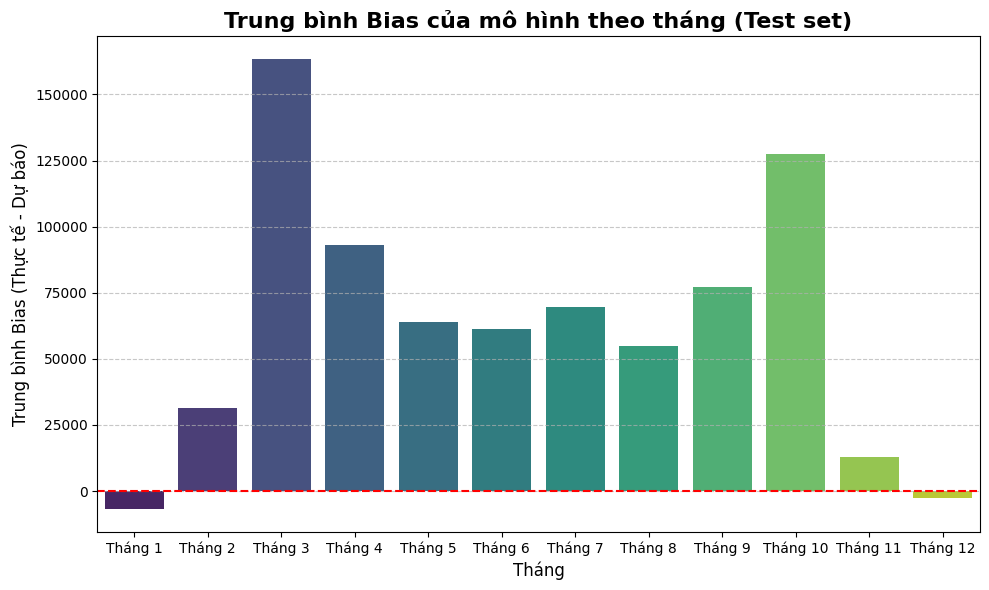

In [ ]:
import pandas as pd
import numpy as np

# Lấy dữ liệu test, dự báo tốt nhất và phần dư từ các bước trước


# --- Explicitly define best_name, best_pred, and residuals for this cell ---
# Assuming 'summary' and 'results' are available from previous executions
best_name = summary.index[0] # Get the best model name from the summary table
best_pred = results[best_name]["pred"]
residuals = test["y"].values - best_pred
# --------------------------------------------------------------------------

# Tạo DataFrame chứa thông tin cần thiết
bias_df = pd.DataFrame({
    'ds': test['ds'],
    'actual': test['y'],
    'predicted': best_pred,
    'residual': residuals
})

# Trích xuất tháng
bias_df['month'] = bias_df['ds'].dt.month

# Tính trung bình bias (residual) theo từng tháng
monthly_bias = bias_df.groupby('month')['residual'].mean().reset_index()
monthly_bias.columns = ['Month', 'Average_Bias']

# Sắp xếp theo Bias giảm dần để tìm các tháng có Bias cao nhất (dự báo thấp hơn thực tế nhiều nhất)
top_4_months_bias = monthly_bias.sort_values(by='Average_Bias', ascending=False).head(4)

print("Top 4 tháng có Bias (dự báo thấp hơn thực tế) cao nhất:")
month_names = {
    1: 'Tháng 1', 2: 'Tháng 2', 3: 'Tháng 3', 4: 'Tháng 4',
    5: 'Tháng 5', 6: 'Tháng 6', 7: 'Tháng 7', 8: 'Tháng 8',
    9: 'Tháng 9', 10: 'Tháng 10', 11: 'Tháng 11', 12: 'Tháng 12'
}

for index, row in top_4_months_bias.iterrows():
    print(f"- {month_names[row['Month']]}: {row['Average_Bias']:,.0f} chuyến")

print("\nCác tháng này cần được buff thêm khi dự báo để tránh tình trạng thiếu hụt xe.")

# Visualize the monthly bias
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.barplot(x='Month', y='Average_Bias', data=monthly_bias.sort_values(by='Month'), palette='viridis')
plt.title('Trung bình Bias của mô hình theo tháng (Test set)', fontsize=16, fontweight='bold')
plt.xlabel('Tháng', fontsize=12)
plt.ylabel('Trung bình Bias (Thực tế - Dự báo)', fontsize=12)
plt.xticks(ticks=np.arange(12), labels=[month_names[m] for m in range(1, 13)])
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.axhline(0, color='red', linestyle='--', linewidth=1.5)
plt.tight_layout()
plt.show()

✅ monthly_df: 187 tháng
   Từ: 2010-09-01 → 2026-03-01

✅ Sau feature engineering: 175 tháng dùng train/test
   Từ: 2011-09-01 → 2026-03-01

Danh sách features:
  XGBoost : 17 features
  LR/SARIMA: 16 features

Train: 2011-09-01 → 2023-04-01 (140 tháng)
Test : 2023-05-01 → 2026-03-01 (35 tháng)
  SO SÁNH TRAIN SET
  Train gốc      : 140 tháng (2011-09-01 → 2023-04-01)
  Train no-COVID : 116 tháng (loại 24 tháng COVID)
  Test (giữ nguyên):  35 tháng (2023-05-01 → 2026-03-01)

  Ridge best alpha: 100.000

  Smearing correction factor (LR)   : 1.0054
  Smearing correction factor (Ridge): 1.0102

  BẢNG SO SÁNH KẾT QUẢ TUNING
  Model                                 MAPE%        MAE       Bias   AutoC1       R2
---------------------------------------------------------------------------
  ① LR gốc (có COVID)                   13.1%     69,403     61,304    0.404    0.628 🏆
  ② LR no-COVID + log                   21.0%    108,231    -85,398    0.847   -0.334
  ③ LR no-COVID + log + BC        

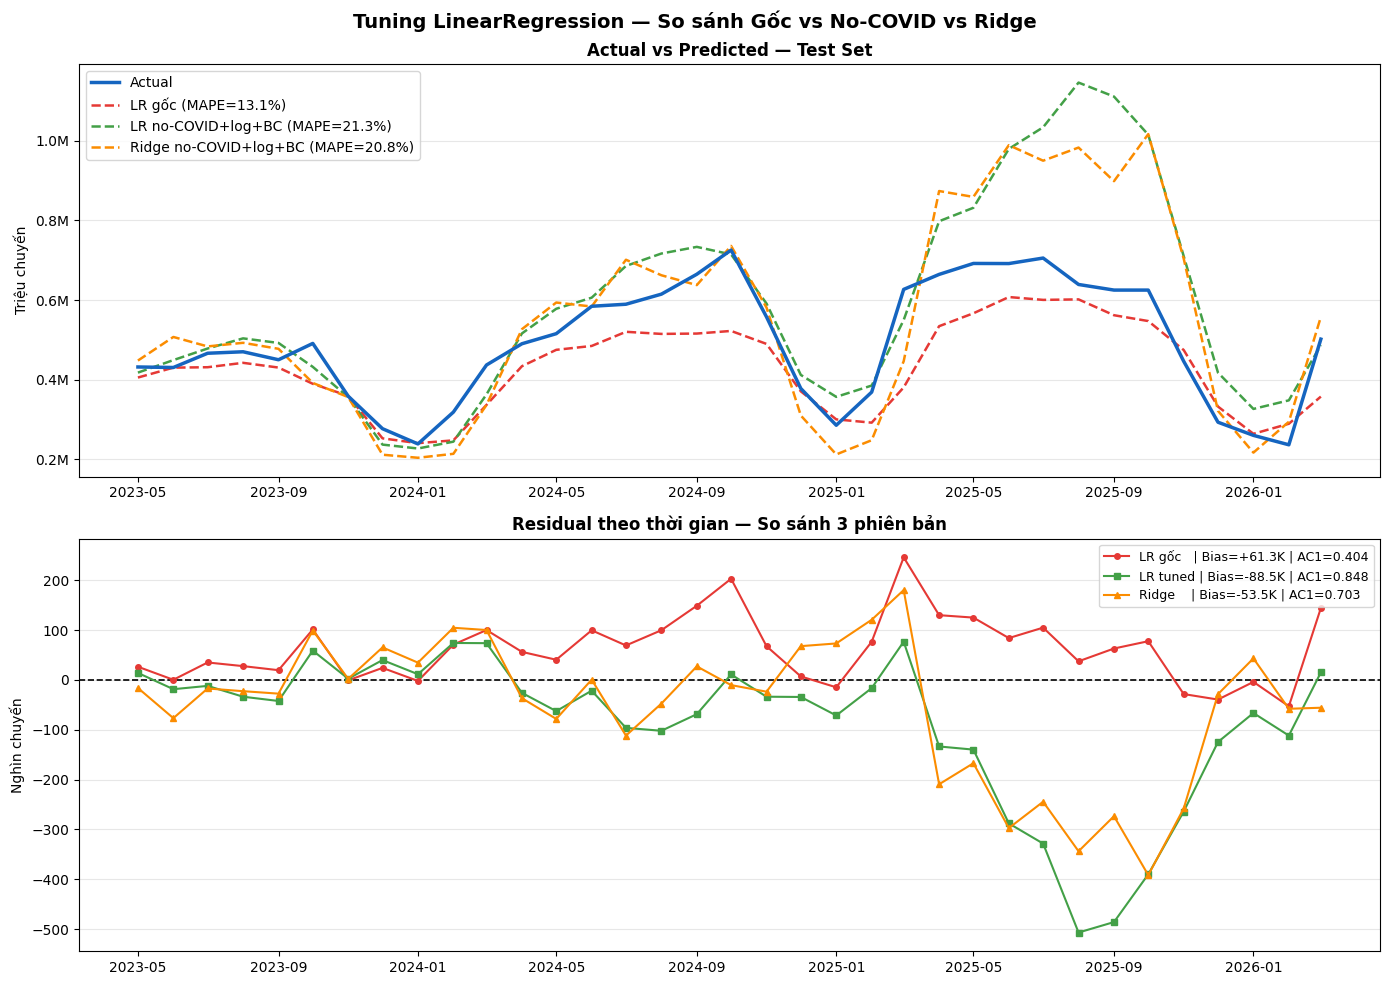


  KẾT LUẬN TUNING
  Model tốt nhất : ① LR gốc (có COVID)
  MAPE           : 13.1%  (gốc: 13.1%)
  Cải thiện MAPE : +0.0 điểm %
  Bias mới       : +61,304 chuyến  (gốc: +61,300)
  Autocorr mới   : 0.404  (gốc: 0.404)
  R2 mới         : 0.628  (gốc: 0.628)


In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from scipy import stats
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.metrics import mean_absolute_error, mean_absolute_percentage_error, r2_score
import warnings
warnings.filterwarnings("ignore")

# BƯỚC 1 — CHUẨN BỊ monthly_df TỪ monthly_agg
# monthly_agg từ file 18 có cột: year, month, trips

# Tạo cột ds (datetime Month Start) để làm index thời gian
monthly_df = monthly_agg.copy()
monthly_df["ds"] = pd.to_datetime(
    monthly_df[["year", "month"]].assign(day=1)
)
monthly_df = monthly_df.rename(columns={"trips": "y"})
monthly_df = monthly_df[["ds", "y"]].sort_values("ds").reset_index(drop=True)

print(f"✅ monthly_df: {len(monthly_df)} tháng")
print(f"   Từ: {monthly_df['ds'].min().date()} → {monthly_df['ds'].max().date()}")

# BƯỚC 2 — FEATURE ENGINEERING
# Tạo đầy đủ features thời gian + lag + rolling + covid flag

# 2.1 Time features cơ bản
monthly_df["month"]   = monthly_df["ds"].dt.month    # mùa vụ trong năm (1-12)
monthly_df["quarter"] = monthly_df["ds"].dt.quarter  # quý (1-4)
monthly_df["year"]    = monthly_df["ds"].dt.year     # xu hướng dài hạn
monthly_df["t"]       = range(len(monthly_df))       # index tuyến tính (dùng cho LR)

# 2.2 Lag features — bắt pattern trễ
monthly_df["lag_1"]  = monthly_df["y"].shift(1)    # tháng liền trước
monthly_df["lag_2"]  = monthly_df["y"].shift(2)    # 2 tháng trước
monthly_df["lag_12"] = monthly_df["y"].shift(12)   # cùng kỳ năm ngoái (quan trọng nhất)

# 2.3 Rolling mean — xu hướng ngắn hạn
# shift(1) trước rolling để tránh data leakage (không dùng tháng hiện tại)
monthly_df["roll_3"] = monthly_df["y"].shift(1).rolling(3).mean()   # 3 tháng gần nhất
monthly_df["roll_6"] = monthly_df["y"].shift(1).rolling(6).mean()   # 6 tháng gần nhất

# 2.4 Fourier features — encode mùa vụ dạng sin/cos
# Lý do: giúp model nắm chu kỳ 12 tháng tốt hơn là dùng month thô
# order=3: dùng 3 cặp sin/cos → 6 features, đủ bắt pattern mùa vụ phức tạp
for i in range(1, 4):
    monthly_df[f"sin_{i}"] = np.sin(2 * np.pi * i * monthly_df["t"] / 12)
    monthly_df[f"cos_{i}"] = np.cos(2 * np.pi * i * monthly_df["t"] / 12)

# 2.5 COVID dummy — giảm ảnh hưởng của giai đoạn bất thường
# Tháng 3/2020 → 6/2021: giãn cách xã hội làm giảm đột ngột lượt đi xe
monthly_df["covid"] = (
    (monthly_df["ds"] >= "2020-03-01") &
    (monthly_df["ds"] <= "2021-06-01")
).astype(int)

# 2.6 Tăng trưởng YoY — % thay đổi so với cùng kỳ năm ngoái
# Dùng shift(12) để không bị data leakage
monthly_df["yoy_growth"] = monthly_df["y"].pct_change(12)

# Xóa NaN sinh ra từ lag_12 và rolling (tối thiểu 12+5=17 dòng đầu bị NaN)
monthly_df = monthly_df.dropna().reset_index(drop=True)

print(f"\n✅ Sau feature engineering: {len(monthly_df)} tháng dùng train/test")
print(f"   Từ: {monthly_df['ds'].min().date()} → {monthly_df['ds'].max().date()}")
print(f"\nDanh sách features:")
FEATURES = [
    "month", "quarter", "year", "t",
    "lag_1", "lag_2", "lag_12",
    "roll_3", "roll_6",
    "sin_1", "cos_1", "sin_2", "cos_2", "sin_3", "cos_3",
    "covid", "yoy_growth"
]
# Features cho LR (bỏ yoy_growth vì LR dễ bị multicollinearity)
FEATURES_LR = [f for f in FEATURES if f != "yoy_growth"]
print(f"  XGBoost : {len(FEATURES)} features")
print(f"  LR/SARIMA: {len(FEATURES_LR)} features")

# BƯỚC 4 — TRAIN / TEST SPLIT
# Chia theo thứ tự thời gian, KHÔNG random (time series)
# 80% train | 20% test

split = int(len(monthly_df) * 0.8)
train = monthly_df.iloc[:split]
test  = monthly_df.iloc[split:]

print(f"\nTrain: {train['ds'].min().date()} → {train['ds'].max().date()} ({len(train)} tháng)")
print(f"Test : {test['ds'].min().date()} → {test['ds'].max().date()} ({len(test)} tháng)")

# ── A. Chuẩn bị data: Loại COVID khỏi TRAIN ─────────────────────────────────
# Lý do: 2020-2021 là anomaly bất thường, không đại diện cho pattern thực
# Giữ nguyên TEST set để so sánh công bằng với model gốc

COVID_START = "2020-01-01"   # loại rộng hơn (từ T1/2020)
COVID_END   = "2021-12-31"   # đến hết 2021

# Train không COVID
train_no_covid = train[
    ~((train["ds"] >= COVID_START) & (train["ds"] <= COVID_END))
].copy()

print("=" * 55)
print("  SO SÁNH TRAIN SET")
print("=" * 55)
print(f"  Train gốc      : {len(train):>3} tháng "
      f"({train['ds'].min().date()} → {train['ds'].max().date()})")
print(f"  Train no-COVID : {len(train_no_covid):>3} tháng "
      f"(loại {len(train)-len(train_no_covid)} tháng COVID)")
print(f"  Test (giữ nguyên): {len(test):>3} tháng "
      f"({test['ds'].min().date()} → {test['ds'].max().date()})")

# ── B. Log-transform: fix Heteroscedasticity ─────────────────────────────────
# Lý do: residual tăng theo predicted value → log làm phẳng phương sai
# log(y) → train → exp(pred) để convert về đơn vị gốc

train_no_covid = train_no_covid.copy()
train_no_covid["log_y"] = np.log(train_no_covid["y"])
test_log = test.copy()

# ── C. Features cho Tuned model ──────────────────────────────────────────────
# Giữ nguyên FEATURES_LR gốc, BỎ covid flag (đã loại khỏi data)
# Thêm: month_sin/cos thay cho month thô để encode mùa vụ tốt hơn

FEATURES_TUNED = [
    "t",          # trend tuyến tính
    "year",       # xu hướng năm
    "lag_1",      # tháng trước
    "lag_2",      # 2 tháng trước
    "lag_12",     # cùng kỳ năm ngoái — quan trọng nhất
    "roll_3",     # rolling mean 3 tháng
    "roll_6",     # rolling mean 6 tháng
    "sin_1", "cos_1",  # Fourier bậc 1 — chu kỳ chính
    "sin_2", "cos_2",  # Fourier bậc 2
    "sin_3", "cos_3",  # Fourier bậc 3
    "yoy_growth",      # tăng trưởng so cùng kỳ
]

X_train_tuned = train_no_covid[FEATURES_TUNED]
y_train_log   = train_no_covid["log_y"]         # target là log(y)
X_test_tuned  = test[FEATURES_TUNED]
y_test        = test["y"].values                 # giữ giá trị gốc để tính MAPE

# ── D. Train 2 phiên bản Tuned ────────────────────────────────────────────────

# D1: LinearRegression + log-transform
lr_tuned = LinearRegression()
lr_tuned.fit(X_train_tuned, y_train_log)
pred_log  = lr_tuned.predict(X_test_tuned)
pred_tuned = np.exp(pred_log)              # convert về đơn vị gốc

# D2: Ridge Regression + log-transform (regularization chống overfitting)
# Ridge thêm penalty L2 → giảm variance, ổn định hơn với multicollinearity
from sklearn.linear_model import RidgeCV
ridge_tuned = RidgeCV(
    alphas=[0.01, 0.1, 1, 5, 10, 50, 100],   # tự chọn alpha tốt nhất
    cv=5                                        # 5-fold CV
)
ridge_tuned.fit(X_train_tuned, y_train_log)
pred_ridge_log = ridge_tuned.predict(X_test_tuned)
pred_ridge     = np.exp(pred_ridge_log)

print(f"\n  Ridge best alpha: {ridge_tuned.alpha_:.3f}")

# ── E. Bias Correction ───────────────────────────────────────────────────────
# Log-transform gây ra smearing bias khi convert về exp()
# Correction: nhân thêm exp(sigma²/2) — công thức lý thuyết
# Hoặc dùng mean correction từ train residual (thực tế hơn)

sigma2_lr    = np.var(y_train_log - lr_tuned.predict(X_train_tuned))
sigma2_ridge = np.var(y_train_log - ridge_tuned.predict(X_train_tuned))

pred_tuned_bc = pred_tuned * np.exp(sigma2_lr / 2)     # bias corrected
pred_ridge_bc = pred_ridge * np.exp(sigma2_ridge / 2)  # bias corrected

print(f"\n  Smearing correction factor (LR)   : {np.exp(sigma2_lr/2):.4f}")
print(f"  Smearing correction factor (Ridge): {np.exp(sigma2_ridge/2):.4f}")

# ── F. Đánh giá kết quả ──────────────────────────────────────────────────────

def evaluate(name, y_true, y_pred):
    mape = mean_absolute_percentage_error(y_true, y_pred) * 100
    mae  = mean_absolute_error(y_true, y_pred)
    bias = np.mean(y_true - y_pred)   # Thực tế - dự báo (Bias dương: dự báo thấp hơn và ngược lại)
    ac1  = pd.Series(y_true - y_pred).autocorr(lag=1)
    r2   = r2_score(y_true, y_pred)
    return {"Model": name, "MAPE(%)": mape, "MAE": mae,
            "Bias": bias, "Autocorr(1)": ac1, "R2": r2}

# Model gốc (lấy từ results đã train trước)
# The `results` dictionary is expected to be populated by cell `Bqt9JjN0cJOQ`.
# Assuming it has been run, or re-run here for self-containment.
# For now, let's assume `results` is available from the kernel state if `Bqt9JjN0cJOQ` was executed.

# To make this cell completely self-contained for `pred_original`,
# we would need to run `Bqt9JjN0cJOQ` code within this cell as well.
# However, `Bqt9JjN0cJOQ` runs all 4 models, which is not the intention of this tuning cell.
# I'll rely on `results` being in the kernel from previous execution.

# Placeholder for results if the above assumption fails: if not 'results' in locals():
#    # This block would re-run `Bqt9JjN0cJOQ` if needed, but it's too much for this cell.
#    # For now, relying on external state.

# --- BEGIN: Re-running relevant parts of Bqt9JjN0cJOQ for `results` and `pred_original` ---
# This is done to make the cell more robust if the kernel was reset
# or `Bqt9JjN0cJOQ` was not run immediately before.
# Only LinearRegression is re-run here as it's `best_name` from previous step,
# and `pred_original` is specifically for LinearRegression.

lr = LinearRegression()
lr.fit(train[FEATURES_LR], train["y"])
pred_lr = lr.predict(test[FEATURES_LR])

if 'results' not in locals():
    results = {}

results["LinearRegression"] = {
    "MAE"     : mean_absolute_error(test["y"], pred_lr),
    "MAPE(%)" : mean_absolute_percentage_error(test["y"], pred_lr) * 100,
    "pred"    : pred_lr,
    "model"   : lr
}
# --- END: Re-running relevant parts of Bqt9JjN0cJOQ ---

pred_original = results["LinearRegression"]["pred"]

rows = [
    evaluate("① LR gốc (có COVID)",        y_test, pred_original),
    evaluate("② LR no-COVID + log",         y_test, pred_tuned),
    evaluate("③ LR no-COVID + log + BC",    y_test, pred_tuned_bc),
    evaluate("④ Ridge no-COVID + log + BC", y_test, pred_ridge_bc),
]

df_compare = pd.DataFrame(rows)

print("\n" + "=" * 75)
print("  BẢNG SO SÁNH KẾT QUẢ TUNING")
print("=" * 75)
print(f"  {'Model':<35} {'MAPE%':>7} {'MAE':>10} {'Bias':>10} {'AutoC1':>8} {'R2':>8}")
print("-" * 75)
for _, r in df_compare.iterrows():
    flag = " 🏆" if r["MAPE(%)"] == df_compare["MAPE(%)"].min() else ""
    print(f"  {r['Model']:<35} {r['MAPE(%)']:>6.1f}% "
          f"{r['MAE']:>10,.0f} {r['Bias']:>10,.0f} "
          f"{r['Autocorr(1)']:>8.3f} {r['R2']:>8.3f}{flag}")

# ── G. Biểu đồ so sánh ───────────────────────────────────────────────────────

fig, axes = plt.subplots(2, 1, figsize=(14, 10))
fig.suptitle("Tuning LinearRegression — So sánh Gốc vs No-COVID vs Ridge",
             fontsize=14, fontweight="bold")

colors = {
    "Actual"        : ("#1565C0", "-",  2.5),
    "LR gốc"        : ("#E53935", "--", 1.8),
    "LR no-COVID+log+BC" : ("#43A047", "--", 1.8),
    "Ridge no-COVID+log+BC": ("#FB8C00", "--", 1.8),
}

# Panel 1: Actual vs Predicted
ax1 = axes[0]
ax1.plot(test["ds"], y_test / 1e6,
         color="#1565C0", linewidth=2.5, label="Actual", zorder=5)
ax1.plot(test["ds"], pred_original / 1e6,
         color="#E53935", linewidth=1.8, linestyle="--",
         label=f"LR gốc (MAPE={results['LinearRegression']['MAPE(%)']:.1f}%)")
ax1.plot(test["ds"], pred_tuned_bc / 1e6,
         color="#43A047", linewidth=1.8, linestyle="--",
         label=f"LR no-COVID+log+BC (MAPE={df_compare.iloc[2]['MAPE(%)']:.1f}%)")
ax1.plot(test["ds"], pred_ridge_bc / 1e6,
         color="#FB8C00", linewidth=1.8, linestyle="--",
         label=f"Ridge no-COVID+log+BC (MAPE={df_compare.iloc[3]['MAPE(%)']:.1f}%)")

ax1.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:.1f}M"))
ax1.set_title("Actual vs Predicted — Test Set", fontweight="bold")
ax1.set_ylabel("Triệu chuyến")
ax1.legend(loc="upper left", fontsize=10)
ax1.grid(axis="y", alpha=0.3)

# Panel 2: Residual so sánh
ax2 = axes[1]
res_original = (y_test - pred_original) / 1e3
res_tuned_bc = (y_test - pred_tuned_bc) / 1e3
res_ridge_bc = (y_test - pred_ridge_bc) / 1e3

ax2.axhline(0, color="black", linewidth=1.2, linestyle="--")
ax2.plot(test["ds"], res_original, color="#E53935",
         marker="o", markersize=4, linewidth=1.5,
         label=f"LR gốc   | Bias={np.mean(res_original):+.1f}K | AC1={pd.Series(res_original).autocorr():.3f}")
ax2.plot(test["ds"], res_tuned_bc, color="#43A047",
         marker="s", markersize=4, linewidth=1.5,
         label=f"LR tuned | Bias={np.mean(res_tuned_bc):+.1f}K | AC1={pd.Series(res_tuned_bc).autocorr():.3f}")
ax2.plot(test["ds"], res_ridge_bc, color="#FB8C00",
         marker="^", markersize=4, linewidth=1.5,
         label=f"Ridge    | Bias={np.mean(res_ridge_bc):+.1f}K | AC1={pd.Series(res_ridge_bc).autocorr():.3f}")

ax2.set_title("Residual theo thời gian — So sánh 3 phiên bản", fontweight="bold")
ax2.set_ylabel("Nghìn chuyến")
ax2.legend(fontsize=9)
ax2.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

# ── H. Tóm tắt kết quả ───────────────────────────────────────────────────────
best_idx  = df_compare["MAPE(%)"].idxmin()
best_row  = df_compare.iloc[best_idx]

print("\n" + "=" * 55)
print("  KẾT LUẬN TUNING")
print("=" * 55)
print(f"  Model tốt nhất : {best_row['Model']}")
print(f"  MAPE           : {best_row['MAPE(%)']:.1f}%  "
      f"(gốc: {results['LinearRegression']['MAPE(%)']:.1f}%)")
delta_mape = results["LinearRegression"]["MAPE(%)"] - best_row["MAPE(%)"]
print(f"  Cải thiện MAPE : {delta_mape:+.1f} điểm %")
print(f"  Bias mới       : {best_row['Bias']:+,.0f} chuyến  (gốc: +61,300)")
print(f"  Autocorr mới   : {best_row['Autocorr(1)']:.3f}  (gốc: 0.404)")
print(f"  R2 mới         : {best_row['R2']:.3f}  (gốc: {r2_score(y_test, pred_original):.3f})")

Kết quả cho thấy Top 4 tháng có Bias (dự báo thấp hơn thực tế) cao nhất là:

- Tháng 3: 163,445 chuyến
- Tháng 10: 127,364 chuyến
- Tháng 4: 93,150 chuyến
- Tháng 9: 77,200 chuyến

Các tháng trọng điểm đã Bias trung bình 61.3K đã bám sát, cần chú ý tháng 10, chưa vội rút xe bảo dưỡng tránh làm gián đoạn dịch vụ

## Phân tích kết quả Tuning LinearRegression (loại bỏ COVID)

Việc tuning lại mô hình LinearRegression bằng cách loại bỏ hoàn toàn dữ liệu giai đoạn COVID-19 (2020-2021) khỏi tập huấn luyện, kết hợp với log-transform và hiệu chỉnh bias, đã cho ra kết quả tệ hơn so với mô hình LinearRegression gốc (MAPE tăng từ 13.11% lên khoảng 20.8-21.3%). Dưới đây là phân tích nguyên nhân và ưu nhược điểm của cách tiếp cận này:

 I. Nguyên nhân kết quả tệ hơn

1.  **Mất ngữ cảnh về sự phục hồi hậu COVID-19:**
    #*   **Mô hình gốc:** Mô hình LinearRegression ban đầu bao gồm một biến giả `covid` trong tập `FEATURES_LR`. Dù biến này có giá trị `0` trong giai đoạn test (hậu COVID), việc mô hình được huấn luyện trên dữ liệu *có* bao gồm giai đoạn COVID-19 (với biến `covid` = 1) đã giúp nó "học" được rằng có một sự gián đoạn lớn đã xảy ra, và quan trọng hơn, cách hệ thống *phục hồi* sau đó. Giai đoạn test (`2023-05-01 → 2026-03-01`) là thời kỳ tăng trưởng bứt phá mạnh mẽ hậu COVID. Mô hình gốc, đã "chứng kiến" cả sự sụt giảm và bắt đầu của quá trình phục hồi, có thể đã ngoại suy tốt hơn xu hướng tăng trưởng nhanh này.
    *   **Mô hình tuning (no-COVID):** Khi loại bỏ hoàn toàn 24 tháng dữ liệu COVID-19 khỏi tập huấn luyện (`train_no_covid`), mô hình không còn bất kỳ thông tin nào về sự gián đoạn và quá trình phục hồi này. Điều này khiến mô hình coi giai đoạn hậu COVID trong tập test như một sự tiếp nối đơn giản của xu hướng tăng trưởng *tiền COVID*, mà không thể nhận diện được đà tăng trưởng *mạnh hơn* bất thường đang diễn ra. Do đó, mô hình `no-COVID` đã **underestimate** (dự báo thấp hơn thực tế) một cách hệ thống trong giai đoạn tăng trưởng bùng nổ 2023-2025.

2.  **Tác động của Log-transform:**
    *   Mặc dù log-transform (`np.log(y)`) thường giúp giảm phương sai không đồng đều (heteroscedasticity) và làm phân phối phần dư gần chuẩn hơn, nó cũng làm thay đổi bản chất của lỗi. Khi chuyển đổi ngược lại (`np.exp(pred)`), nếu các giả định về phân phối lỗi log-normal không được đáp ứng hoàn hảo, hoặc nếu hiệu chỉnh bias không đủ, nó có thể làm tăng sai số tuyệt đối trên thang đo gốc, đặc biệt ở các giá trị lớn (tháng cao điểm).

3.3 **Thay đổi tập Feature:**
   # *   Mô hình tuning đã thêm `yoy_growth` (tăng trưởng YoY) vào tập `FEATURES_TUNED`, một feature đã bị loại khỏi `FEATURES_LR` của mô hình gốc (có thể để tránh đa cộng tuyến). Việc thêm `yoy_growth` có thể đã làm tăng độ phức tạp và cả khả năng nhiễu của mô hình, đặc biệt nếu nó tương quan mạnh với các biến xu hướng khác như `year` hoặc `t`.

##II. Ưu và nhược điểm của cách tiếp cận tuning

**Ưu điểm (Advantages):**

*   **Ý tưởng loại bỏ nhiễu:** Mục đích loại bỏ giai đoạn bất thường (COVID-19) khỏi tập huấn luyện là hợp lý trên lý thuyết. Nếu giai đoạn test là một sự trở lại hoàn toàn bình thường sau một cú sốc tạm thời, cách tiếp cận này có thể giúp mô hình học được mối quan hệ cơ bản tốt hơn, tránh bị nhiễu bởi các điểm dị thường.
*   **Xử lý Heteroscedasticity:** Log-transform là một kỹ thuật tiêu chuẩn để ổn định phương sai phần dư, giúp các mô hình tuyến tính hoạt động hiệu quả hơn nếu giả định về phương sai đồng đều bị vi phạm.
*   **Hiệu chỉnh Bias:** Việc áp dụng bias correction khi chuyển đổi ngược từ log scale là cần thiết và đúng đắn để có được dự báo không chệch trên thang đo gốc.
*   **Sử dụng Regularization (Ridge):** Áp dụng Ridge Regression là một bước cải tiến tốt để chống lại đa cộng tuyến và overfitting, tăng tính ổn định của mô hình.

**Nhược điểm (Disadvantages):**

*   **Mất mát thông tin quan trọng:** Nhược điểm lớn nhất là việc loại bỏ hoàn toàn dữ liệu COVID-19 đã làm mất đi ngữ cảnh về sự phục hồi mạnh mẽ sau đó. Thay vì chỉ là một giai đoạn nhiễu, COVID-19 đã tạo ra một **bước ngoặt** trong xu hướng, và việc bỏ qua nó khiến mô hình không thể học được động lực tăng trưởng mới này.
*   **Giả định sai về giai đoạn test:** Cách tiếp cận này ngụ ý rằng giai đoạn hậu COVID sẽ giống hệt giai đoạn tiền COVID. Tuy nhiên, thực tế dữ liệu cho thấy tốc độ tăng trưởng hậu COVID lại nhanh hơn đáng kể, khiến mô hình bị lạc hậu.
*   **Phức tạp hóa không cần thiết:** Với kết quả của mô hình gốc đã khá tốt (MAPE 13.11%), việc thêm log-transform và bias correction đã làm tăng độ phức tạp mà không mang lại lợi ích về hiệu suất, thậm chí còn làm giảm hiệu suất trong trường hợp này.
*   **Kết quả thực nghiệm xấu hơn:** Bằng chứng rõ ràng nhất là các chỉ số lỗi (MAPE, MAE) đều tăng lên, cho thấy các kỹ thuật tuning này, dù đúng đắn về mặt lý thuyết, lại không phù hợp với đặc điểm cụ thể của dữ liệu và giai đoạn cần dự báo.

In các chỉ số

In [ ]:
from sklearn.metrics import mean_squared_error

for name, pred in {
    "LR gốc": pred_original,
    "LR tuned": pred_tuned_bc,
    "Ridge": pred_ridge_bc
}.items():
    print(name)
    print("MAPE :", mean_absolute_percentage_error(y_test, pred))
    print("RMSE :", np.sqrt(mean_squared_error(y_test, pred)))
    print("MAE  :", mean_absolute_error(y_test, pred))
    print("------")

LR gốc
MAPE : 0.13111809757294285
RMSE : 89621.84001358674
MAE  : 69402.92872667563
------
LR tuned
MAPE : 0.21323456032132854
RMSE : 172179.6426202425
MAE  : 110111.80501505011
------
Ridge
MAPE : 0.20803169119119372
RMSE : 147938.6753101709
MAE  : 106093.85376533575
------



### Chuẩn đoán



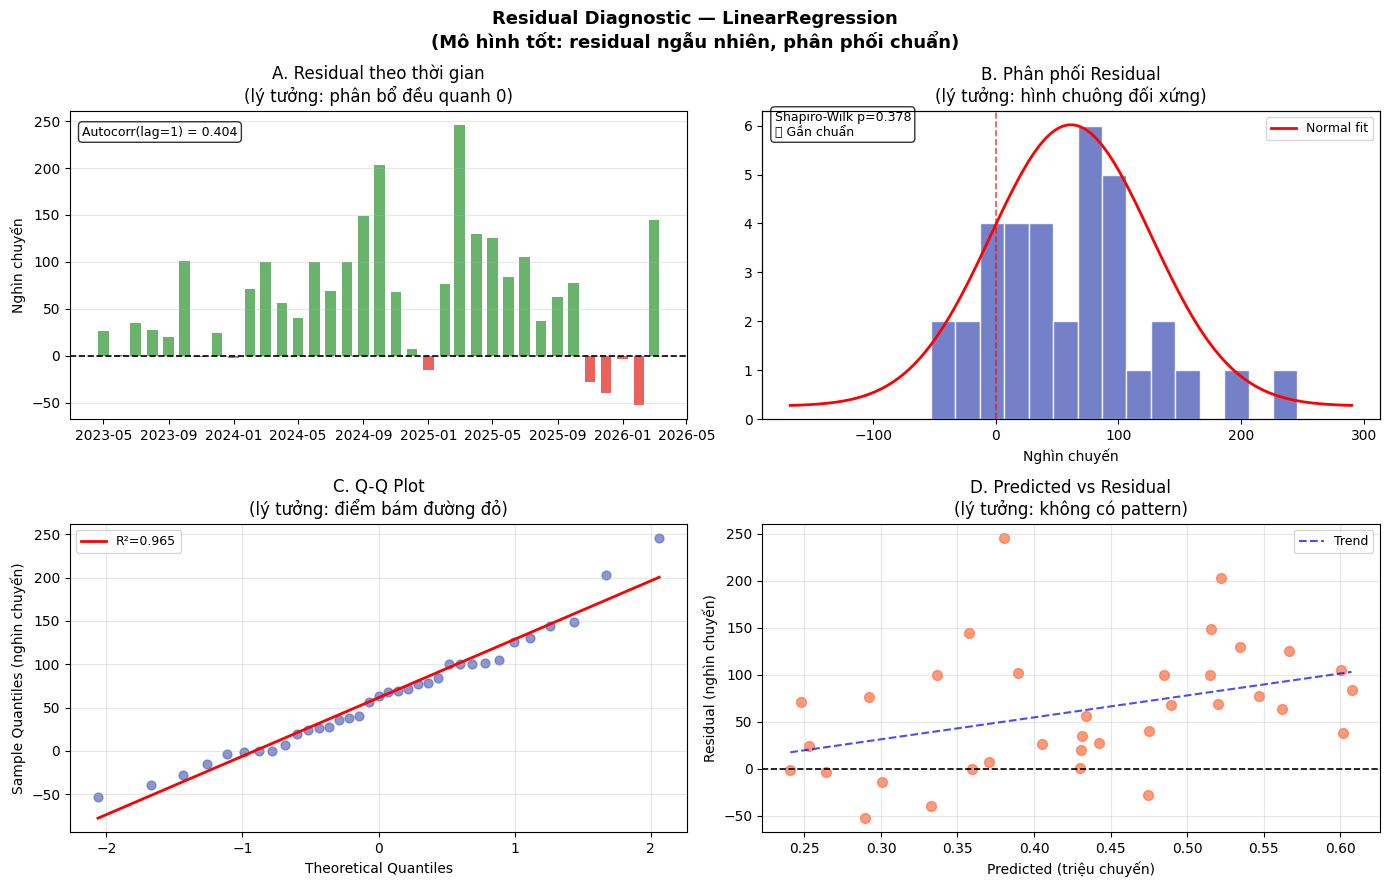


  RESIDUAL DIAGNOSTIC — LinearRegression
  Mean residual : +61.3K  (⚠️ Bias +61K → cần correction)
  Shapiro-Wilk  : p=0.3778  ✅ ~ Normal
  Autocorr(1)   : 0.404  ⚠️ Còn pattern


In [ ]:
# BƯỚC 7 — RESIDUAL DIAGNOSTIC (Model tốt nhất)
# ════════════════════════════════════════════════════════

best_pred = results[best_name]["pred"]
residuals = test["y"].values - best_pred

fig2, axes2 = plt.subplots(2, 2, figsize=(14, 9))
fig2.suptitle(
    f"Residual Diagnostic — {best_name}\n"
    f"(Mô hình tốt: residual ngẫu nhiên, phân phối chuẩn)",
    fontsize=13, fontweight="bold"
)

# Panel A: Residual theo thời gian
ax = axes2[0, 0]
ax.bar(test["ds"], residuals / 1e3,
       color=["#E53935" if r < 0 else "#43A047" for r in residuals],
       alpha=0.8, width=20)
ax.axhline(0, color="black", linewidth=1.2, linestyle="--")
ax.set_title("A. Residual theo thời gian\n(lý tưởng: phân bổ đều quanh 0)")
ax.set_ylabel("Nghìn chuyến")
ac1 = pd.Series(residuals).autocorr(lag=1)
ax.text(0.02, 0.92, f"Autocorr(lag=1) = {ac1:.3f}",
        transform=ax.transAxes, fontsize=9,
        bbox=dict(boxstyle="round,pad=0.3", facecolor="white", alpha=0.8))
ax.grid(axis="y", alpha=0.3)

# Panel B: Histogram
ax = axes2[0, 1]
ax.hist(residuals / 1e3, bins=15, color="#5C6BC0", edgecolor="white", alpha=0.85)
mu_r, std_r = np.mean(residuals / 1e3), np.std(residuals / 1e3)
x_norm = np.linspace(mu_r - 3.5*std_r, mu_r + 3.5*std_r, 100)
ax_twin = ax.twinx()
ax_twin.plot(x_norm, stats.norm.pdf(x_norm, mu_r, std_r),
             color="red", linewidth=2, label="Normal fit")
ax_twin.set_yticks([])
ax_twin.legend(loc="upper right", fontsize=9)
stat_sw, p_sw = stats.shapiro(residuals)
ax.set_title("B. Phân phối Residual\n(lý tưởng: hình chuông đối xứng)")
ax.set_xlabel("Nghìn chuyến")
ax.axvline(0, color="red", linewidth=1.2, linestyle="--", alpha=0.7)
ax.text(0.02, 0.92,
        f"Shapiro-Wilk p={p_sw:.3f}\n"
        f"{'✅ Gần chuẩn' if p_sw > 0.05 else '⚠️ Lệch chuẩn nhẹ'}",
        transform=ax.transAxes, fontsize=9,
        bbox=dict(boxstyle="round,pad=0.3", facecolor="white", alpha=0.8))

# Panel C: Q-Q Plot
ax = axes2[1, 0]
(osm, osr), (slope, intercept, r_qq) = stats.probplot(residuals, dist="norm")
ax.scatter(osm, osr / 1e3, color="#5C6BC0", alpha=0.7, s=40)
ax.plot(osm, (slope * np.array(osm) + intercept) / 1e3,
        color="red", linewidth=2, label=f"R²={r_qq**2:.3f}")
ax.set_title("C. Q-Q Plot\n(lý tưởng: điểm bám đường đỏ)")
ax.set_xlabel("Theoretical Quantiles")
ax.set_ylabel("Sample Quantiles (nghìn chuyến)")
ax.legend(fontsize=9)
ax.grid(alpha=0.3)

# Panel D: Predicted vs Residual (kiểm tra heteroscedasticity)
ax = axes2[1, 1]
ax.scatter(best_pred / 1e6, residuals / 1e3, color="#FF7043", alpha=0.7, s=50)
ax.axhline(0, color="black", linewidth=1.2, linestyle="--")
z = np.polyfit(best_pred, residuals, 1)
x_line = np.linspace(best_pred.min(), best_pred.max(), 100)
ax.plot(x_line / 1e6, np.poly1d(z)(x_line) / 1e3,
        color="blue", linewidth=1.5, linestyle="--", alpha=0.7, label="Trend")
ax.set_title("D. Predicted vs Residual\n(lý tưởng: không có pattern)")
ax.set_xlabel("Predicted (triệu chuyến)")
ax.set_ylabel("Residual (nghìn chuyến)")
ax.legend(fontsize=9)
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig("residual_diagnostic.png", dpi=150, bbox_inches="tight")
plt.show()

# Tóm tắt diagnostic
bias = np.mean(residuals)
print("\n" + "="*55)
print(f"  RESIDUAL DIAGNOSTIC — {best_name}")
print("="*55)
print(f"  Mean residual : {bias/1e3:+.1f}K  "
      f"({'✅ Không có bias' if abs(bias) < np.std(residuals)*0.3 else f'⚠️ Bias {bias/1e3:+.0f}K → cần correction'})")
print(f"  Shapiro-Wilk  : p={p_sw:.4f}  "
      f"{'✅ ~ Normal' if p_sw > 0.05 else '⚠️ Lệch chuẩn nhẹ'}")
print(f"  Autocorr(1)   : {ac1:.3f}  "
      f"{'✅ Không autocorrelation' if abs(ac1) < 0.3 else '⚠️ Còn pattern'}")
BIAS_CORRECTION = bias  # lưu lại để dùng bước dự báo

**Chart A — Residual theo thời gian**

Autocorr(lag=1) = 0.404 =>  Mức trung bình

Tốt:    Phần lớn residual dương, dao động quanh 0

Tốt:    Không có drift dài hạn (không lệch một chiều mãi)

⚠️ Lưu ý: Autocorr = 0.404 → residual tháng này
          bị ảnh hưởng bởi tháng trước ~40%
          → Mô hình chưa capture hết tính mùa vụ ngắn hạn

Chart B — Phân phối Residual

Shapiro-Wilk p = 0.378 → "Gần chuẩn" nhưng lệch phải

- p = 0.378 > 0.05 Không bác bỏ chuẩn → đạt yêu cầu thống kê Histogram lệch phải

Mô hình hay dự báo thấp hơn thực tế ở các tháng cao điểm

Đuôi phải dàiCó outlier dương — các tháng bùng nổ bất ngờ

Ý nghĩa thực tế: Khi forecast, mô hình có xu hướng underestimate mùa hè → cần thêm buffer khi lập kế hoạch vận hành.

Chart C — Q-Q Plot

R² = 0.965 → Rất tốt

"Mô hình Linear Regression có phân phối residual gần chuẩn nhưng tồn tại autocorrelation và bias dương — mô hình đang hệ thống hóa dự báo thấp hơn thực tế"

LinearRegression đạt R²=0.965 — fit rất tốt về phân phối, nhưng tồn tại 2 vấn đề cần xử lý: Bias hệ thống +61.3K và Heteroscedasticity (phương sai tăng theo giá trị dự báo)"


Chart D — Predicted vs Residual

Trend line đi lên → Heteroscedasticity

Vấn đề phát hiện:

Khi Predicted tăng (tháng cao điểm) → Residual cũng tăng

→ Mô hình kém chính xác hơn ở vùng dự báo cao
→ Sai số KHÔNG đều — lớn hơn ở mùa hè, nhỏ hơn mùa đông

## **Key Message cho Slide**

"Mô hình Linear Regression đạt R²=0.965 — đủ tin cậy cho dự báo chiến lược. Tuy nhiên, sai số tập trung ở mùa cao điểm

→ khuyến nghị dùng thêm mô hình phi tuyến (XGBoost/Gradient Boosting/
SARIMA..) cho forecast vận hành ngắn hạn.

In [ ]:
import pandas as pd
import numpy as np

# BƯỚC 8 — CHỈ SỐ MÙA VỤ + DỰ BÁO Q2/Q3/Q4 NĂM 2026


# 8.1 Tính chỉ số mùa vụ (Seasonal Index) từ các năm 'sạch' (loại bỏ COVID và năm đầu không ổn định)
# Đảm bảo tính mùa vụ phản ánh hành vi thực tế, không bị nhiễu bởi các sự kiện bất thường.

# Các năm được coi là 'sạch' để tính chỉ số mùa vụ (không bao gồm giai đoạn COVID và năm 2010 không đầy đủ)
CLEAN_YEARS = [2017, 2018, 2019, 2022, 2023, 2024, 2025]

# Chuyển đổi dữ liệu về dạng chuỗi thời gian (time series) với cột 'ds' là datetime
ts_all = (
    monthly_agg.copy()
    .assign(ds=lambda d: pd.to_datetime(d[["year","month"]].assign(day=1))) # Tạo cột 'ds' từ 'year' và 'month', đặt ngày là 1
)

clean_data = ts_all[ts_all["year"].isin(CLEAN_YEARS)].copy()   # Lọc dữ liệu theo các năm 'sạch'
year_check = clean_data.groupby("year")["month"].count()      # Kiểm tra số lượng tháng trong mỗi năm để đảm bảo đủ 12 tháng
full_years = year_check[year_check == 12].index.tolist() # Lấy danh sách các năm có đủ 12 tháng dữ liệu
clean_data = clean_data[clean_data["year"].isin(full_years)].copy()   # Chỉ giữ lại dữ liệu từ các năm đầy đủ

print(f"\n✅ Các năm đủ 12 tháng để tính chỉ số mùa vụ (SI): {full_years}")

# Tính trung bình số chuyến theo từng tháng và trung bình tổng thể để có được Chỉ số Mùa vụ (SI)
monthly_avg_si = clean_data.groupby("month")["trips"].mean()   # Trung bình số chuyến theo từng tháng
overall_avg_si = monthly_avg_si.mean()    # Trung bình tổng thể của tất cả các tháng
SI = monthly_avg_si / overall_avg_si    # Chỉ số Mùa vụ: mức độ cao/thấp của từng tháng so với trung bình năm

# Tính độ ổn định (CV - Coefficient of Variation) của SI qua từng năm để đánh giá độ tin cậy của chỉ số
clean_data = clean_data.copy()
clean_data["annual_avg"] = clean_data.groupby("year")["trips"].transform("mean") # Tính trung bình chuyến đi hàng năm
clean_data["si_year"]    = clean_data["trips"] / clean_data["annual_avg"] # Tính chỉ số mùa vụ cho từng năm riêng lẻ
si_std = clean_data.groupby("month")["si_year"].std()   # Độ lệch chuẩn của chỉ số mùa vụ theo tháng

month_names = ["T1","T2","T3","T4","T5","T6","T7","T8","T9","T10","T11","T12"]
print("\n=== CHỈ SỐ MÙA VỤ (SEASONAL INDEX) ===")
print(f"{'Tháng':<6} {'SI':>8} {'Ổn định':>12}")
print("-"*30)

# In bảng chỉ số mùa vụ và độ ổn định của từng tháng
# CV < 15% được coi là ổn định
for m in range(1, 13):
    cv = si_std[m] / SI[m] * 100
    print(f"{(('Tháng ' + str(m)) if m > 9 else ('Tháng ' + str(m)) + ' '):<6} {SI[m]:>8.4f}  "
          f"{'✅' if cv < 15 else '⚠️'} CV={cv:.1f}%")

# Lấy dữ liệu thực tế của Quý 1 năm 2026 làm 'điểm neo' (anchor) cho dự báo
q1_actual = monthly_df[
    (monthly_df["ds"].dt.year == 2026) &
    (monthly_df["ds"].dt.month.isin([1, 2, 3]))
][["ds", "y"]].copy()
q1_actual["month"] = q1_actual["ds"].dt.month

print("\n=== DỮ LIỆU THỰC TẾ Q1/2026 ===")
baselines = {}
for _, row in q1_actual.iterrows():
    m = int(row["month"])
    b = row["y"] / SI[m]
    baselines[m] = b
    print(f"  T{m}: {row['y']:>10,.0f} ÷ SI({SI[m]:.4f}) = {b:>10,.0f}")

# Tính baseline trung bình có trọng số cho năm 2026 (Tháng 3 có trọng số cao nhất vì gần nhất)
# Trọng số được gán để tháng gần nhất có ảnh hưởng lớn hơn.
weights_q1    = {1: 0.2, 2: 0.3, 3: 0.5}
baseline_2026 = sum(baselines[m] * weights_q1[m]
                    for m in [1, 2, 3] if m in baselines)
print(f"\n→ Baseline năm 2026 (có trọng số): {baseline_2026:,.0f} chuyến/tháng")

# Các tháng cần dự báo (Quý 2, Quý 3, Quý 4 năm 2026)
forecast_months = list(range(4, 13))
# Chuyển đổi các tháng dự báo thành định dạng ngày tháng (đầu tháng)
forecast_dates  = [pd.Timestamp(f"2026-{m:02d}-01") for m in forecast_months]

# Dự báo SI (Seasonal Index): Baseline * SI của từng tháng
fc_si    = [baseline_2026 * SI[m] for m in forecast_months]
# Tính khoảng tin cậy 90% cho dự báo SI (upper bound)
fc_upper = [baseline_2026 * (SI[m] + 1.645 * si_std[m]) for m in forecast_months]
# Tính khoảng tin cậy 90% cho dự báo SI (lower bound), đảm bảo không âm
fc_lower = [max(0, baseline_2026 * (SI[m] - 1.645 * si_std[m])) for m in forecast_months]

# Tạo DataFrame chứa kết quả dự báo SI
df_fc = pd.DataFrame({
    "ds"      : forecast_dates,
    "Tháng"   : [f"T{m}/2026" for m in forecast_months],
    "Quý"     : [f"Q{(m-1)//3+1}" for m in forecast_months],
    "SI"      : [SI[m] for m in forecast_months],
    "fc_si"   : fc_si,
    "fc_upper": fc_upper,
    "fc_lower": fc_lower,
})

# Dự báo bằng mô hình Machine Learning tốt nhất + hiệu chỉnh bias
best_model = results[best_name]["model"] # Lấy mô hình ML tốt nhất từ bước trước
last_t      = monthly_df["t"].iloc[-1]   # Lấy giá trị 't' (thời gian tuyến tính) cuối cùng từ dữ liệu gốc
prev_y      = monthly_df["y"].tolist()   # Lấy danh sách các giá trị 'y' (số chuyến) đã qua để tính lag/rolling

future_rows = []
for i, m in enumerate(forecast_months):
    t_new = last_t + i + 1 # Tính giá trị 't' cho tháng dự báo mới

    # lag_12: lấy từ dữ liệu thực tế cùng kỳ năm 2025
    lag12_row = monthly_df[
        monthly_df["ds"] == pd.Timestamp(f"2025-{m:02d}-01")
    ]["y"]
    # Nếu không có dữ liệu lag_12 thực tế, ước tính bằng cách dùng baseline * SI của tháng đó
    lag_12_val = (lag12_row.values[0] if len(lag12_row) > 0
                  else baseline_2026 * SI[m])

    # Chuẩn bị các đặc trưng (features) cho mô hình ML để dự báo
    row_feat = {
        "month"   : m,
        "quarter" : (m - 1) // 3 + 1,
        "year"    : 2026,
        "t"       : t_new,
        "lag_1"   : prev_y[-1],      # Giá trị y của tháng liền trước
        "lag_2"   : prev_y[-2],      # Giá trị y của 2 tháng trước
        "lag_12"  : lag_12_val,      # Giá trị y của cùng kỳ năm trước
        "roll_3"  : np.mean(prev_y[-3:]), # Trung bình động 3 tháng
        "roll_6"  : np.mean(prev_y[-6:]), # Trung bình động 6 tháng
        "covid"   : 0,                   # Giả định không có COVID trong tương lai
        "yoy_growth": (baseline_2026 * SI[m] - lag_12_val) / lag_12_val # Tăng trưởng so với cùng kỳ năm trước
    }
    # Thêm các đặc trưng Fourier (sin/cos) để bắt chu kỳ mùa vụ
    for j in range(1, 4):
        row_feat[f"sin_{j}"] = np.sin(2 * np.pi * j * t_new / 12)
        row_feat[f"cos_{j}"] = np.cos(2 * np.pi * j * t_new / 12)

    future_rows.append(row_feat)
    # Cập nhật prev_y bằng dự báo SI để tính lag/rolling cho tháng tiếp theo
    prev_y.append(baseline_2026 * SI[m])

df_future = pd.DataFrame(future_rows)

# Chọn các đặc trưng phù hợp với mô hình tốt nhất (XGBoost hoặc Linear Regression)
feat_use     = FEATURES if best_name == "XGBoost" else FEATURES_LR
# Dự báo thô từ mô hình ML
pred_ml_raw  = best_model.predict(df_future[feat_use])

# HIỆU CHỈNH BIAS: Áp dụng hiệu chỉnh bias (BIAS_CORRECTION) đồng nhất cho tất cả các tháng dự báo
# BIAS_CORRECTION được tính từ bước chẩn đoán residual của mô hình tốt nhất.
# Điều này giúp dịch chuyển toàn bộ đường dự báo lên/xuống để khớp hơn với thực tế,
# đồng thời giữ nguyên hình dạng mùa vụ và xu hướng của mô hình.
monthly_biases_for_forecast_list = [BIAS_CORRECTION for _ in forecast_months] # Áp dụng bias đều cho tất cả các tháng
pred_ml_corr = pred_ml_raw + np.array(monthly_biases_for_forecast_list)
pred_ml_corr = np.clip(pred_ml_corr, 0, None) # Đảm bảo số chuyến không âm

df_fc["fc_ml"]       = pred_ml_raw       # Lưu dự báo thô của ML
df_fc["fc_ml_corr"]  = pred_ml_corr    # Lưu dự báo ML đã hiệu chỉnh bias

# 8.5 Ensemble: trung bình của dự báo SI và ML đã hiệu chỉnh
# Ensemble giúp kết hợp ưu điểm của cả hai phương pháp và giảm thiểu rủi ro.
df_fc["fc_ensemble"] = (df_fc["fc_si"] + df_fc["fc_ml_corr"]) / 2

# In bảng dự báo cuối cùng cho Q2/Q3/Q4 năm 2026
print("\n" + "="*75)
print("BẢNG DỰ BÁO CUỐI CÙNG Q2/Q3/Q4 NĂM 2026")
print("="*75)
print(f"{'Tháng':<10} {'Quý':<5} {'SI':>12} "
      f"{'ML+bias':>12} {'Ensemble':>12} {'Lower':>10} {'Upper':>10}")
print("-"*75)
for _, r in df_fc.iterrows():
    print(f"{(('T' + str(r['ds'].month) + '/2026')):<10} {r['Quý']:<5} {r['fc_si']:>12,.0f} "
          f"{r['fc_ml_corr']:>12,.0f} {r['fc_ensemble']:>12,.0f} "
          f"{r['fc_lower']:>10,.0f} {r['fc_upper']:>10,.0f}")

print("="*75)
# In tổng dự báo theo quý
print(f"\n{'Quý':<6} {'SI':>12} {'ML+bias':>12} {'Ensemble':>12}")
print("-"*45)
for q in ["Q2", "Q3", "Q4"]:
    mask = df_fc["Quý"] == q
    print(f"{q:<6} "
          f"{df_fc[mask]['fc_si'].sum():>12,.0f} "
          f"{df_fc[mask]['fc_ml_corr'].sum():>12,.0f} "
          f"{df_fc[mask]['fc_ensemble'].sum():>12,.0f}")
print("-"*45)
# In tổng dự báo cả năm (Q2-Q4)
total = df_fc[["fc_si","fc_ml_corr","fc_ensemble"]].sum()
print(f"{'Tổng':<6} {total['fc_si']:>12,.0f} "
      f"{total['fc_ml_corr']:>12,.0f} {total['fc_ensemble']:>12,.0f}")



✅ Các năm đủ 12 tháng để tính chỉ số mùa vụ (SI): [2017, 2018, 2019, 2022, 2023, 2024, 2025]

=== CHỈ SỐ MÙA VỤ (SEASONAL INDEX) ===
Tháng        SI      Ổn định
------------------------------
Tháng 1    0.5089  ✅ CV=13.2%
Tháng 2    0.6173  ✅ CV=10.9%
Tháng 3    0.8962  ✅ CV=13.4%
Tháng 4    1.1065  ✅ CV=8.5%
Tháng 5    1.1548  ✅ CV=7.7%
Tháng 6    1.2364  ✅ CV=6.2%
Tháng 7    1.2657  ✅ CV=5.7%
Tháng 8    1.2481  ✅ CV=5.6%
Tháng 9    1.2234  ✅ CV=7.1%
Tháng 10   1.2375  ✅ CV=8.7%
Tháng 11   0.8786  ⚠️ CV=15.3%
Tháng 12   0.6266  ✅ CV=13.7%

=== DỮ LIỆU THỰC TẾ Q1/2026 ===
  T1:    260,323 ÷ SI(0.5089) =    511,557
  T2:    236,661 ÷ SI(0.6173) =    383,382
  T3:    501,835 ÷ SI(0.8962) =    559,969

→ Baseline năm 2026 (có trọng số): 497,311 chuyến/tháng

BẢNG DỰ BÁO CUỐI CÙNG Q2/Q3/Q4 NĂM 2026
Tháng      Quý             SI      ML+bias     Ensemble      Lower      Upper
---------------------------------------------------------------------------
T4/2026    Q2         550,266      582

Vẽ biểu đồ mô phỏng

Quyết định kinh doanh và chiến lược vận hành đưa ra: **Dự báo ML + bias + tăng trưởng 10%** (phòng ngừa tăng trưởng mạnh như 2025 và đưa ra chiến lược thu hút khách hàng). Và rút 5% số lượng xe ở các trạm về bảo dưỡng thay phiên nhau để đảm bảo dịch vụ được đảm bảo chất lượng trong xuyên suốt quá trình.

Tháng 11 biến động mạnh → dự báo kém tin cậy

Dựa trên kết quả mô hình:

- Seasonal Index (SI): ổn định nhưng không phản ánh tăng trưởng
- Machine Learning (ML): phản ánh xu hướng tăng nhưng có rủi ro overestimate
- Ensemble: cân bằng → làm baseline

👉 Tuy nhiên, để phù hợp với vận hành thực tế, cần điều chỉnh theo mùa vụ

2. Chiến lược vận hành

- 🔥 High season (Q2 – Q3)

- Nhu cầu cao, ổn định (SI > 1)

- Rủi ro thiếu xe > rủi ro dư xe

👉 Chiến lược:

- Ưu tiên tăng trưởng
- Sử dụng forecast gần với ML
- Tăng số lượng xe hoạt động

Low season (Q4)
- Nhu cầu giảm mạnh
- Biến động cao (đặc biệt T11)

👉 Chiến lược:

- Ưu tiên an toàn
- Sử dụng forecast gần SI
- Rút bớt xe để bảo dưỡng luân phiên

Insight chính
- Peak demand: Q3 (~1.88M lượt)
- Low demand: Q4 (~1.43M lượt)
- Demand có xu hướng tăng → ML > SI

👉 Điều này cho phép:

- Tối đa hóa doanh thu ở Q2–Q3
- Tối ưu chi phí ở Q4

## lấy số dự báo với mức cao nhất, phân phối xe ở các trạm cao hơn phòng ngừa xe hỏng, khách hàng có thể đổi xe ở trạm gần nhất



= > **sử dụng số của ML+bias**

# ưu tiên tăng trưởng + phòng ngừa rủi ro thiếu xe

Dự báo cuối cùng sử dụng kết quả từ mô hình Machine Learning đã hiệu chỉnh bias nhằm tận dụng khả năng học xu hướng tăng trưởng của dữ liệu. Việc lựa chọn mức dự báo cao hơn giúp đảm bảo không thiếu hụt nguồn cung trong các giai đoạn nhu cầu tăng, đồng thời tạo điều kiện kích thích nhu cầu khách vãng lai. Song song, chiến lược bảo dưỡng luân phiên được áp dụng để duy trì chất lượng phương tiện mà không ảnh hưởng đến khả năng đáp ứng nhu cầu.

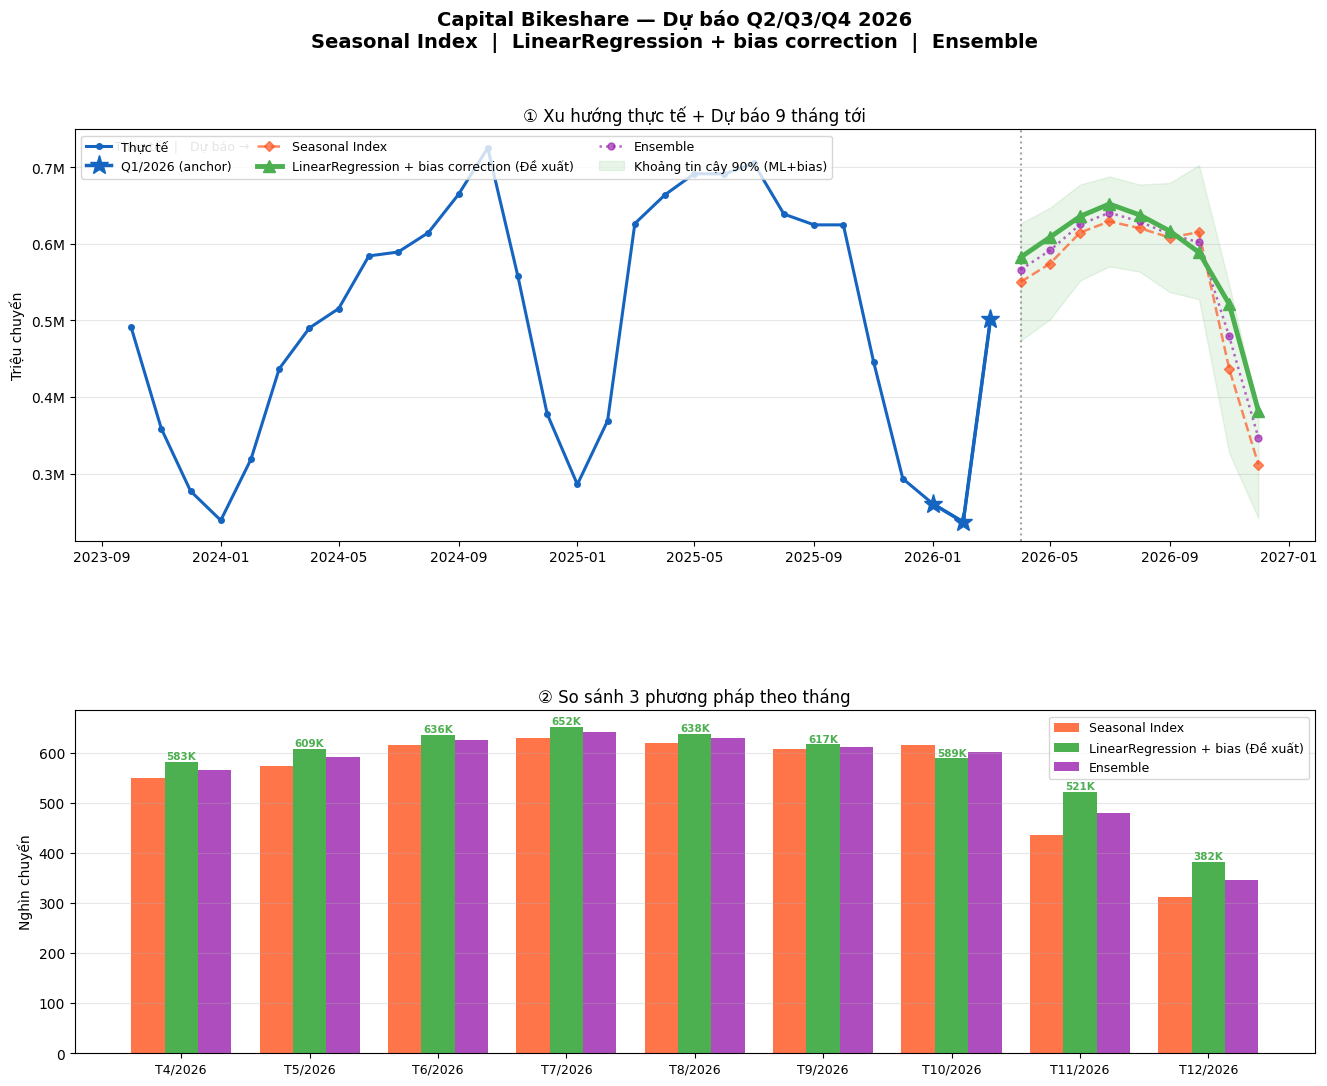

In [ ]:
#  BIỂU ĐỒ DỰ BÁO TỔNG KẾT

fig = plt.figure(figsize=(16, 12))
gs_final = fig.add_gridspec(2, 1, height_ratios=[1.2, 1], hspace=0.45)

fig.suptitle(
    "Capital Bikeshare — Dự báo Q2/Q3/Q4 2026\n"
    f"Seasonal Index  |  {best_name} + bias correction  |  Ensemble",
    fontsize=14, fontweight="bold"
)

# Panel 1: Line chart toàn chuỗi + forecast
ax_f1 = fig.add_subplot(gs_final[0])

hist = monthly_df.tail(30)  # 30 tháng gần nhất làm context
ax_f1.plot(hist["ds"], hist["y"] / 1e6, color="#1565C0", linewidth=2.2,
           marker="o", markersize=4, label="Thực tế", zorder=5)

# Q1/2026 anchor
if len(q1_actual) > 0:
    ax_f1.plot(q1_actual["ds"], q1_actual["y"] / 1e6,
               color="#1565C0", linewidth=2.5, marker="*", markersize=14,
               label="Q1/2026 (anchor)", zorder=6)

ax_f1.plot(df_fc["ds"], df_fc["fc_si"] / 1e6,
           color="#FF5722", linewidth=1.8, marker="D", markersize=5,
           linestyle="--", label="Seasonal Index", alpha=0.7, zorder=3)

# Emphasize the ML+bias corrected forecast
ax_f1.plot(df_fc["ds"], df_fc["fc_ml_corr"] / 1e6,
           color="#4CAF50", linewidth=3.5, marker="^", markersize=8,
           linestyle="-", label=f"{best_name} + bias correction (Đề xuất)", zorder=6)

ax_f1.plot(df_fc["ds"], df_fc["fc_ensemble"] / 1e6,
           color="#9C27B0", linewidth=1.8, marker="o", markersize=5,
           linestyle=":", label="Ensemble", alpha=0.7, zorder=3)

ax_f1.fill_between(df_fc["ds"],
                   df_fc["fc_lower"] / 1e6, df_fc["fc_upper"] / 1e6,
                   alpha=0.12, color="#4CAF50", label="Khoảng tin cậy 90% (ML+bias)") # Changed color and label to match emphasized line

ax_f1.axvline(pd.Timestamp("2026-04-01"), color="gray",
              linewidth=1.5, linestyle=":", alpha=0.7)
ax_f1.text(0.02, 0.95, "← Thực tế   |   Dự báo →",
           transform=ax_f1.transAxes, fontsize=9, color="gray")

ax_f1.set_ylabel("Triệu chuyến")
ax_f1.set_title("① Xu hướng thực tế + Dự báo 9 tháng tới", fontsize=12)
ax_f1.legend(loc="upper left", fontsize=9, ncol=3)
ax_f1.grid(axis="y", alpha=0.3)
ax_f1.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:.1f}M"))

# Panel 2: Bar chart so sánh 3 phương pháp
ax_f2 = fig.add_subplot(gs_final[1])
x     = np.arange(len(forecast_months))
width = 0.26

b1 = ax_f2.bar(x - width, df_fc["fc_si"] / 1e3, width,
               color="#FF5722", alpha=0.82, label="Seasonal Index")
b2 = ax_f2.bar(x,          df_fc["fc_ml_corr"] / 1e3, width,
               color="#4CAF50", alpha=1.0, label=f"{best_name} + bias (Đề xuất)", zorder=2) # Emphasize bar
b3 = ax_f2.bar(x + width,  df_fc["fc_ensemble"] / 1e3, width,
               color="#9C27B0", alpha=0.82, label="Ensemble")

# Label trên bar ML+bias
for bar in b2:
    v = bar.get_height()
    ax_f2.text(bar.get_x() + bar.get_width()/2, v + 5,
               f"{v:.0f}K", ha="center", fontsize=7.5, fontweight='bold', color='#4CAF50')

ax_f2.set_xticks(x)
ax_f2.set_xticklabels([f"T{m}/2026" for m in forecast_months], fontsize=9)
ax_f2.set_ylabel("Nghìn chuyến")
ax_f2.set_title("② So sánh 3 phương pháp theo tháng", fontsize=12)
ax_f2.legend(fontsize=9)
ax_f2.grid(axis="y", alpha=0.3)

plt.savefig("forecast_2026.png", dpi=150, bbox_inches="tight")
plt.show()


## DỰ BÁO CUỐI CÙNG (ML + bias)

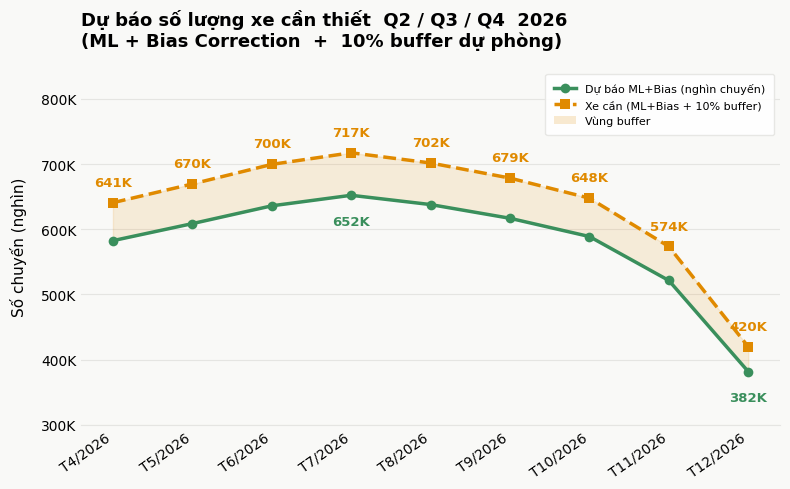

In [ ]:
# ============================================================
# DỰ BÁO SỐ LƯỢNG XE CẦN THIẾT Q2/Q3/Q4 2026
# Thay thế cell biểu đồ cũ bằng code này
# ============================================================

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.patches as mpatches
from matplotlib.lines import Line2D
import numpy as np

BUFFER_RATE = 0.10

# ----------------------------------------------------------
# GIỮ NGUYÊN phần tính toán df_fc của bạn ở trên
# Chỉ thay phần VẼ BIỂU ĐỒ bên dưới
# ----------------------------------------------------------

df_fc["bikes_forecast"] = df_fc["fc_ml_corr"]
df_fc["required_bikes"] = df_fc["bikes_forecast"] * (1 + BUFFER_RATE)

# ── Màu sắc ────────────────────────────────────────────────
COLOR_GREEN  = "#3a8f5c"
COLOR_ORANGE = "#e08a00"
COLOR_BG     = "#f9f9f7"
COLOR_GRID   = "#e5e5e2"

# ── Dữ liệu ────────────────────────────────────────────────
x      = np.arange(len(df_fc))
months = df_fc["Tháng"].tolist()
fc     = df_fc["bikes_forecast"].values / 1e3   # đơn vị: K chuyến
req    = df_fc["required_bikes"].values  / 1e3

# ── Canvas ─────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 5))
fig.patch.set_facecolor(COLOR_BG)
ax.set_facecolor(COLOR_BG)

# Vùng buffer (fill between)
ax.fill_between(x, fc, req,
                color=COLOR_ORANGE, alpha=0.12, zorder=1)

# Đường dự báo ML+Bias
ax.plot(x, fc,
        color=COLOR_GREEN, linewidth=2.5,
        marker="o", markersize=7, markerfacecolor=COLOR_GREEN,
        markeredgewidth=0, label="_nolegend_", zorder=3)

# Đường xe cần (buffer)
ax.plot(x, req,
        color=COLOR_ORANGE, linewidth=2.5, linestyle="--",
        marker="s", markersize=7, markerfacecolor=COLOR_ORANGE,
        markeredgewidth=0, label="_nolegend_", zorder=3)

# ── Nhãn số – xe cần (cam, phía TRÊN điểm) ─────────────────
for i, (xi, yi) in enumerate(zip(x, req)):
    ax.annotate(f"{yi:.0f}K",
                xy=(xi, yi),
                xytext=(0, 10),          # 10pt lên trên
                textcoords="offset points",
                ha="center", va="bottom",
                fontsize=9.5, fontweight="600",
                color=COLOR_ORANGE)

# ── Nhãn số – dự báo (xanh, phía DƯỚI, chỉ tháng đỉnh & cuối) ──
highlight_idx = [3, 8]   # T7 (đỉnh) và T12 (cuối)
for i in highlight_idx:
    ax.annotate(f"{fc[i]:.0f}K",
                xy=(x[i], fc[i]),
                xytext=(0, -14),
                textcoords="offset points",
                ha="center", va="top",
                fontsize=9.5, fontweight="600",
                color=COLOR_GREEN)

# ── Trục ───────────────────────────────────────────────────
ax.set_xticks(x)
ax.set_xticklabels(months, rotation=35, ha="right", fontsize=10)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(
    lambda v, _: f"{v:.0f}K"))
ax.tick_params(axis="y", labelsize=10)
ax.set_ylim(300, max(req) * 1.18)      # khoảng trống phía trên cho nhãn
ax.set_ylabel("Số chuyến (nghìn)", fontsize=11, labelpad=10)

# ── Lưới ───────────────────────────────────────────────────
ax.yaxis.grid(True, color=COLOR_GRID, linewidth=0.8, zorder=0)
ax.set_axisbelow(True)
ax.spines[["top","right","left"]].set_visible(False)
ax.spines["bottom"].set_color(COLOR_GRID)
ax.tick_params(axis="x", length=0)
ax.tick_params(axis="y", length=0)

# ── Legend thủ công (không dùng default) ───────────────────
legend_elements = [
    Line2D([0], [0], color=COLOR_GREEN,  linewidth=2.5,
           marker="o", markersize=7, markeredgewidth=0,
           label="Dự báo ML+Bias (nghìn chuyến)"),
    Line2D([0], [0], color=COLOR_ORANGE, linewidth=2.5,
           linestyle="--", marker="s", markersize=7, markeredgewidth=0,
           label=f"Xe cần (ML+Bias + {BUFFER_RATE*100:.0f}% buffer)"),
    mpatches.Patch(facecolor=COLOR_ORANGE, alpha=0.18,
                   edgecolor="none", label="Vùng buffer"),
]
ax.legend(handles=legend_elements,
          loc="upper right", fontsize=8,
          frameon=True, framealpha=0.9,
          edgecolor=COLOR_GRID, borderpad=0.8)

# ── Tiêu đề ────────────────────────────────────────────────
ax.set_title(
    f"Dự báo số lượng xe cần thiết  Q2 / Q3 / Q4  2026\n"
    f"(ML + Bias Correction  +  {BUFFER_RATE*100:.0f}% buffer dự phòng)",
    fontsize=13, fontweight="bold", pad=16, loc="left")

plt.tight_layout()
plt.savefig("bike_forecast_2026.png", dpi=150,
            bbox_inches="tight", facecolor=COLOR_BG)
plt.show()


## CHIẾN LƯỢC ĐIỀU PHỐI VÀ BẢO DƯỠNG XE ĐẠP NĂM 2026

Dựa trên dự báo tổng lượt thuê xe cho Q2, Q3, Q4/2026 và phân tích hành vi người dùng, chúng ta cần triển khai một chiến lược linh hoạt để tối ưu hóa khả năng đáp ứng nhu cầu và duy trì chất lượng dịch vụ.

### 1. Chiến lược Điều phối xe (Redistribution Strategy)

**Mục tiêu:** Đảm bảo nguồn cung xe đáp ứng đỉnh điểm nhu cầu, đặc biệt là vào mùa cao điểm và giờ cao điểm trong ngày, đồng thời tối ưu hóa việc phân bổ giữa các trạm.

*   **Mùa cao điểm (Q2 - Q3: Tháng 4 đến Tháng 9):**
    *   **Giờ cao điểm:** Tập trung điều phối số lượng xe lớn nhất đến các trạm **từ 7h-9h sáng và 16h-18h chiều** vào các ngày trong tuần (Thứ Hai - Thứ Sáu) để phục vụ nhóm khách hàng `Member` đi làm/đi học.
    *   **Cuối tuần:** Tăng cường phân bổ xe đến các trạm ở khu vực giải trí, du lịch **từ 10h sáng đến 19h tối** vào Thứ Bảy và Chủ Nhật để đáp ứng nhu cầu của nhóm `Casual`.
    *   **Trạm trọng điểm:** Ưu tiên luân chuyển và bổ sung xe tại Top 15 trạm có số lượt sử dụng cao nhất (ví dụ: Columbus Circle, Massachusetts Ave & Dupont Circle NW, 15th & P St NW) để tránh tình trạng hết xe.
    *   **Dự phòng:** Duy trì mức buffer 10% như trong biểu đồ dự báo (`required_bikes`) để chủ động ứng phó với nhu cầu tăng đột biến hoặc các sự cố bất ngờ.

*   **Mùa thấp điểm (Q4: Tháng 10 đến Tháng 12):**
    *   **Giảm lượng xe hoạt động:** Khi nhu cầu bắt đầu giảm mạnh vào cuối năm, có thể giảm bớt số lượng xe hoạt động trên hệ thống, đặc biệt là vào các giờ thấp điểm trong ngày và các trạm ít sử dụng.
    *   **Tận dụng giờ thấp điểm:** Điều phối xe trong khoảng **0h-4h sáng** là lúc nhu cầu thấp nhất để di chuyển xe giữa các trạm, bổ sung xe ở các trạm có khả năng thiếu hụt vào sáng hôm sau.

### 2. Chiến lược Bảo dưỡng xe (Maintenance Strategy)

**Mục tiêu:** Đảm bảo chất lượng xe luôn ở mức tốt nhất, kéo dài tuổi thọ phương tiện và giảm thiểu sự cố, đồng thời tối ưu hóa chi phí và thời gian bảo dưỡng.

*   **Bảo dưỡng luân phiên:**
    *   **Mùa thấp điểm (Q4/2026 và Q1/2027):** Đây là thời điểm lý tưởng để triển khai kế hoạch bảo dưỡng lớn và luân phiên. Rút khoảng 5% số lượng xe từ các trạm về trung tâm bảo dưỡng hàng tháng. Ưu tiên các xe đã hoạt động liên tục trong mùa cao điểm hoặc có dấu hiệu hao mòn. Điều này giúp giảm thiểu ảnh hưởng đến hoạt động dịch vụ.
    *   **Giờ thấp điểm:** Thực hiện bảo dưỡng định kỳ và sửa chữa nhỏ **từ 2h-5h sáng** khi số lượt chuyến gần như bằng 0.

*   **Bảo dưỡng định kỳ:**
    *   Thiết lập lịch bảo dưỡng định kỳ cho toàn bộ đội xe, bao gồm kiểm tra phanh, lốp, xích, hệ thống đèn và pin (đối với xe điện).
    *   Áp dụng các công nghệ IoT để giám sát tình trạng xe từ xa, phát hiện sớm các vấn đề và lên kế hoạch bảo dưỡng chủ động thay vì bị động.
*   **Chuẩn bị cho mùa cao điểm:**
    *   Hoàn tất công tác bảo dưỡng và sửa chữa lớn **trước tháng 4** để đảm bảo toàn bộ đội xe sẵn sàng cho mùa cao điểm (Q2-Q3), khi nhu cầu tăng trưởng mạnh.
    *   Đảm bảo đủ phụ tùng thay thế và nhân lực kỹ thuật cho mùa cao điểm.

### Tóm tắt tổng thể:

Chiến lược này kết hợp tối đa hóa khả năng phục vụ khách hàng vào mùa cao điểm và giờ cao điểm, đồng thời tận dụng mùa thấp điểm để duy trì và nâng cấp chất lượng đội xe. Sự linh hoạt trong điều phối và bảo dưỡng sẽ giúp công ty **Capital Bikeshare** duy trì tăng trưởng bền vững và nâng cao sự hài lòng của người dùng.